In [2]:
import importlib
importlib.reload(importlib.import_module('analysis_utils_msr'))
import warnings
import pandas as pd
import numpy as np
from analysis_utils_msr import sum_individual_mutation_scores, assess_grouped_spearman, assess_grouped_gain, assess_grouped_ndcg, assess_classification_metric, add_additive_predictions, unify_similar_columns, assess_all_models
import pandas as pd
import numpy as np
from functools import partial

# notebook display options
warnings.filterwarnings('ignore')

# Get all raw predictions
dataset = 'hyperopt_splits-test'
base_path = f'~/software/esm-msr/analysis_notebooks/predictions/{dataset}'
msr_base_1 = f'{base_path}/msr_dual_ensemble_small_large/1/epoch=05-val_rho_combined_avg=0.805.ckpt'
msr_base_2 = f'{base_path}/msr_dual_ensemble_small_large/2/epoch=04-val_rho_combined_avg=0.809.ckpt'
msr_base_3 = f'{base_path}/msr_dual_ensemble_small_large/3/epoch=03-val_rho_combined_avg=0.807.ckpt'

chain_base_1 = f'{base_path}/msr_dual_ensemble_small_large_chain/1/epoch=04-val_rho_combined_avg=0.818.ckpt'
chain_base_2 = f'{base_path}/msr_dual_ensemble_small_large_chain/2/epoch=01-val_rho_combined_avg=0.816.ckpt'
chain_base_3 = f'{base_path}/msr_dual_ensemble_small_large_chain/3/epoch=02-val_rho_combined_avg=0.817.ckpt'

mm_base_1 = f'{base_path}/msr_dual_ensemble_small_large_mm/1/epoch=02-val_rho_combined_avg=0.808.ckpt'
mm_base_2 = f'{base_path}/msr_dual_ensemble_small_large_mm/2/epoch=02-val_rho_combined_avg=0.811.ckpt'
mm_base_3 = f'{base_path}/msr_dual_ensemble_small_large_mm/3/epoch=02-val_rho_combined_avg=0.807.ckpt'

single_base_1 = f'{base_path}/msr_dual_ensemble_small_large_singles/1/epoch=05-val_rho_combined_avg=0.809.ckpt'
single_base_2 = f'{base_path}/msr_dual_ensemble_small_large_singles/2/epoch=05-val_rho_combined_avg=0.810.ckpt'
single_base_3 = f'{base_path}/msr_dual_ensemble_small_large_singles/3/epoch=03-val_rho_combined_avg=0.809.ckpt'

reg_base_1 = f'{base_path}/msr_dual_ensemble_small_large_norank_mse20/1/epoch=03-val_rho_combined_avg=0.809.ckpt'
reg_base_2 = f'{base_path}/msr_dual_ensemble_small_large_norank_mse20/2/epoch=06-val_rho_combined_avg=0.812.ckpt'
reg_base_3 = f'{base_path}/msr_dual_ensemble_small_large_norank_mse20/3/epoch=06-val_rho_combined_avg=0.812.ckpt'

#hybrid_base = f'{base_path}/msr_dual_ensemble_masked_ss12/1/epoch=03-val_rho_combined_avg=0.818.ckpt'

full_alpha = '16.0'
med_alpha = '8.0'
low_alpha = '4.0'

In [3]:
# ================= THERMOMPNN =================

# 1. Load Single Model Predictions (for single mutants)
df_tm_1_single = pd.read_csv(f'{base_path}/thermompnnd/single_hyperopt_splits_correct_bb_1_epoch=99_val_ddG_spearman=0.73.ckpt_singles.csv', index_col=0)
df_tm_2_single = pd.read_csv(f'{base_path}/thermompnnd/single_hyperopt_splits_correct_bb_2_epoch=98_val_ddG_spearman=0.73.ckpt_singles.csv', index_col=0)
df_tm_3_single = pd.read_csv(f'{base_path}/thermompnnd/single_hyperopt_splits_correct_bb_3_epoch=99_val_ddG_spearman=0.73.ckpt_singles.csv', index_col=0)

# 2. Load Epistatic Model Predictions (for multimutants)
df_tm_1_epistatic = pd.read_csv(f'{base_path}/thermompnnd/epistatic_hyperopt_splits_correct_bb_1_epoch=84_val_ddG_spearman=0.74.ckpt.csv', index_col=0)
df_tm_2_epistatic = pd.read_csv(f'{base_path}/thermompnnd/epistatic_hyperopt_splits_correct_bb_2_epoch=56_val_ddG_spearman=0.73.ckpt.csv', index_col=0)
df_tm_3_epistatic = pd.read_csv(f'{base_path}/thermompnnd/epistatic_hyperopt_splits_correct_bb_3_epoch=95_val_ddG_spearman=0.73.ckpt.csv', index_col=0)

# 3. Load Additive Model Predictions (for multimutant baseline)
df_tm_1_additive = pd.read_csv(f'{base_path}/thermompnnd/additive_single_hyperopt_splits_correct_bb_1_epoch=99_val_ddG_spearman=0.73.ckpt.csv', index_col=0).dropna(subset='ddG_pred_additive')
df_tm_2_additive = pd.read_csv(f'{base_path}/thermompnnd/additive_single_hyperopt_splits_correct_bb_2_epoch=98_val_ddG_spearman=0.73.ckpt.csv', index_col=0).dropna(subset='ddG_pred_additive')
df_tm_3_additive = pd.read_csv(f'{base_path}/thermompnnd/additive_single_hyperopt_splits_correct_bb_3_epoch=99_val_ddG_spearman=0.73.ckpt.csv', index_col=0).dropna(subset='ddG_pred_additive')

# --- Construct ThermoMPNN column (Singles + Additive Multimutants) ---
df_tm_1_add_col = pd.concat([df_tm_1_single['ddG_pred'], df_tm_1_additive['ddG_pred_additive']]).to_frame('ThermoMPNN_1')
df_tm_2_add_col = pd.concat([df_tm_2_single['ddG_pred'], df_tm_2_additive['ddG_pred_additive']]).to_frame('ThermoMPNN_2')
df_tm_3_add_col = pd.concat([df_tm_3_single['ddG_pred'], df_tm_3_additive['ddG_pred_additive']]).to_frame('ThermoMPNN_3')

# --- Construct ThermoMPNN(-D) column (Epistatic Multimutants filled with Singles) ---
# FLAW: We must strictly filter the single model to only include non-colon indices 
# to prevent "additive" leaking into the "epistatic" column per prompt instructions.
df_tm_1_epi_col = df_tm_1_epistatic['ddG_pred'].rename('ThermoMPNN(-D)_1')
df_tm_1_epi_col = df_tm_1_epi_col.combine_first(df_tm_1_single.loc[~df_tm_1_single.index.str.contains(':'), 'ddG_pred'].rename('ThermoMPNN(-D)_1'))

df_tm_2_epi_col = df_tm_2_epistatic['ddG_pred'].rename('ThermoMPNN(-D)_2')
df_tm_2_epi_col = df_tm_2_epi_col.combine_first(df_tm_2_single.loc[~df_tm_2_single.index.str.contains(':'), 'ddG_pred'].rename('ThermoMPNN(-D)_2'))

df_tm_3_epi_col = df_tm_3_epistatic['ddG_pred'].rename('ThermoMPNN(-D)_3')
df_tm_3_epi_col = df_tm_3_epi_col.combine_first(df_tm_3_single.loc[~df_tm_3_single.index.str.contains(':'), 'ddG_pred'].rename('ThermoMPNN(-D)_3'))

# Assemble Thermo Ensemble
df_thermo = df_tm_1_add_col.join([df_tm_1_epi_col, df_tm_2_add_col, df_tm_2_epi_col, df_tm_3_add_col, df_tm_3_epi_col], how='inner')
# Attach ground truth from the first replicate
df_thermo = df_thermo.join(df_tm_1_single[['code', 'mut_type', 'ddG_true']].rename(columns={'ddG_true': 'ddG_ML_thermo'}))
df_thermo['ThermoMPNN(-D)_additive_1'] = df_thermo['ThermoMPNN_1']
df_thermo['ThermoMPNN(-D)_additive_2'] = df_thermo['ThermoMPNN_2']
df_thermo['ThermoMPNN(-D)_additive_3'] = df_thermo['ThermoMPNN_3']

# ================= SPURS =================

df_spurs_single_1 = pd.read_csv(f'{base_path}/SPURS/step_0-val_rho_avg_spearman_0.69_single_seed1.ckpt_single_predictions.csv', index_col=0)
df_spurs_single_1 = df_spurs_single_1.rename(columns={'ddg_pred': 'SPURS_additive_1'})
df_spurs_single_2 = pd.read_csv(f'{base_path}/SPURS/step_0-val_rho_avg_spearman_0.68_single_seed2.ckpt_single_predictions.csv', index_col=0)
df_spurs_single_2 = df_spurs_single_2.rename(columns={'ddg_pred': 'SPURS_additive_2'})
df_spurs_single_3 = pd.read_csv(f'{base_path}/SPURS/step_0-val_rho_avg_spearman_0.69_single_seed3.ckpt_single_predictions.csv', index_col=0)
df_spurs_single_3 = df_spurs_single_3.rename(columns={'ddg_pred': 'SPURS_additive_3'})

df_spurs_multi_1 = pd.read_csv(f'{base_path}/SPURS/step_0-val_rho_avg_spearman_0.77_multi_seed1.ckpt_multi_predictions.csv', index_col=0)
df_spurs_multi_1 = df_spurs_multi_1.rename(columns={'ddg_pred': 'SPURS_1'})
df_spurs_multi_2 = pd.read_csv(f'{base_path}/SPURS/step_0-val_rho_avg_spearman_0.77_multi_seed2.ckpt_multi_predictions.csv', index_col=0)
df_spurs_multi_2 = df_spurs_multi_2.rename(columns={'ddg_pred': 'SPURS_2'})
df_spurs_multi_3 = pd.read_csv(f'{base_path}/SPURS/step_0-val_rho_avg_spearman_0.75_multi_seed3.ckpt_multi_predictions.csv', index_col=0)
df_spurs_multi_3 = df_spurs_multi_3.rename(columns={'ddg_pred': 'SPURS_3'})

df_spurs_single = pd.concat([df_spurs_single_1, df_spurs_single_2[[c for c in df_spurs_single_2.columns if 'SPURS' in c]], df_spurs_single_3[[c for c in df_spurs_single_3.columns if 'SPURS' in c]]], axis=1)
df_spurs_multi = pd.concat([df_spurs_multi_1[[c for c in df_spurs_multi_1.columns if 'SPURS' in c]], df_spurs_multi_2[[c for c in df_spurs_multi_2.columns if 'SPURS' in c]], df_spurs_multi_3[[c for c in df_spurs_multi_3.columns if 'SPURS' in c]]], axis=1)
df_spurs = df_spurs_single.join(df_spurs_multi)

# ================= MUTATE EVERYTHING =================

df_me_1 = pd.read_csv(f'{base_path}/mutate_everything/af_double_hyperopt_splits_1_checkpoint-99.csv', index_col=0)
df_me_1['MutateEverything_1'] = df_me_1['ddG_pred']
df_me_1['ddG_ML_me'] = df_me_1['ddG_true']
df_me_2 = pd.read_csv(f'{base_path}/mutate_everything/af_double_hyperopt_splits_2_checkpoint-99.csv', index_col=0)
df_me_2['MutateEverything_2'] = df_me_2['ddG_pred']
df_me_3 = pd.read_csv(f'{base_path}/mutate_everything/af_double_hyperopt_splits_3_checkpoint-99.csv', index_col=0)
df_me_3['MutateEverything_3'] = df_me_3['ddG_pred']

df_me = df_me_1[['code', 'mut_type', 'MutateEverything_1', 'ddG_ML_me']].join(df_me_2[['MutateEverything_2']], how='inner').join(df_me_3[['MutateEverything_3']], how='inner')

assert len(df_me) == len(df_me_1)

df_me_additive_1 = pd.read_csv(f'{base_path}/mutate_everything/af_single_additive_hyperopt_splits_1_checkpoint-19.csv', index_col=0)
df_me_additive_1 = add_additive_predictions(df_me_additive_1, df_me)
df_me_additive_1 = df_me_additive_1[['code', 'mut_type', 'ddG_pred_additive']].rename(columns={'ddG_pred_additive': 'MutateEverything_additive_1'})

df_me_additive_2 = pd.read_csv(f'{base_path}/mutate_everything/af_single_additive_hyperopt_splits_2_checkpoint-19.csv', index_col=0)
df_me_additive_2 = add_additive_predictions(df_me_additive_2, df_me)[['code', 'mut_type', 'ddG_pred_additive']].rename(columns={'ddG_pred_additive': 'MutateEverything_additive_2'})

df_me_additive_3 = pd.read_csv(f'{base_path}/mutate_everything/af_single_additive_hyperopt_splits_3_checkpoint-19.csv', index_col=0)
df_me_additive_3 = add_additive_predictions(df_me_additive_3, df_me)[['code', 'mut_type', 'ddG_pred_additive']].rename(columns={'ddG_pred_additive': 'MutateEverything_additive_3'})

df_me_additive = df_me_additive_1[['MutateEverything_additive_1']].join(df_me_additive_2[['MutateEverything_additive_2']], how='inner').join(df_me_additive_3[['MutateEverything_additive_3']], how='inner')
assert len(df_me_additive) == len(df_me)
df_me = df_me.join(df_me_additive)
df_me['uid'] = df_me['code'] + '_' + df_me['mut_type']
df_me = df_me.set_index('uid')

# ================= ZERO SHOT & BASELINES =================

df_zero_sm = pd.read_csv(f'{base_path}/esm3_forge/zero_shot/esm3-small-2024-08/predictions_unmasked.csv', index_col=0).rename(columns={'esm3_score': 'ESM3-small', 'pred_additive': 'ESM3-small_additive'})
df_zero_sm = df_zero_sm.reset_index(drop=True)
df_zero_sm['uid'] = df_zero_sm['code'] + '_' + df_zero_sm['mut_type']
df_zero_sm = df_zero_sm.set_index('uid')
df_zero_med = pd.read_csv(f'{base_path}/esm3_forge/zero_shot/esm3-medium-2024-08/predictions_unmasked.csv', index_col=0).rename(columns={'esm3_score': 'ESM3-medium', 'pred_additive': 'ESM3-medium_additive'})
df_zero_med = df_zero_med.reset_index(drop=True)
df_zero_med['uid'] = df_zero_med['code'] + '_' + df_zero_med['mut_type']
df_zero_med = df_zero_med.set_index('uid')
df_zero_lg = pd.read_csv(f'{base_path}/esm3_forge/zero_shot/esm3-large-2024-03/predictions_unmasked.csv', index_col=0).rename(columns={'esm3_score': 'ESM3-large', 'pred_additive': 'ESM3-large_additive'})
df_zero_lg = df_zero_lg.reset_index(drop=True)
df_zero_lg['uid'] = df_zero_lg['code'] + '_' + df_zero_lg['mut_type']
df_zero_lg = df_zero_lg.set_index('uid')

df_mpnn = pd.read_csv(f'{base_path}/proteinmpnn/proteinmpnn_020_unmasked.csv', index_col=0).reset_index(drop=True).rename(columns={'mpnn_score': 'ProteinMPNN', 'mpnn_score_additive': 'ProteinMPNN_additive', 'uid.1': 'uid'}).set_index('uid')
#df_mpnn = pd.read_csv(f'{base_path}/proteinmpnn/proteinmpnn_020.csv', index_col=0).reset_index(drop=True).rename(columns={'mpnn_score': 'ProteinMPNN', 'mpnn_score_additive': 'ProteinMPNN_additive', 'uid.1': 'uid'}).set_index('uid')

# Rosetta Cartesian DDG
df_ros = pd.read_csv('/home/sareeves/software/esm-msr/analysis_notebooks/predictions/hyperopt_splits-test/rosetta/cartesian_ddg.csv', index_col=0)
df_ros['code'] = df_ros.index.to_series().apply(lambda x: x.split('_')[0])
df_ros['mut_type'] = df_ros.index.to_series().apply(lambda x: '_'.join(x.split('_')[1:]))
df_ros['Rosetta Cartesian DDG_1'] = df_ros['cartesian_ddg_1'] / 2.94
df_ros['ddG_pred'] = df_ros['cartesian_ddg_1'] / 2.94
df_ros = add_additive_predictions(df_ros, df_ros)
df_ros = df_ros.rename(columns={'ddG_pred_additive': 'Rosetta Cartesian DDG_additive_1'})
df_ros['Rosetta Cartesian DDG_2'] = df_ros['cartesian_ddg_2'] / 2.94
df_ros['ddG_pred'] = df_ros['cartesian_ddg_2'] / 2.94
df_ros = add_additive_predictions(df_ros, df_ros)
df_ros = df_ros.rename(columns={'ddG_pred_additive': 'Rosetta Cartesian DDG_additive_2'})
df_ros['Rosetta Cartesian DDG_3'] = df_ros['cartesian_ddg_3'] / 2.94
df_ros['ddG_pred'] = df_ros['cartesian_ddg_3'] / 2.94
df_ros = add_additive_predictions(df_ros, df_ros)
df_ros = df_ros.rename(columns={'ddG_pred_additive': 'Rosetta Cartesian DDG_additive_3'})

df_ros.index.name = 'uid'
df_ros = df_ros.reset_index()
df_ros['code'] = df_ros['uid'].apply(lambda x: x.split('_')[0])
df_ros['mut_type'] = df_ros['uid'].apply(lambda x: x.split('_')[-1])
df_ros = df_ros.set_index('uid')

# ================= ESM-MSR =================

truth = 'ddG_ML'

df_esm_1 = pd.read_csv(f'{msr_base_1}_alpha{full_alpha}_predictions.csv', index_col=0)
#df_esm_1.loc[~df_esm_1['mut_type'].str.contains(':'), 'ddg_pred'] = df_esm_1.loc[~df_esm_1['mut_type'].str.contains(':'), 'combined_pred']
df_esm_1['ESM-MSR_1'] = df_esm_1['combined_pred']
df_esm_1['ESM-MSR_additive_1'] = df_esm_1['combined_pred_additive']
df_esm_1['ddG_ML_esm'] = df_esm_1[truth]

df_esm_2 = pd.read_csv(f'{msr_base_2}_alpha{full_alpha}_predictions.csv', index_col=0)
#df_esm_2.loc[~df_esm_2['mut_type'].str.contains(':'), 'ddg_pred'] = df_esm_2.loc[~df_esm_2['mut_type'].str.contains(':'), 'combined_pred']
df_esm_2['ESM-MSR_2'] = df_esm_2['combined_pred']
df_esm_2['ESM-MSR_additive_2'] = df_esm_2['combined_pred_additive']

df_esm_3 = pd.read_csv(f'{msr_base_3}_alpha{full_alpha}_predictions.csv', index_col=0)
#df_esm_3.loc[~df_esm_3['mut_type'].str.contains(':'), 'ddg_pred'] = df_esm_3.loc[~df_esm_3['mut_type'].str.contains(':'), 'combined_pred']
df_esm_3['ESM-MSR_3'] = df_esm_3['combined_pred']
df_esm_3['ESM-MSR_additive_3'] = df_esm_3['combined_pred_additive']

df_esm = pd.concat([df_esm_1, df_esm_2[[c for c in df_esm_2.columns if 'MSR' in c]], df_esm_3[[c for c in df_esm_3.columns if 'MSR' in c]]], axis=1)

df_esm_alpha_med_1 = pd.read_csv(f'{msr_base_1}_alpha{med_alpha}_predictions.csv', index_col=0)
#df_esm_alpha_med_1.loc[~df_esm_alpha_med_1['mut_type'].str.contains(':'), 'ddg_pred'] = df_esm_alpha_med_1.loc[~df_esm_alpha_med_1['mut_type'].str.contains(':'), 'combined_pred']
df_esm_alpha_med_1['ESM-MSR_alpha_med_1'] = df_esm_alpha_med_1['combined_pred']
df_esm_alpha_med_1['ESM-MSR_alpha_med_additive_1'] = df_esm_alpha_med_1['combined_pred_additive']
df_esm_alpha_med_1['ddG_ML_esm'] = df_esm_alpha_med_1[truth]

df_esm_alpha_med_2 = pd.read_csv(f'{msr_base_2}_alpha{med_alpha}_predictions.csv', index_col=0)
#df_esm_alpha_med_2.loc[~df_esm_alpha_med_2['mut_type'].str.contains(':'), 'ddg_pred'] = df_esm_alpha_med_2.loc[~df_esm_alpha_med_2['mut_type'].str.contains(':'), 'combined_pred']
df_esm_alpha_med_2['ESM-MSR_alpha_med_2'] = df_esm_alpha_med_2['combined_pred']
df_esm_alpha_med_2['ESM-MSR_alpha_med_additive_2'] = df_esm_alpha_med_2['combined_pred_additive']

df_esm_alpha_med_3 = pd.read_csv(f'{msr_base_3}_alpha{med_alpha}_predictions.csv', index_col=0)
#df_esm_alpha_med_3.loc[~df_esm_alpha_med_3['mut_type'].str.contains(':'), 'ddg_pred'] = df_esm_alpha_med_3.loc[~df_esm_alpha_med_3['mut_type'].str.contains(':'), 'combined_pred']
df_esm_alpha_med_3['ESM-MSR_alpha_med_3'] = df_esm_alpha_med_3['combined_pred']
df_esm_alpha_med_3['ESM-MSR_alpha_med_additive_3'] = df_esm_alpha_med_3['combined_pred_additive']

df_esm_alpha_med = pd.concat([df_esm_alpha_med_1, df_esm_alpha_med_2[[c for c in df_esm_alpha_med_2.columns if 'MSR' in c]], df_esm_alpha_med_3[[c for c in df_esm_alpha_med_3.columns if 'MSR' in c]]], axis=1)

df_esm_alpha_low_1 = pd.read_csv(f'{msr_base_1}_alpha{low_alpha}_predictions.csv', index_col=0)
#df_esm_alpha_low_1.loc[~df_esm_alpha_low_1['mut_type'].str.contains(':'), 'ddg_pred'] = df_esm_alpha_low_1.loc[~df_esm_alpha_low_1['mut_type'].str.contains(':'), 'combined_pred']
df_esm_alpha_low_1['ESM-MSR_alpha_low_1'] = df_esm_alpha_low_1['combined_pred']
df_esm_alpha_low_1['ESM-MSR_alpha_low_additive_1'] = df_esm_alpha_low_1['combined_pred_additive']
df_esm_alpha_low_1['ddG_ML_esm'] = df_esm_alpha_low_1[truth]

df_esm_alpha_low_2 = pd.read_csv(f'{msr_base_2}_alpha{low_alpha}_predictions.csv', index_col=0)
#df_esm_alpha_low_2.loc[~df_esm_alpha_low_2['mut_type'].str.contains(':'), 'ddg_pred'] = df_esm_alpha_low_2.loc[~df_esm_alpha_low_2['mut_type'].str.contains(':'), 'combined_pred']
df_esm_alpha_low_2['ESM-MSR_alpha_low_2'] = df_esm_alpha_low_2['combined_pred']
df_esm_alpha_low_2['ESM-MSR_alpha_low_additive_2'] = df_esm_alpha_low_2['combined_pred_additive']

df_esm_alpha_low_3 = pd.read_csv(f'{msr_base_3}_alpha{low_alpha}_predictions.csv', index_col=0)
#df_esm_alpha_low_3.loc[~df_esm_alpha_low_3['mut_type'].str.contains(':'), 'ddg_pred'] = df_esm_alpha_low_3.loc[~df_esm_alpha_low_3['mut_type'].str.contains(':'), 'combined_pred']
df_esm_alpha_low_3['ESM-MSR_alpha_low_3'] = df_esm_alpha_low_3['combined_pred']
df_esm_alpha_low_3['ESM-MSR_alpha_low_additive_3'] = df_esm_alpha_low_3['combined_pred_additive']

df_esm_alpha_low = pd.concat([df_esm_alpha_low_1, df_esm_alpha_low_2[[c for c in df_esm_alpha_low_2.columns if 'MSR' in c]], df_esm_alpha_low_3[[c for c in df_esm_alpha_low_3.columns if 'MSR' in c]]], axis=1)

df_esm_zs = pd.read_csv(f'{base_path}/zeroshot_alpha0_predictions.csv', index_col=0).sort_index()
df_esm_zs['ESM3-small-open'] = df_esm_zs['combined_pred']
df_esm_zs['ESM3-small-open_additive'] = df_esm_zs['combined_pred_additive']

df_esm_single_1 = pd.read_csv(f'{single_base_1}_alpha{full_alpha}_predictions.csv', index_col=0)
#df_esm_single_1.loc[~df_esm_single_1['mut_type'].str.contains(':'), 'ddg_pred'] = df_esm_single_1.loc[~df_esm_single_1['mut_type'].str.contains(':'), 'combined_pred']
df_esm_single_1['ESM-MSR_single_1'] = df_esm_single_1['combined_pred']
df_esm_single_1['ESM-MSR_single_additive_1'] = df_esm_single_1['combined_pred_additive']
df_esm_single_1['ddG_ML_esm'] = df_esm_single_1[truth]

df_esm_single_2 = pd.read_csv(f'{single_base_2}_alpha{full_alpha}_predictions.csv', index_col=0)
#df_esm_single_2.loc[~df_esm_single_2['mut_type'].str.contains(':'), 'ddg_pred'] = df_esm_single_2.loc[~df_esm_single_2['mut_type'].str.contains(':'), 'combined_pred']
df_esm_single_2['ESM-MSR_single_2'] = df_esm_single_2['combined_pred']
df_esm_single_2['ESM-MSR_single_additive_2'] = df_esm_single_2['combined_pred_additive']

df_esm_single_3 = pd.read_csv(f'{single_base_3}_alpha{full_alpha}_predictions.csv', index_col=0)
#df_esm_single_3.loc[~df_esm_single_3['mut_type'].str.contains(':'), 'ddg_pred'] = df_esm_single_3.loc[~df_esm_single_3['mut_type'].str.contains(':'), 'combined_pred']
df_esm_single_3['ESM-MSR_single_3'] = df_esm_single_3['combined_pred']
df_esm_single_3['ESM-MSR_single_additive_3'] = df_esm_single_3['combined_pred_additive']

df_esm_single = pd.concat([df_esm_single_1, df_esm_single_2[[c for c in df_esm_single_2.columns if 'MSR' in c]], df_esm_single_3[[c for c in df_esm_single_3.columns if 'MSR' in c]]], axis=1)

df_esm_reg_1 = pd.read_csv(f'{reg_base_1}_alpha{full_alpha}_predictions.csv', index_col=0)
#df_esm_reg_1.loc[~df_esm_reg_1['mut_type'].str.contains(':'), 'ddg_pred'] = df_esm_reg_1.loc[~df_esm_reg_1['mut_type'].str.contains(':'), 'combined_pred']
df_esm_reg_1['ESM-MSR_reg_1'] = df_esm_reg_1['combined_pred']
df_esm_reg_1['ESM-MSR_reg_additive_1'] = df_esm_reg_1['combined_pred_additive']
df_esm_reg_1['ddG_ML_esm'] = df_esm_reg_1[truth]

df_esm_reg_2 = pd.read_csv(f'{reg_base_2}_alpha{full_alpha}_predictions.csv', index_col=0)
#df_esm_reg_2.loc[~df_esm_reg_2['mut_type'].str.contains(':'), 'ddg_pred'] = df_esm_reg_2.loc[~df_esm_reg_2['mut_type'].str.contains(':'), 'combined_pred']
df_esm_reg_2['ESM-MSR_reg_2'] = df_esm_reg_2['combined_pred']
df_esm_reg_2['ESM-MSR_reg_additive_2'] = df_esm_reg_2['combined_pred_additive']

df_esm_reg_3 = pd.read_csv(f'{reg_base_3}_alpha{full_alpha}_predictions.csv', index_col=0)
#df_esm_reg_3.loc[~df_esm_reg_3['mut_type'].str.contains(':'), 'ddg_pred'] = df_esm_reg_3.loc[~df_esm_reg_3['mut_type'].str.contains(':'), 'combined_pred']
df_esm_reg_3['ESM-MSR_reg_3'] = df_esm_reg_3['combined_pred']
df_esm_reg_3['ESM-MSR_reg_additive_3'] = df_esm_reg_3['combined_pred_additive']

df_esm_reg = pd.concat([df_esm_reg_1, df_esm_reg_2[[c for c in df_esm_reg_2.columns if 'MSR' in c]], df_esm_reg_3[[c for c in df_esm_reg_3.columns if 'MSR' in c]]], axis=1)

#df_esm_hybrid = pd.read_csv(f'{reg_base_3}_alpha{full_alpha}_predictions.csv', index_col=0)
#df_esm_hybrid.loc[~df_esm_hybrid['mut_type'].str.contains(':'), 'ddg_pred'] = df_esm_hybrid.loc[~df_esm_hybrid['mut_type'].str.contains(':'), 'combined_pred']
#df_esm_hybrid['ESM-MSR_hybrid'] = df_esm_hybrid['combined_pred']
#df_esm_hybrid['ESM-MSR_hybrid_additive'] = df_esm_hybrid['combined_pred_additive']

df_esm_masked_1 = pd.read_csv(f'{mm_base_1}_alpha{int(float(full_alpha))}.0_marginal_predictions.csv', index_col=0)
#df_esm_masked_1.loc[~df_esm_masked_1['mut_type'].str.contains(':'), 'ddg_pred'] = df_esm_masked_1.loc[~df_esm_masked_1['mut_type'].str.contains(':'), 'combined_pred']
df_esm_masked_1['ESM-MSR_masked_1'] = df_esm_masked_1['combined_pred']
df_esm_masked_1['ESM-MSR_masked_additive_1'] = df_esm_masked_1['combined_pred_additive']
df_esm_masked_1['ddG_ML_esm'] = df_esm_masked_1[truth]

df_esm_masked_2 = pd.read_csv(f'{mm_base_2}_alpha{int(float(full_alpha))}.0_marginal_predictions.csv', index_col=0)
#df_esm_masked_2.loc[~df_esm_masked_2['mut_type'].str.contains(':'), 'ddg_pred'] = df_esm_masked_2.loc[~df_esm_masked_2['mut_type'].str.contains(':'), 'combined_pred']
df_esm_masked_2['ESM-MSR_masked_2'] = df_esm_masked_2['combined_pred']
df_esm_masked_2['ESM-MSR_masked_additive_2'] = df_esm_masked_2['combined_pred_additive']

df_esm_masked_3 = pd.read_csv(f'{mm_base_3}_alpha{int(float(full_alpha))}.0_marginal_predictions.csv', index_col=0)
#df_esm_masked_3.loc[~df_esm_masked_3['mut_type'].str.contains(':'), 'ddg_pred'] = df_esm_masked_3.loc[~df_esm_masked_3['mut_type'].str.contains(':'), 'combined_pred']
df_esm_masked_3['ESM-MSR_masked_3'] = df_esm_masked_3['combined_pred']
df_esm_masked_3['ESM-MSR_masked_additive_3'] = df_esm_masked_3['combined_pred_additive']

df_esm_masked = pd.concat([df_esm_masked_1, df_esm_masked_2[[c for c in df_esm_masked_2.columns if 'MSR' in c]], df_esm_masked_3[[c for c in df_esm_masked_3.columns if 'MSR' in c]]], axis=1)


df_esm_chain_1 = pd.read_csv(f'{chain_base_1}_alpha{int(float(full_alpha))}.0_chain_predictions.csv', index_col=0)
#df_esm_chain_1.loc[~df_esm_chain_1['mut_type'].str.contains(':'), 'ddg_pred'] = df_esm_chain_1.loc[~df_esm_chain_1['mut_type'].str.contains(':'), 'combined_pred']
df_esm_chain_1['ESM-MSR_chain_1'] = df_esm_chain_1['combined_pred']
df_esm_chain_1['ESM-MSR_chain_additive_1'] = df_esm_chain_1['combined_pred_additive']
df_esm_chain_1['ddG_ML_esm'] = df_esm_chain_1[truth]

df_esm_chain_2 = pd.read_csv(f'{chain_base_2}_alpha{int(float(full_alpha))}.0_chain_predictions.csv', index_col=0)
#df_esm_chain_2.loc[~df_esm_chain_2['mut_type'].str.contains(':'), 'ddg_pred'] = df_esm_chain_2.loc[~df_esm_chain_2['mut_type'].str.contains(':'), 'combined_pred']
df_esm_chain_2['ESM-MSR_chain_2'] = df_esm_chain_2['combined_pred']
df_esm_chain_2['ESM-MSR_chain_additive_2'] = df_esm_chain_2['combined_pred_additive']

df_esm_chain_3 = pd.read_csv(f'{chain_base_3}_alpha{int(float(full_alpha))}.0_chain_predictions.csv', index_col=0)
#df_esm_chain_3.loc[~df_esm_chain_3['mut_type'].str.contains(':'), 'ddg_pred'] = df_esm_chain_3.loc[~df_esm_chain_3['mut_type'].str.contains(':'), 'combined_pred']
df_esm_chain_3['ESM-MSR_chain_3'] = df_esm_chain_3['combined_pred']
df_esm_chain_3['ESM-MSR_chain_additive_3'] = df_esm_chain_3['combined_pred_additive']

df_esm_chain = pd.concat([df_esm_chain_1, df_esm_chain_2[[c for c in df_esm_chain_2.columns if 'MSR' in c]], df_esm_chain_3[[c for c in df_esm_chain_3.columns if 'MSR' in c]]], axis=1)

# ESM3 Zero Shot
df_esm_zs_masked = pd.read_csv(f'{base_path}/None_alpha0chain_rule_avg_masked.csv', index_col=0).sort_index()
df_esm_zs_masked['ESM3-small-open_chain'] = df_esm_zs_masked['ddg_pred']
df_esm_zs_masked.loc[~df_esm_zs_masked['mut_type'].str.contains(':'), 'ddg_pred_additive'] = df_esm_zs_masked.loc[~df_esm_zs_masked['mut_type'].str.contains(':'), 'ddg_pred']
df_esm_zs_masked['ESM3-small-open_chain_additive'] = df_esm_zs_masked['ddg_pred_additive']

# ================= FINAL JOIN =================

df = df_thermo[[c for c in df_thermo.columns if 'ThermoMPNN' in c] + ['ddG_ML_thermo']].join( #, how='left')
    df_me[[c for c in df_me.columns if 'MutateEverything' in c] + ['ddG_ML_me']], how='left').join(
    df_zero_sm[[c for c in df_zero_sm.columns if 'ESM3' in c]], how='left').join(
    df_zero_med[[c for c in df_zero_med.columns if 'ESM3' in c]], how='left').join(
    df_zero_lg[[c for c in df_zero_lg.columns if 'ESM3' in c]], how='left').join(
    df_spurs[[c for c in df_spurs.columns if 'SPURS' in c]], how='left').join(
    df_ros[[c for c in df_ros.columns if 'Rosetta' in c]], how='left').join(
    df_mpnn[[c for c in df_mpnn.columns if 'ProteinMPNN' in c]], how='left'
)

df = df.join(df_esm[[c for c in df_esm.columns if 'MSR' in c]+['code', 'mut_type', 'ddG_ML_esm']], how='left')
df = df.join(df_esm_alpha_med[[c for c in df_esm_alpha_med.columns if 'MSR' in c]], how='left')
df = df.join(df_esm_alpha_low[[c for c in df_esm_alpha_low.columns if 'MSR' in c]], how='left')
df = df.join(df_esm_zs[['ESM3-small-open', 'ESM3-small-open_additive']], how='left')
df = df.join(df_esm_single[[c for c in df_esm_single.columns if 'MSR' in c]], how='left')
df = df.join(df_esm_reg[[c for c in df_esm_reg.columns if 'MSR' in c]], how='left')
#df = df.join(df_esm_hybrid[[c for c in df_esm_hybrid.columns if 'MSR' in c]], how='left')
df = df.join(df_esm_masked[[c for c in df_esm_masked.columns if 'MSR' in c]], how='left')
df = df.join(df_esm_chain[[c for c in df_esm_chain.columns if 'MSR' in c]], how='left')
df = df.join(df_esm_zs_masked[['ESM3-small-open_chain', 'ESM3-small-open_chain_additive']], how='left')

df = df.rename(columns={'ddG_ML_esm': 'ddG'})

# Estimated measurement error and noise for Tsuboyama analysis
df['random_1'] = np.random.rand(len(df))
df['random_2'] = np.random.rand(len(df))
df['random_3'] = np.random.rand(len(df))

df['ddG_1'] = df['ddG'] + np.random.normal(0, 0.14, size=len(df))
df['ddG_2'] = df['ddG'] + np.random.normal(0, 0.14, size=len(df))
df['ddG_3'] = df['ddG'] + np.random.normal(0, 0.14, size=len(df))

In [4]:
dd = df.drop(df['Rosetta Cartesian DDG_1'].dropna().index)

idx_missing = df.drop(df.dropna(subset='Rosetta Cartesian DDG_1').index).index
df_missing = pd.DataFrame(index=idx_missing)
df_missing = df_missing.reset_index()
df_missing['code'] = df_missing['uid'].apply(lambda x: '_'.join(x.split('_')[:-1]))
df_missing['chain'] = 'A'
df_missing['mut_type'] = df_missing['uid'].apply(lambda x: x.split('_')[-1])
df_missing = df_missing[['code', 'chain', 'mut_type']]
df_missing

idx_missing_additive = df.drop(df.dropna(subset='Rosetta Cartesian DDG_additive_1').index).index
df_missing_additive = pd.DataFrame(index=idx_missing_additive)
df_missing_additive = df_missing_additive.reset_index()
df_missing_additive['code'] = df_missing_additive['uid'].apply(lambda x: '_'.join(x.split('_')[:-1]))
df_missing_additive['chain'] = 'A'
df_missing_additive['mut_type'] = df_missing_additive['uid'].apply(lambda x: x.split('_')[-1])
# Split "A1G:T2C" -> ["A1G", "T2C"]
df_missing_additive['single_mut'] = df_missing_additive['mut_type'].str.split(':')

# Explode into separate rows: one row per single mutation
df_missing_additive = df_missing_additive.explode('single_mut')
df_missing_additive = df_missing_additive[['code', 'chain', 'single_mut']]
df_missing_additive = df_missing_additive.rename(columns={'single_mut': 'mut_type'})

df_missing_all = pd.concat([df_missing, df_missing_additive], axis=0)
df_missing_all['mut_structure'] = ''

df_missing_all.to_csv('missing_tsuboyama.csv', index=False)
df_missing_all

,code,chain,mut_type,mut_structure
0,2RU9,A,R10D,
0,2RU9,A,E42F,
1,2RU9,A,R10E,
1,2RU9,A,E42F,
2,2RU9,A,R10L,
...,...,...,...,...
30,HHH_rd1_0949,A,E36T,
31,HHH_rd1_0949,A,R10C,
31,HHH_rd1_0949,A,E36V,
32,HHH_rd1_0949,A,R10C,


In [5]:
df

,ThermoMPNN_1,ThermoMPNN(-D)_1,ThermoMPNN_2,ThermoMPNN(-D)_2,ThermoMPNN_3,ThermoMPNN(-D)_3,ThermoMPNN(-D)_additive_1,ThermoMPNN(-D)_additive_2,ThermoMPNN(-D)_additive_3,ddG_ML_thermo,...,ESM-MSR_chain_3,ESM-MSR_chain_additive_3,ESM3-small-open_chain,ESM3-small-open_chain_additive,random_1,random_2,random_3,ddG_1,ddG_2,ddG_3
uid,,,,,,,,,,,,,,,,,,,,,
1UFM_A11C,0.182458,0.182458,0.229011,0.229011,0.112110,0.112110,0.182458,0.229011,0.112110,0.004061,...,-0.008952,NaN,-3.500977,-3.500977,0.266242,0.232601,0.651649,-0.001795,-0.203509,0.080637
1UFM_A11D,-0.534806,-0.534806,-0.776187,-0.776187,-0.690362,-0.690362,-0.534806,-0.776187,-0.690362,-0.023454,...,-0.349982,NaN,-3.756836,-3.756836,0.085816,0.381325,0.406105,-0.001695,0.094962,-0.008737
1UFM_A11E,-0.127483,-0.127483,-0.176427,-0.176427,-0.169683,-0.169683,-0.127483,-0.176427,-0.169683,0.111864,...,-0.195433,NaN,-2.891602,-2.891602,0.358930,0.492106,0.094360,0.197139,0.102911,0.299761
1UFM_A11F,-0.037749,-0.037749,-0.077629,-0.077629,-0.115784,-0.115784,-0.037749,-0.077629,-0.115784,-0.153650,...,-0.200250,NaN,-0.421875,-0.421875,0.293084,0.259923,0.475430,-0.229725,-0.075959,-0.007831
1UFM_A11G,-0.565192,-0.565192,-0.628311,-0.628311,-0.642682,-0.642682,-0.565192,-0.628311,-0.642682,-0.393182,...,-0.567176,NaN,-1.704346,-1.704346,0.765170,0.408962,0.949805,-0.459324,-0.265877,-0.216910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HHH_rd1_0949_R10Y:E36S,-1.687004,-0.557682,-1.533284,-1.408043,-1.497178,-0.774565,-1.687004,-1.533284,-1.497178,NaN,...,-1.184945,-1.764554,-6.273010,-8.136230,0.698036,0.873268,0.729934,-0.165918,-0.515169,-0.009864
HHH_rd1_0949_R10Y:E36T,-1.304661,-0.486829,-1.297930,-1.210776,-1.352677,-0.265816,-1.304661,-1.297930,-1.352677,NaN,...,-0.959004,-1.458845,-6.709229,-8.262451,0.966489,0.464279,0.506215,-0.330918,-0.594883,-0.290881
HHH_rd1_0949_R10Y:E36V,-0.525491,-0.274588,-0.531802,-0.501731,-0.583954,0.229817,-0.525491,-0.531802,-0.583954,NaN,...,-0.217062,-1.098734,-4.707153,-6.614746,0.741760,0.125230,0.065568,0.195539,0.312578,0.377793


In [6]:
df_scores = pd.DataFrame(index=pd.MultiIndex.from_product([['hyperopt_splits-S-test', 'hyperopt_splits-D-test'], ['ungrouped', 'grouped']]))

df_scores = assess_all_models(df, df_scores, assess_grouped_spearman)

df_scores

ESM-MSR_1
ESM-MSR_2
ESM-MSR_3
ESM-MSR_alpha_med_1
ESM-MSR_alpha_med_2
ESM-MSR_alpha_med_3
ESM-MSR_alpha_low_1
ESM-MSR_alpha_low_2
ESM-MSR_alpha_low_3
ESM-MSR_single_1
ESM-MSR_single_2
ESM-MSR_single_3
ESM-MSR_reg_1
ESM-MSR_reg_2
ESM-MSR_reg_3
ESM-MSR_masked_1
ESM-MSR_masked_2
ESM-MSR_masked_3
ESM-MSR_chain_1
ESM-MSR_chain_2
ESM-MSR_chain_3
SPURS_1
SPURS_2
SPURS_3
ThermoMPNN(-D)_1
ThermoMPNN(-D)_2
ThermoMPNN(-D)_3
MutateEverything_1
MutateEverything_2
MutateEverything_3
ESM3-small-open
ESM3-small-open_chain
ESM3-small
ESM3-medium
ESM3-large
Rosetta Cartesian DDG_1
Rosetta Cartesian DDG_2
Rosetta Cartesian DDG_3
ProteinMPNN


ESM-MSR_1   ESM-MSR_1_n  ESM-MSR_1_groups  \
hyperopt_splits-S-test ungrouped   0.765504  32968.000000               NaN   
                       grouped     0.813044    915.777778              36.0   
hyperopt_splits-D-test ungrouped   0.352032  10732.000000               NaN   
                       grouped     0.800176   1533.142857               7.0   
hyperopt_splits-test   ungrouped   0.717845  43700.000000               NaN   
                       grouped     0.803669   1213.888889              36.0   

                                  ESM-MSR_2   ESM-MSR_2_n  ESM-MSR_2_groups  \
hyperopt_splits-S-test ungrouped   0.778725  32968.000000               NaN   
                       grouped     0.817307    915.777778              36.0   
hyperopt_splits-D-test ungrouped   0.364904  10732.000000               NaN   
                       grouped     0.794892   1533.142857               7.0   
hyperopt_splits-test   ungrouped   0.726468  43700.000000               NaN   
                       grouped     0.808524   1213.888889              36.0   

                                  ESM-MSR_3   ESM-MSR_3_n  ESM-MSR_3_groups  \
hyperopt_splits-S-test ungrouped   0.777003  32968.000000               NaN   
                       grouped     0.816856    915.777778              36.0   
hyperopt_splits-D-test ungrouped   0.353008  10732.000000               NaN   
                       grouped     0.800261   1533.142857               7.0   
hyperopt_splits-test   ungrouped   0.736934  43700.000000               NaN   
                       grouped     0.807614   1213.888889              36.0   

                                  ESM-MSR_alpha_med_1  ...  \
hyperopt_splits-S-test ungrouped             0.758606  ...   
                       grouped               0.789040  ...   
hyperopt_splits-D-test ungrouped             0.344491  ...   
                       grouped               0.739334  ...   
hyperopt_splits-test   ungrouped             0.738772  ...   
                       grouped               0.780463  ...   

                                  Rosetta Cartesian DDG_1_groups  \
hyperopt_splits-S-test ungrouped                             NaN   
                       grouped                              36.0   
hyperopt_splits-D-test ungrouped                             NaN   
                       grouped                               7.0   
hyperopt_splits-test   ungrouped                             NaN   
                       grouped                              36.0   

                                  Rosetta Cartesian DDG_2  \
hyperopt_splits-S-test ungrouped                 0.621393   
                       grouped                   0.645911   
hyperopt_splits-D-test ungrouped                 0.481485   
                       grouped                   0.461834   
hyperopt_splits-test   ungrouped                 0.657570   
                       grouped                   0.634463   

                                  Rosetta Cartesian DDG_2_n  \
hyperopt_splits-S-test ungrouped               32968.000000   
                       grouped                   915.777778   
hyperopt_splits-D-test ungrouped               10732.000000   
                       grouped                  1533.142857   
hyperopt_splits-test   ungrouped               43700.000000   
                       grouped                  1213.888889   

                                  Rosetta Cartesian DDG_2_groups  \
hyperopt_splits-S-test ungrouped                             NaN   
                       grouped                              36.0   
hyperopt_splits-D-test ungrouped                             NaN   
                       grouped                               7.0   
hyperopt_splits-test   ungrouped                             NaN   
                       grouped                              36.0   

                                  Rosetta Cartesian DDG_3  \
hyperopt_splits-S-test ungrouped                 0.6

In [7]:
df_scores[[c for c in df_scores.columns if '_n' in c]].iloc[:,:15]

ESM-MSR_1_n   ESM-MSR_2_n   ESM-MSR_3_n  \
hyperopt_splits-S-test ungrouped  32968.000000  32968.000000  32968.000000   
                       grouped      915.777778    915.777778    915.777778   
hyperopt_splits-D-test ungrouped  10732.000000  10732.000000  10732.000000   
                       grouped     1533.142857   1533.142857   1533.142857   
hyperopt_splits-test   ungrouped  43700.000000  43700.000000  43700.000000   
                       grouped     1213.888889   1213.888889   1213.888889   

                                  ESM-MSR_alpha_med_1_n  \
hyperopt_splits-S-test ungrouped           32968.000000   
                       grouped               915.777778   
hyperopt_splits-D-test ungrouped           10732.000000   
                       grouped              1533.142857   
hyperopt_splits-test   ungrouped           43700.000000   
                       grouped              1213.888889   

                                  ESM-MSR_alpha_med_2_n  \
hyperopt_splits-S-test ungrouped           32968.000000   
                       grouped               915.777778   
hyperopt_splits-D-test ungrouped           10732.000000   
                       grouped              1533.142857   
hyperopt_splits-test   ungrouped           43700.000000   
                       grouped              1213.888889   

                                  ESM-MSR_alpha_med_3_n  \
hyperopt_splits-S-test ungrouped           32968.000000   
                       grouped               915.777778   
hyperopt_splits-D-test ungrouped           10732.000000   
                       grouped              1533.142857   
hyperopt_splits-test   ungrouped           43700.000000   
                       grouped              1213.888889   

                                  ESM-MSR_alpha_low_1_n  \
hyperopt_splits-S-test ungrouped           32968.000000   
                       grouped               915.777778   
hyperopt_splits-D-test ungrouped           10732.000000   
                       grouped              1533.142857   
hyperopt_splits-test   ungrouped           43700.000000   
                       grouped              1213.888889   

                                  ESM-MSR_alpha_low_2_n  \
hyperopt_splits-S-test ungrouped           32968.000000   
                       grouped               915.777778   
hyperopt_splits-D-test ungrouped           10732.000000   
                       grouped              1533.142857   
hyperopt_splits-test   ungrouped           43700.000000   
                       grouped              1213.888889   

                                  ESM-MSR_alpha_low_3_n  ESM-MSR_single_1_n  \
hyperopt_splits-S-test ungrouped           32968.000000        32968.000000   
                       grouped               915.777778          915.777778   
hyperopt_splits-D-test ungrouped           10732.000000        10732.000000   
                       grouped              1533.142857         1533.142857   
hyperopt_splits-test   ungrouped           43700.000000        43700.000000   
                       grouped              1213.888889         1213.888889   

                                  ESM-MSR_single_2_n  ESM-MSR_single_3_n  \
hyperopt_splits-S-test ungrouped        32968.000000        32968.000000   
                       grouped            915.777778          915.777778   
hyperopt_splits-D-test ungrouped        10732.000000        10732.000000   
                       grouped           1533.142857         1533.142857   
hyperopt_splits-test   ungrouped        43700.000000        43700.000000   
                       grouped           1213.888889         1213.888889   

                                  ESM-MSR_reg_1_n  ESM-MSR_reg_2_n  \
hyperopt_splits-S-test ungrouped     32968.000000     32968.000000   
                       grouped         915.777778       915.777778   
hyperopt_splits-D-test ungrouped     10732.000000     10732.000000   
                       grouped        1533.142857  

In [8]:
df_scores[[c for c in df_scores.columns if '_n' in c]].iloc[:,15:]

ESM-MSR_masked_1_n  ESM-MSR_masked_2_n  \
hyperopt_splits-S-test ungrouped        32968.000000        32968.000000   
                       grouped            915.777778          915.777778   
hyperopt_splits-D-test ungrouped        10732.000000        10732.000000   
                       grouped           1533.142857         1533.142857   
hyperopt_splits-test   ungrouped        43700.000000        43700.000000   
                       grouped           1213.888889         1213.888889   

                                  ESM-MSR_masked_3_n  ESM-MSR_chain_1_n  \
hyperopt_splits-S-test ungrouped        32968.000000       32968.000000   
                       grouped            915.777778         915.777778   
hyperopt_splits-D-test ungrouped        10732.000000       10732.000000   
                       grouped           1533.142857        1533.142857   
hyperopt_splits-test   ungrouped        43700.000000       43700.000000   
                       grouped           1213.888889        1213.888889   

                                  ESM-MSR_chain_2_n  ESM-MSR_chain_3_n  \
hyperopt_splits-S-test ungrouped       32968.000000       32968.000000   
                       grouped           915.777778         915.777778   
hyperopt_splits-D-test ungrouped       10732.000000       10732.000000   
                       grouped          1533.142857        1533.142857   
hyperopt_splits-test   ungrouped       43700.000000       43700.000000   
                       grouped          1213.888889        1213.888889   

                                     SPURS_1_n     SPURS_2_n     SPURS_3_n  \
hyperopt_splits-S-test ungrouped  32968.000000  32968.000000  32968.000000   
                       grouped      915.777778    915.777778    915.777778   
hyperopt_splits-D-test ungrouped  10732.000000  10732.000000  10732.000000   
                       grouped     1533.142857   1533.142857   1533.142857   
hyperopt_splits-test   ungrouped  43700.000000  43700.000000  43700.000000   
                       grouped     1213.888889   1213.888889   1213.888889   

                                  ThermoMPNN(-D)_1_n  ...  \
hyperopt_splits-S-test ungrouped        32968.000000  ...   
                       grouped            915.777778  ...   
hyperopt_splits-D-test ungrouped        10732.000000  ...   
                       grouped           1533.142857  ...   
hyperopt_splits-test   ungrouped        43700.000000  ...   
                       grouped           1213.888889  ...   

                                  MutateEverything_3_n  ESM3-small-open_n  \
hyperopt_splits-S-test ungrouped          32968.000000       32968.000000   
                       grouped              915.777778         915.777778   
hyperopt_splits-D-test ungrouped          10732.000000       10732.000000   
                       grouped             1533.142857        1533.142857   
hyperopt_splits-test   ungrouped          43700.000000       43700.000000   
                       grouped             1213.888889        1213.888889   

                                  ESM3-small-open_chain_n  ESM3-small_n  \
hyperopt_splits-S-test ungrouped             32968.000000  32968.000000   
                       grouped                 915.777778    915.777778   
hyperopt_splits-D-test ungrouped             10732.000000  10732.000000   
                       grouped                1533.142857   1533.142857   
hyperopt_splits-test   ungrouped             43700.000000  43700.000000   
                       grouped                1213.888889   1213.888889   

                                  ESM3-medium_n  ESM3-large_n  \
hyperopt_splits-S-test ungrouped   32968.000000  32968.000000   
                       grouped       915.777778    915.777778   
hyperopt_splits-D-test ungrouped   10732.000000  10732.000000   
                       grouped      1533.142857   1533.142857   
hyperopt_splits-test   ungrouped   43700.000000  43700.000000   
                       gr

In [9]:
df_scores[[c for c in df_scores.columns if not '_n' in c]].iloc[:,:15]

ESM-MSR_1  ESM-MSR_1_groups  ESM-MSR_2  \
hyperopt_splits-S-test ungrouped   0.765504               NaN   0.778725   
                       grouped     0.813044              36.0   0.817307   
hyperopt_splits-D-test ungrouped   0.352032               NaN   0.364904   
                       grouped     0.800176               7.0   0.794892   
hyperopt_splits-test   ungrouped   0.717845               NaN   0.726468   
                       grouped     0.803669              36.0   0.808524   

                                  ESM-MSR_2_groups  ESM-MSR_3  \
hyperopt_splits-S-test ungrouped               NaN   0.777003   
                       grouped                36.0   0.816856   
hyperopt_splits-D-test ungrouped               NaN   0.353008   
                       grouped                 7.0   0.800261   
hyperopt_splits-test   ungrouped               NaN   0.736934   
                       grouped                36.0   0.807614   

                                  ESM-MSR_3_groups  ESM-MSR_alpha_med_1  \
hyperopt_splits-S-test ungrouped               NaN             0.758606   
                       grouped                36.0             0.789040   
hyperopt_splits-D-test ungrouped               NaN             0.344491   
                       grouped                 7.0             0.739334   
hyperopt_splits-test   ungrouped               NaN             0.738772   
                       grouped                36.0             0.780463   

                                  ESM-MSR_alpha_med_1_groups  \
hyperopt_splits-S-test ungrouped                         NaN   
                       grouped                          36.0   
hyperopt_splits-D-test ungrouped                         NaN   
                       grouped                           7.0   
hyperopt_splits-test   ungrouped                         NaN   
                       grouped                          36.0   

                                  ESM-MSR_alpha_med_2  \
hyperopt_splits-S-test ungrouped             0.759703   
                       grouped               0.787829   
hyperopt_splits-D-test ungrouped             0.355877   
                       grouped               0.731704   
hyperopt_splits-test   ungrouped             0.744539   
                       grouped               0.779191   

                                  ESM-MSR_alpha_med_2_groups  \
hyperopt_splits-S-test ungrouped                         NaN   
                       grouped                          36.0   
hyperopt_splits-D-test ungrouped                         NaN   
                       grouped                           7.0   
hyperopt_splits-test   ungrouped                         NaN   
                       grouped                          36.0   

                                  ESM-MSR_alpha_med_3  \
hyperopt_splits-S-test ungrouped             0.754834   
                       grouped               0.781782   
hyperopt_splits-D-test ungrouped             0.329806   
                       grouped               0.716928   
hyperopt_splits-test   ungrouped             0.737451   
                       grouped               0.772561   

                                  ESM-MSR_alpha_med_3_groups  \
hyperopt_splits-S-test ungrouped                         NaN   
                       grouped                          36.0   
hyperopt_splits-D-test ungrouped                         NaN   
                       grouped                           7.0   
hyperopt_splits-test   ungrouped                         NaN   
                       grouped                          36.0   

                                  ESM-MSR_alpha_low_1  \
hyperopt_splits-S-test ungrouped             0.695013   
                       grouped               0.718556   
hyperopt_splits-D-test ungrouped             0.243364   
                       grouped               0.604022   
hyperopt_splits-test   ungrouped             0.687584   
                       grouped

In [10]:
df_scores[[c for c in df_scores.columns if not '_n' in c]].iloc[:,15:]

ESM-MSR_alpha_low_2_groups  \
hyperopt_splits-S-test ungrouped                         NaN   
                       grouped                          36.0   
hyperopt_splits-D-test ungrouped                         NaN   
                       grouped                           7.0   
hyperopt_splits-test   ungrouped                         NaN   
                       grouped                          36.0   

                                  ESM-MSR_alpha_low_3  \
hyperopt_splits-S-test ungrouped             0.689263   
                       grouped               0.710946   
hyperopt_splits-D-test ungrouped             0.233111   
                       grouped               0.586199   
hyperopt_splits-test   ungrouped             0.682806   
                       grouped               0.700650   

                                  ESM-MSR_alpha_low_3_groups  \
hyperopt_splits-S-test ungrouped                         NaN   
                       grouped                          36.0   
hyperopt_splits-D-test ungrouped                         NaN   
                       grouped                           7.0   
hyperopt_splits-test   ungrouped                         NaN   
                       grouped                          36.0   

                                  ESM-MSR_single_1  ESM-MSR_single_1_groups  \
hyperopt_splits-S-test ungrouped          0.764079                      NaN   
                       grouped            0.812860                     36.0   
hyperopt_splits-D-test ungrouped          0.383233                      NaN   
                       grouped            0.791393                      7.0   
hyperopt_splits-test   ungrouped          0.723485                      NaN   
                       grouped            0.801578                     36.0   

                                  ESM-MSR_single_2  ESM-MSR_single_2_groups  \
hyperopt_splits-S-test ungrouped          0.763628                      NaN   
                       grouped            0.812314                     36.0   
hyperopt_splits-D-test ungrouped          0.382767                      NaN   
                       grouped            0.802892                      7.0   
hyperopt_splits-test   ungrouped          0.732909                      NaN   
                       grouped            0.802269                     36.0   

                                  ESM-MSR_single_3  ESM-MSR_single_3_groups  \
hyperopt_splits-S-test ungrouped          0.764995                      NaN   
                       grouped            0.811082                     36.0   
hyperopt_splits-D-test ungrouped          0.393018                      NaN   
                       grouped            0.814073                      7.0   
hyperopt_splits-test   ungrouped          0.736331                      NaN   
                       grouped            0.803208                     36.0   

                                  ESM-MSR_reg_1  ...  ESM3-large  \
hyperopt_splits-S-test ungrouped       0.778391  ...    0.538818   
                       grouped         0.810031  ...    0.555275   
hyperopt_splits-D-test ungrouped       0.395173  ...    0.459736   
                       grouped         0.801675  ...    0.401859   
hyperopt_splits-test   ungrouped       0.730832  ...    0.681085   
                       grouped         0.802059  ...    0.552881   

                                  ESM3-large_groups  Rosetta Cartesian DDG_1  \
hyperopt_splits-S-test ungrouped                NaN                 0.620096   
                       grouped                 36.0                 0.644948   
hyperopt_splits-D-test ungrouped                NaN                 0.482709   
                       grouped                  7.0                 0.472595   
hyperopt_splits-test   ungrouped                NaN                 0.657212   
                       grouped                 36.0                 0.633905   

                                  Ro

(<Figure size 1600x800 with 1 Axes>, <Axes: ylabel="Average Spearman's ρ">)

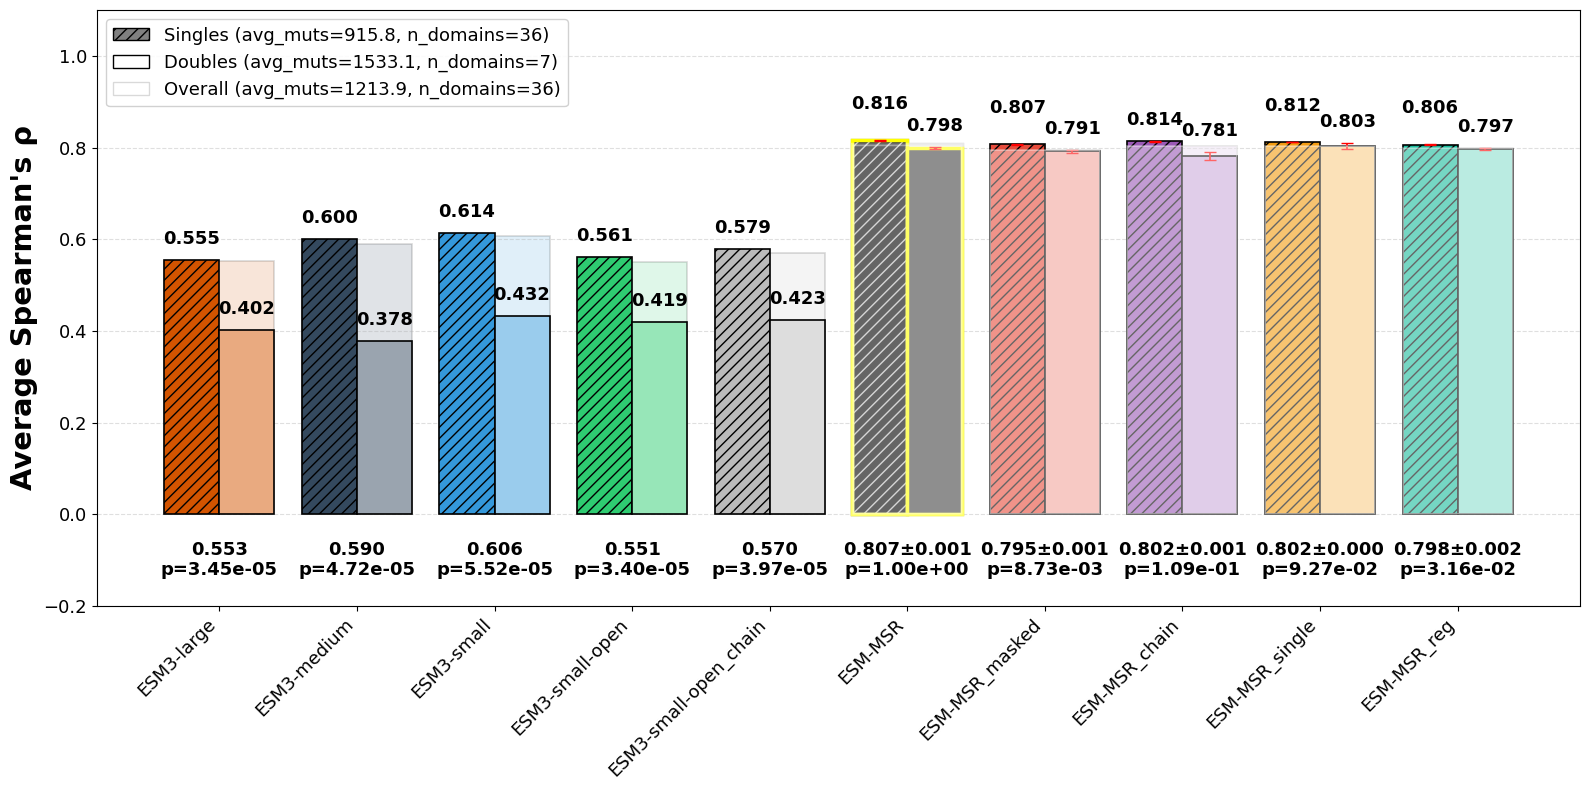

In [11]:
import analysis_utils_msr
import importlib
importlib.reload(analysis_utils_msr)

analysis_utils_msr.create_triple_metric_chart_with_pvals(series_bar1=df_scores.loc[('hyperopt_splits-S-test', 'grouped')], 
                                      series_bar2=df_scores.loc[('hyperopt_splits-D-test', 'grouped')], 
                                      series_overall=df_scores.loc[('hyperopt_splits-test', 'grouped')], 
                                      model_groups=['ESM3-large','ESM3-medium','ESM3-small','ESM3-small-open', 'ESM3-small-open_chain', 'ESM-MSR', 'ESM-MSR_masked', 'ESM-MSR_chain', 'ESM-MSR_single', 'ESM-MSR_reg'],
                                      title=None, y_label='Average Spearman\'s ρ', highlighted_model='ESM-MSR', enforce_global_n=False, ylim=(-0.2,1.1), figsize=(16,8), p_value_y_coord=-0.1, label_min_sep=0.02, fontsize_multiplier=1.3, legend_loc='upper left')

In [12]:
df_gain = pd.DataFrame(index=pd.MultiIndex.from_product([['hyperopt_splits-S-test', 'hyperopt_splits-D-test'], ['ungrouped', 'grouped']]))
df_gain = assess_all_models(df, df_gain, assess_grouped_gain)
df_gain
df_gain[[c for c in df_gain.columns if not '_n' in c]].iloc[:,:15]

ESM-MSR_1
ESM-MSR_2
ESM-MSR_3
ESM-MSR_alpha_med_1
ESM-MSR_alpha_med_2
ESM-MSR_alpha_med_3
ESM-MSR_alpha_low_1
ESM-MSR_alpha_low_2
ESM-MSR_alpha_low_3
ESM-MSR_single_1
ESM-MSR_single_2
ESM-MSR_single_3
ESM-MSR_reg_1
ESM-MSR_reg_2


ESM-MSR_reg_3
ESM-MSR_masked_1
ESM-MSR_masked_2
ESM-MSR_masked_3
ESM-MSR_chain_1
ESM-MSR_chain_2
ESM-MSR_chain_3
SPURS_1
SPURS_2
SPURS_3
ThermoMPNN(-D)_1
ThermoMPNN(-D)_2
ThermoMPNN(-D)_3
MutateEverything_1
MutateEverything_2
MutateEverything_3
ESM3-small-open
ESM3-small-open_chain
ESM3-small
ESM3-medium
ESM3-large
Rosetta Cartesian DDG_1
Rosetta Cartesian DDG_2
Rosetta Cartesian DDG_3
ProteinMPNN


ESM-MSR_1  ESM-MSR_1_groups  ESM-MSR_2  \
hyperopt_splits-S-test ungrouped  68.088159               NaN  82.382406   
                       grouped    25.224809              36.0  25.371494   
hyperopt_splits-D-test ungrouped  50.485806               NaN  53.051134   
                       grouped    17.796520               7.0  16.845944   
hyperopt_splits-test   ungrouped  70.609161               NaN  88.403299   
                       grouped    25.608026              36.0  25.698965   

                                  ESM-MSR_2_groups  ESM-MSR_3  \
hyperopt_splits-S-test ungrouped               NaN  85.766183   
                       grouped                36.0  25.239426   
hyperopt_splits-D-test ungrouped               NaN  53.731760   
                       grouped                 7.0  17.571019   
hyperopt_splits-test   ungrouped               NaN  90.730331   
                       grouped                36.0  25.817809   

                                  ESM-MSR_3_groups  ESM-MSR_alpha_med_1  \
hyperopt_splits-S-test ungrouped               NaN            74.202735   
                       grouped                36.0            22.065949   
hyperopt_splits-D-test ungrouped               NaN            46.099142   
                       grouped                 7.0            16.136365   
hyperopt_splits-test   ungrouped               NaN            76.448963   
                       grouped                36.0            22.648179   

                                  ESM-MSR_alpha_med_1_groups  \
hyperopt_splits-S-test ungrouped                         NaN   
                       grouped                          36.0   
hyperopt_splits-D-test ungrouped                         NaN   
                       grouped                           7.0   
hyperopt_splits-test   ungrouped                         NaN   
                       grouped                          36.0   

                                  ESM-MSR_alpha_med_2  \
hyperopt_splits-S-test ungrouped            71.280895   
                       grouped              21.640920   
hyperopt_splits-D-test ungrouped            43.518383   
                       grouped              15.589462   
hyperopt_splits-test   ungrouped            73.118074   
                       grouped              22.236094   

                                  ESM-MSR_alpha_med_2_groups  \
hyperopt_splits-S-test ungrouped                         NaN   
                       grouped                          36.0   
hyperopt_splits-D-test ungrouped                         NaN   
                       grouped                           7.0   
hyperopt_splits-test   ungrouped                         NaN   
                       grouped                          36.0   

                                  ESM-MSR_alpha_med_3  \
hyperopt_splits-S-test ungrouped            73.509769   
                       grouped              21.360385   
hyperopt_splits-D-test ungrouped            39.017031   
                       grouped              14.878927   
hyperopt_splits-test   ungrouped            75.934083   
                       grouped              21.872139   

                                  ESM-MSR_alpha_med_3_groups  \
hyperopt_splits-S-test ungrouped                         NaN   
                       grouped                          36.0   
hyperopt_splits-D-test ungrouped                         NaN   
                       grouped                           7.0   
hyperopt_splits-test   ungrouped                         NaN   
                       grouped                          36.0   

                                  ESM-MSR_alpha_low_1  \
hyperopt_splits-S-test ungrouped            53.507969   
                       grouped              17.593080   
hyperopt_splits-D-test ungrouped            14.733884   
                       grouped              11.522586   
hyperopt_splits-test   ungrouped            53.507969   
                       grouped

(<Figure size 1600x800 with 1 Axes>, <Axes: ylabel='Average Gain (kcal/mol)'>)

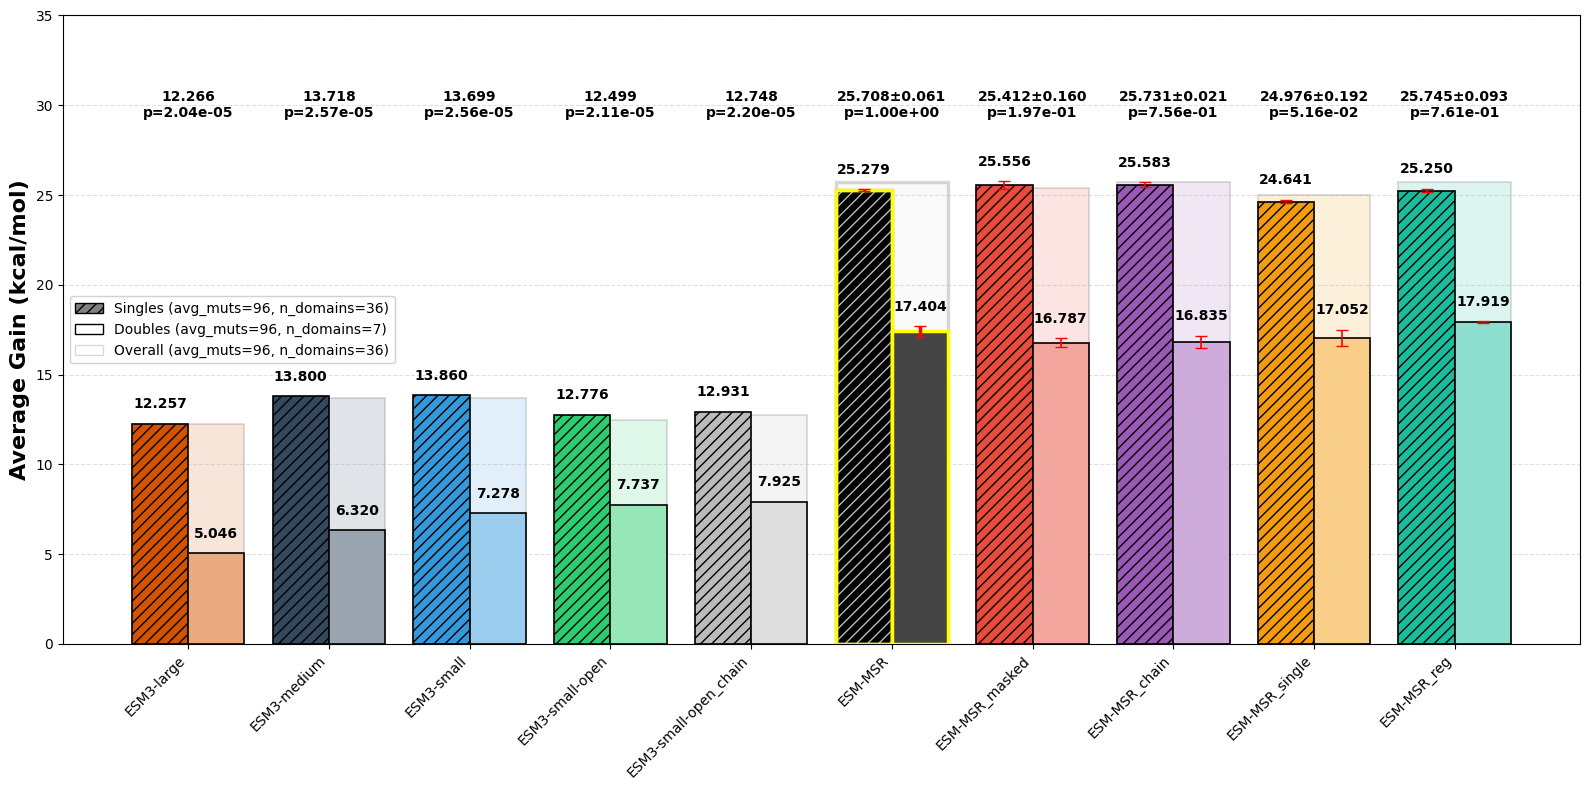

In [13]:
analysis_utils_msr.create_triple_metric_chart_with_pvals(series_bar1=df_gain.loc[('hyperopt_splits-S-test', 'grouped')], 
                                      series_bar2=df_gain.loc[('hyperopt_splits-D-test', 'grouped')], 
                                      series_overall=df_gain.loc[('hyperopt_splits-test', 'grouped')], 
                                      model_groups=['ESM3-large','ESM3-medium','ESM3-small','ESM3-small-open', 'ESM3-small-open_chain', 'ESM-MSR', 'ESM-MSR_masked', 'ESM-MSR_chain', 'ESM-MSR_single', 'ESM-MSR_reg'],
                                      title=None, y_label='Average Gain (kcal/mol)', highlighted_model='ESM-MSR', enforce_global_n=False, ylim=(0, 35), figsize=(16,8), p_value_y_coord=30, label_min_sep=0.02, fontsize_multiplier=1., legend_loc='center left')

In [14]:
df_ndcg24 = pd.DataFrame(index=pd.MultiIndex.from_product([['hyperopt_splits-S-test', 'hyperopt_splits-D-test'], ['ungrouped', 'grouped']]))

# 1. Freeze the top_n argument into a new callable
assess_ndcg_24 = partial(assess_grouped_ndcg, top_n=24)

# 2. Pass the frozen function into your wrapper
df_ndcg24 = assess_all_models(df, df_ndcg24, assess_ndcg_24)

df_ndcg24
df_ndcg24[[c for c in df_ndcg24.columns if not '_n' in c]].iloc[:,:15]

ESM-MSR_1
ESM-MSR_2
ESM-MSR_3
ESM-MSR_alpha_med_1
ESM-MSR_alpha_med_2
ESM-MSR_alpha_med_3
ESM-MSR_alpha_low_1
ESM-MSR_alpha_low_2
ESM-MSR_alpha_low_3
ESM-MSR_single_1
ESM-MSR_single_2
ESM-MSR_single_3
ESM-MSR_reg_1
ESM-MSR_reg_2
ESM-MSR_reg_3
ESM-MSR_masked_1
ESM-MSR_masked_2
ESM-MSR_masked_3
ESM-MSR_chain_1
ESM-MSR_chain_2
ESM-MSR_chain_3
SPURS_1
SPURS_2
SPURS_3
ThermoMPNN(-D)_1
ThermoMPNN(-D)_2
ThermoMPNN(-D)_3
MutateEverything_1
MutateEverything_2
MutateEverything_3
ESM3-small-open
ESM3-small-open_chain
ESM3-small
ESM3-medium
ESM3-large
Rosetta Cartesian DDG_1
Rosetta Cartesian DDG_2
Rosetta Cartesian DDG_3
ProteinMPNN


ESM-MSR_1  ESM-MSR_1_groups  ESM-MSR_2  \
hyperopt_splits-S-test ungrouped   0.440732               NaN   0.568624   
                       grouped     0.493325              36.0   0.502569   
hyperopt_splits-D-test ungrouped   0.629452               NaN   0.703002   
                       grouped     0.704562               7.0   0.649524   
hyperopt_splits-test   ungrouped   0.458112               NaN   0.563053   
                       grouped     0.483178              36.0   0.495696   

                                  ESM-MSR_2_groups  ESM-MSR_3  \
hyperopt_splits-S-test ungrouped               NaN   0.543399   
                       grouped                36.0   0.510097   
hyperopt_splits-D-test ungrouped               NaN   0.709988   
                       grouped                 7.0   0.735647   
hyperopt_splits-test   ungrouped               NaN   0.547327   
                       grouped                36.0   0.503716   

                                  ESM-MSR_3_groups  ESM-MSR_alpha_med_1  \
hyperopt_splits-S-test ungrouped               NaN             0.613492   
                       grouped                36.0             0.451517   
hyperopt_splits-D-test ungrouped               NaN             0.590441   
                       grouped                 7.0             0.559127   
hyperopt_splits-test   ungrouped               NaN             0.621796   
                       grouped                36.0             0.447525   

                                  ESM-MSR_alpha_med_1_groups  \
hyperopt_splits-S-test ungrouped                         NaN   
                       grouped                          36.0   
hyperopt_splits-D-test ungrouped                         NaN   
                       grouped                           7.0   
hyperopt_splits-test   ungrouped                         NaN   
                       grouped                          36.0   

                                  ESM-MSR_alpha_med_2  \
hyperopt_splits-S-test ungrouped             0.648987   
                       grouped               0.445860   
hyperopt_splits-D-test ungrouped             0.611283   
                       grouped               0.539224   
hyperopt_splits-test   ungrouped             0.645742   
                       grouped               0.441535   

                                  ESM-MSR_alpha_med_2_groups  \
hyperopt_splits-S-test ungrouped                         NaN   
                       grouped                          36.0   
hyperopt_splits-D-test ungrouped                         NaN   
                       grouped                           7.0   
hyperopt_splits-test   ungrouped                         NaN   
                       grouped                          36.0   

                                  ESM-MSR_alpha_med_3  \
hyperopt_splits-S-test ungrouped             0.661855   
                       grouped               0.436685   
hyperopt_splits-D-test ungrouped             0.603195   
                       grouped               0.529433   
hyperopt_splits-test   ungrouped             0.667156   
                       grouped               0.432218   

                                  ESM-MSR_alpha_med_3_groups  \
hyperopt_splits-S-test ungrouped                         NaN   
                       grouped                          36.0   
hyperopt_splits-D-test ungrouped                         NaN   
                       grouped                           7.0   
hyperopt_splits-test   ungrouped                         NaN   
                       grouped                          36.0   

                                  ESM-MSR_alpha_low_1  \
hyperopt_splits-S-test ungrouped             0.553437   
                       grouped               0.347872   
hyperopt_splits-D-test ungrouped             0.128180   
                       grouped               0.384765   
hyperopt_splits-test   ungrouped             0.550669   
                       grouped

(<Figure size 1600x800 with 1 Axes>, <Axes: ylabel='Average NDCG@k=24'>)

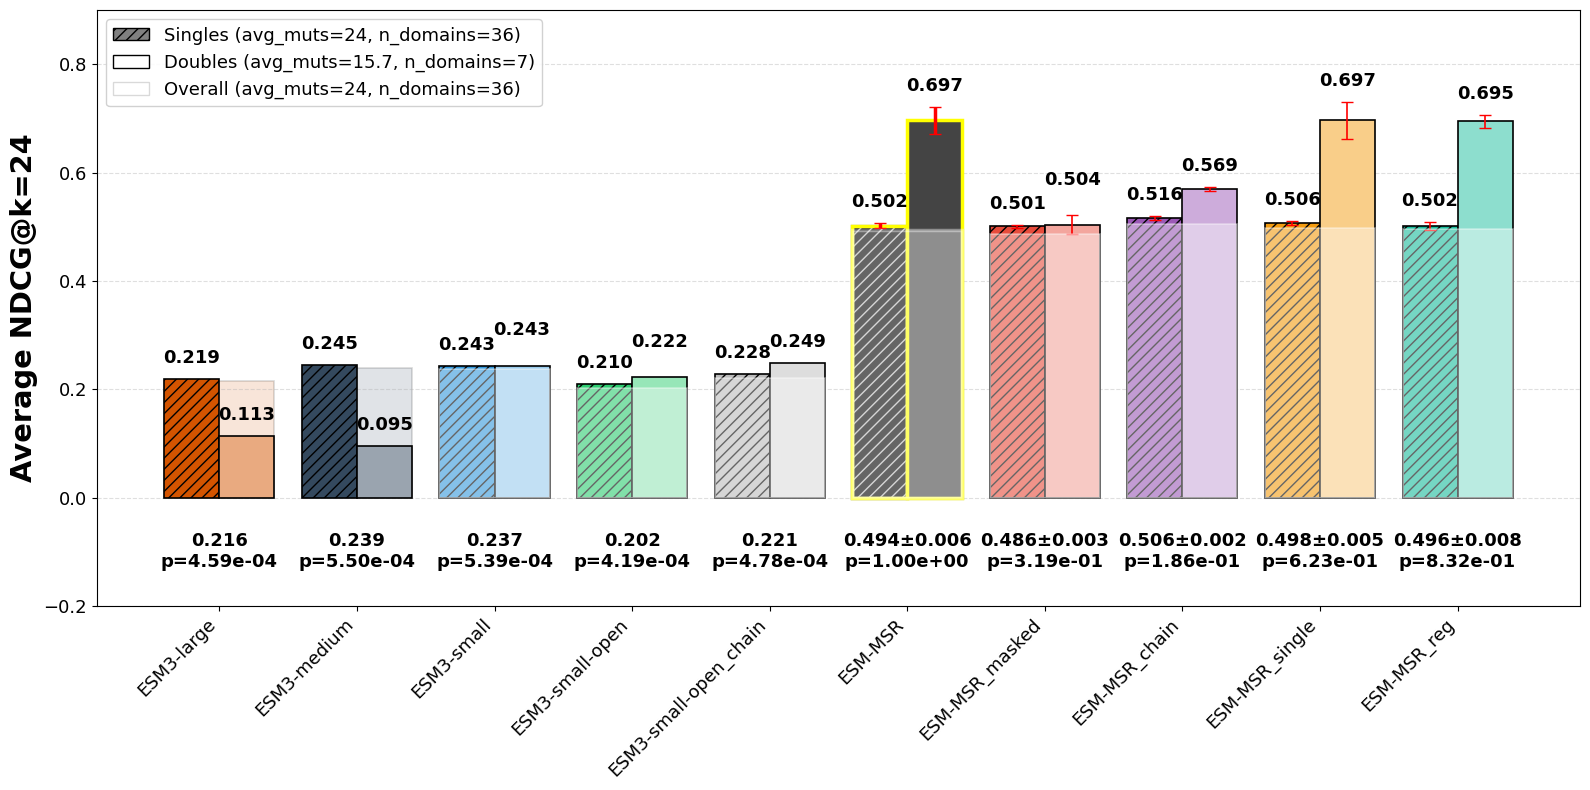

In [15]:
import analysis_utils_msr
import importlib
importlib.reload(analysis_utils_msr)

analysis_utils_msr.create_triple_metric_chart_with_pvals(series_bar1=df_ndcg24.loc[('hyperopt_splits-S-test', 'grouped')], 
                                      series_bar2=df_ndcg24.loc[('hyperopt_splits-D-test', 'grouped')], 
                                      series_overall=df_ndcg24.loc[('hyperopt_splits-test', 'grouped')], 
                                      model_groups=['ESM3-large','ESM3-medium','ESM3-small','ESM3-small-open', 'ESM3-small-open_chain', 'ESM-MSR', 'ESM-MSR_masked', 'ESM-MSR_chain', 'ESM-MSR_single', 'ESM-MSR_reg'],
                                      title=None, y_label='Average NDCG@k=24', highlighted_model='ESM-MSR', enforce_global_n=False, ylim=(-0.2,0.9), figsize=(16,8), p_value_y_coord=-0.1, label_min_sep=0.02, fontsize_multiplier=1.3, legend_loc='upper left')

In [16]:
df_ndcg96 = pd.DataFrame(index=pd.MultiIndex.from_product([['hyperopt_splits-S-test', 'hyperopt_splits-D-test'], ['ungrouped', 'grouped']]))

# 1. Freeze the top_n argument into a new callable
assess_ndcg_96 = partial(assess_grouped_ndcg, top_n=96)

# 2. Pass the frozen function into your wrapper
df_ndcg96 = assess_all_models(df, df_ndcg96, assess_ndcg_96)

df_ndcg96
df_ndcg96[[c for c in df_ndcg96.columns if not '_n' in c]].iloc[:,:15]

ESM-MSR_1
ESM-MSR_2
ESM-MSR_3
ESM-MSR_alpha_med_1
ESM-MSR_alpha_med_2
ESM-MSR_alpha_med_3
ESM-MSR_alpha_low_1
ESM-MSR_alpha_low_2
ESM-MSR_alpha_low_3
ESM-MSR_single_1
ESM-MSR_single_2
ESM-MSR_single_3
ESM-MSR_reg_1
ESM-MSR_reg_2
ESM-MSR_reg_3
ESM-MSR_masked_1
ESM-MSR_masked_2
ESM-MSR_masked_3
ESM-MSR_chain_1
ESM-MSR_chain_2
ESM-MSR_chain_3
SPURS_1
SPURS_2
SPURS_3
ThermoMPNN(-D)_1
ThermoMPNN(-D)_2
ThermoMPNN(-D)_3
MutateEverything_1
MutateEverything_2
MutateEverything_3
ESM3-small-open
ESM3-small-open_chain
ESM3-small
ESM3-medium
ESM3-large
Rosetta Cartesian DDG_1
Rosetta Cartesian DDG_2
Rosetta Cartesian DDG_3
ProteinMPNN


ESM-MSR_1  ESM-MSR_1_groups  ESM-MSR_2  \
hyperopt_splits-S-test ungrouped   0.446728               NaN   0.539985   
                       grouped     0.551163              36.0   0.554083   
hyperopt_splits-D-test ungrouped   0.604912               NaN   0.644516   
                       grouped     0.787543               7.0   0.699025   
hyperopt_splits-test   ungrouped   0.454644               NaN   0.555841   
                       grouped     0.541631              36.0   0.543617   

                                  ESM-MSR_2_groups  ESM-MSR_3  \
hyperopt_splits-S-test ungrouped               NaN   0.552222   
                       grouped                36.0   0.556938   
hyperopt_splits-D-test ungrouped               NaN   0.656599   
                       grouped                 7.0   0.793651   
hyperopt_splits-test   ungrouped               NaN   0.564212   
                       grouped                36.0   0.549518   

                                  ESM-MSR_3_groups  ESM-MSR_alpha_med_1  \
hyperopt_splits-S-test ungrouped               NaN             0.523468   
                       grouped                36.0             0.488862   
hyperopt_splits-D-test ungrouped               NaN             0.568506   
                       grouped                 7.0             0.634303   
hyperopt_splits-test   ungrouped               NaN             0.526787   
                       grouped                36.0             0.483258   

                                  ESM-MSR_alpha_med_1_groups  \
hyperopt_splits-S-test ungrouped                         NaN   
                       grouped                          36.0   
hyperopt_splits-D-test ungrouped                         NaN   
                       grouped                           7.0   
hyperopt_splits-test   ungrouped                         NaN   
                       grouped                          36.0   

                                  ESM-MSR_alpha_med_2  \
hyperopt_splits-S-test ungrouped             0.527792   
                       grouped               0.482408   
hyperopt_splits-D-test ungrouped             0.557863   
                       grouped               0.620002   
hyperopt_splits-test   ungrouped             0.528358   
                       grouped               0.476842   

                                  ESM-MSR_alpha_med_2_groups  \
hyperopt_splits-S-test ungrouped                         NaN   
                       grouped                          36.0   
hyperopt_splits-D-test ungrouped                         NaN   
                       grouped                           7.0   
hyperopt_splits-test   ungrouped                         NaN   
                       grouped                          36.0   

                                  ESM-MSR_alpha_med_3  \
hyperopt_splits-S-test ungrouped             0.541009   
                       grouped               0.472662   
hyperopt_splits-D-test ungrouped             0.521539   
                       grouped               0.598113   
hyperopt_splits-test   ungrouped             0.544847   
                       grouped               0.466497   

                                  ESM-MSR_alpha_med_3_groups  \
hyperopt_splits-S-test ungrouped                         NaN   
                       grouped                          36.0   
hyperopt_splits-D-test ungrouped                         NaN   
                       grouped                           7.0   
hyperopt_splits-test   ungrouped                         NaN   
                       grouped                          36.0   

                                  ESM-MSR_alpha_low_1  \
hyperopt_splits-S-test ungrouped             0.421532   
                       grouped               0.384001   
hyperopt_splits-D-test ungrouped             0.149535   
                       grouped               0.445023   
hyperopt_splits-test   ungrouped             0.414764   
                       grouped

In [17]:
df_ndcg96[[c for c in df_ndcg96.columns if '_n' in c]].iloc[:,:15]

ESM-MSR_1_n  ESM-MSR_2_n  ESM-MSR_3_n  \
hyperopt_splits-S-test ungrouped    96.000000    96.000000    96.000000   
                       grouped      95.111111    95.111111    95.111111   
hyperopt_splits-D-test ungrouped    96.000000    96.000000    96.000000   
                       grouped      44.857143    44.857143    44.857143   
hyperopt_splits-test   ungrouped    96.000000    96.000000    96.000000   
                       grouped      95.111111    95.111111    95.111111   

                                  ESM-MSR_alpha_med_1_n  \
hyperopt_splits-S-test ungrouped              96.000000   
                       grouped                95.111111   
hyperopt_splits-D-test ungrouped              96.000000   
                       grouped                44.857143   
hyperopt_splits-test   ungrouped              96.000000   
                       grouped                95.111111   

                                  ESM-MSR_alpha_med_2_n  \
hyperopt_splits-S-test ungrouped              96.000000   
                       grouped                95.111111   
hyperopt_splits-D-test ungrouped              96.000000   
                       grouped                44.857143   
hyperopt_splits-test   ungrouped              96.000000   
                       grouped                95.111111   

                                  ESM-MSR_alpha_med_3_n  \
hyperopt_splits-S-test ungrouped              96.000000   
                       grouped                95.111111   
hyperopt_splits-D-test ungrouped              96.000000   
                       grouped                44.857143   
hyperopt_splits-test   ungrouped              96.000000   
                       grouped                95.111111   

                                  ESM-MSR_alpha_low_1_n  \
hyperopt_splits-S-test ungrouped              96.000000   
                       grouped                95.111111   
hyperopt_splits-D-test ungrouped              96.000000   
                       grouped                44.857143   
hyperopt_splits-test   ungrouped              96.000000   
                       grouped                95.111111   

                                  ESM-MSR_alpha_low_2_n  \
hyperopt_splits-S-test ungrouped              96.000000   
                       grouped                95.111111   
hyperopt_splits-D-test ungrouped              96.000000   
                       grouped                44.857143   
hyperopt_splits-test   ungrouped              96.000000   
                       grouped                95.111111   

                                  ESM-MSR_alpha_low_3_n  ESM-MSR_single_1_n  \
hyperopt_splits-S-test ungrouped              96.000000           96.000000   
                       grouped                95.111111           95.111111   
hyperopt_splits-D-test ungrouped              96.000000           96.000000   
                       grouped                44.857143           44.857143   
hyperopt_splits-test   ungrouped              96.000000           96.000000   
                       grouped                95.111111           95.111111   

                                  ESM-MSR_single_2_n  ESM-MSR_single_3_n  \
hyperopt_splits-S-test ungrouped           96.000000           96.000000   
                       grouped             95.111111           95.111111   
hyperopt_splits-D-test ungrouped           96.000000           96.000000   
                       grouped             44.857143           44.857143   
hyperopt_splits-test   ungrouped           96.000000           96.000000   
                       grouped             95.111111           95.111111   

                                  ESM-MSR_reg_1_n  ESM-MSR_reg_2_n  \
hyperopt_splits-S-test ungrouped        96.000000        96.000000   
                       grouped          95.111111        95.111111   
hyperopt_splits-D-test ungrouped        96.000000        96.000000   
                       grouped          44.857143        44.857143   
h

In [18]:
df_ndcg96_no_cys = pd.DataFrame(index=pd.MultiIndex.from_product([['hyperopt_splits-S-test', 'hyperopt_splits-D-test'], ['ungrouped', 'grouped']]))
df_no_cys = df.loc[~df.index.str.endswith('C')]
df_ndcg96_no_cys = assess_all_models(df_no_cys, df_ndcg96_no_cys, assess_ndcg_96)
df_ndcg96_no_cys
df_ndcg96_no_cys[[c for c in df_ndcg96_no_cys.columns if not '_n' in c]].iloc[:,:15]

ESM-MSR_1
ESM-MSR_2
ESM-MSR_3
ESM-MSR_alpha_med_1
ESM-MSR_alpha_med_2
ESM-MSR_alpha_med_3
ESM-MSR_alpha_low_1
ESM-MSR_alpha_low_2
ESM-MSR_alpha_low_3
ESM-MSR_single_1
ESM-MSR_single_2
ESM-MSR_single_3
ESM-MSR_reg_1
ESM-MSR_reg_2
ESM-MSR_reg_3
ESM-MSR_masked_1
ESM-MSR_masked_2
ESM-MSR_masked_3
ESM-MSR_chain_1
ESM-MSR_chain_2
ESM-MSR_chain_3
SPURS_1
SPURS_2
SPURS_3
ThermoMPNN(-D)_1
ThermoMPNN(-D)_2
ThermoMPNN(-D)_3
MutateEverything_1
MutateEverything_2
MutateEverything_3
ESM3-small-open
ESM3-small-open_chain
ESM3-small
ESM3-medium
ESM3-large
Rosetta Cartesian DDG_1
Rosetta Cartesian DDG_2
Rosetta Cartesian DDG_3
ProteinMPNN


ESM-MSR_1  ESM-MSR_1_groups  ESM-MSR_2  \
hyperopt_splits-S-test ungrouped   0.461391               NaN   0.549227   
                       grouped     0.574297              36.0   0.572223   
hyperopt_splits-D-test ungrouped   0.610077               NaN   0.651499   
                       grouped     0.756984               7.0   0.711575   
hyperopt_splits-test   ungrouped   0.464454               NaN   0.571530   
                       grouped     0.565488              36.0   0.561685   

                                  ESM-MSR_2_groups  ESM-MSR_3  \
hyperopt_splits-S-test ungrouped               NaN   0.557104   
                       grouped                36.0   0.574562   
hyperopt_splits-D-test ungrouped               NaN   0.681211   
                       grouped                 7.0   0.764576   
hyperopt_splits-test   ungrouped               NaN   0.582544   
                       grouped                36.0   0.568035   

                                  ESM-MSR_3_groups  ESM-MSR_alpha_med_1  \
hyperopt_splits-S-test ungrouped               NaN             0.530799   
                       grouped                36.0             0.498845   
hyperopt_splits-D-test ungrouped               NaN             0.601662   
                       grouped                 7.0             0.755570   
hyperopt_splits-test   ungrouped               NaN             0.534434   
                       grouped                36.0             0.493533   

                                  ESM-MSR_alpha_med_1_groups  \
hyperopt_splits-S-test ungrouped                         NaN   
                       grouped                          36.0   
hyperopt_splits-D-test ungrouped                         NaN   
                       grouped                           7.0   
hyperopt_splits-test   ungrouped                         NaN   
                       grouped                          36.0   

                                  ESM-MSR_alpha_med_2  \
hyperopt_splits-S-test ungrouped             0.534690   
                       grouped               0.492510   
hyperopt_splits-D-test ungrouped             0.596069   
                       grouped               0.730021   
hyperopt_splits-test   ungrouped             0.538761   
                       grouped               0.487595   

                                  ESM-MSR_alpha_med_2_groups  \
hyperopt_splits-S-test ungrouped                         NaN   
                       grouped                          36.0   
hyperopt_splits-D-test ungrouped                         NaN   
                       grouped                           7.0   
hyperopt_splits-test   ungrouped                         NaN   
                       grouped                          36.0   

                                  ESM-MSR_alpha_med_3  \
hyperopt_splits-S-test ungrouped             0.546161   
                       grouped               0.480892   
hyperopt_splits-D-test ungrouped             0.557557   
                       grouped               0.714604   
hyperopt_splits-test   ungrouped             0.551582   
                       grouped               0.475764   

                                  ESM-MSR_alpha_med_3_groups  \
hyperopt_splits-S-test ungrouped                         NaN   
                       grouped                          36.0   
hyperopt_splits-D-test ungrouped                         NaN   
                       grouped                           7.0   
hyperopt_splits-test   ungrouped                         NaN   
                       grouped                          36.0   

                                  ESM-MSR_alpha_low_1  \
hyperopt_splits-S-test ungrouped             0.429014   
                       grouped               0.391878   
hyperopt_splits-D-test ungrouped             0.156089   
                       grouped               0.555369   
hyperopt_splits-test   ungrouped             0.419733   
                       grouped

In [19]:
df_ndcg96_no_cys[[c for c in df_ndcg96_no_cys.columns if '_n' in c]].iloc[:,:15]

ESM-MSR_1_n  ESM-MSR_2_n  ESM-MSR_3_n  \
hyperopt_splits-S-test ungrouped    96.000000    96.000000    96.000000   
                       grouped      94.611111    94.611111    94.611111   
hyperopt_splits-D-test ungrouped    96.000000    96.000000    96.000000   
                       grouped      42.142857    42.142857    42.142857   
hyperopt_splits-test   ungrouped    96.000000    96.000000    96.000000   
                       grouped      94.611111    94.611111    94.611111   

                                  ESM-MSR_alpha_med_1_n  \
hyperopt_splits-S-test ungrouped              96.000000   
                       grouped                94.611111   
hyperopt_splits-D-test ungrouped              96.000000   
                       grouped                42.142857   
hyperopt_splits-test   ungrouped              96.000000   
                       grouped                94.611111   

                                  ESM-MSR_alpha_med_2_n  \
hyperopt_splits-S-test ungrouped              96.000000   
                       grouped                94.611111   
hyperopt_splits-D-test ungrouped              96.000000   
                       grouped                42.142857   
hyperopt_splits-test   ungrouped              96.000000   
                       grouped                94.611111   

                                  ESM-MSR_alpha_med_3_n  \
hyperopt_splits-S-test ungrouped              96.000000   
                       grouped                94.611111   
hyperopt_splits-D-test ungrouped              96.000000   
                       grouped                42.142857   
hyperopt_splits-test   ungrouped              96.000000   
                       grouped                94.611111   

                                  ESM-MSR_alpha_low_1_n  \
hyperopt_splits-S-test ungrouped              96.000000   
                       grouped                94.611111   
hyperopt_splits-D-test ungrouped              96.000000   
                       grouped                42.142857   
hyperopt_splits-test   ungrouped              96.000000   
                       grouped                94.611111   

                                  ESM-MSR_alpha_low_2_n  \
hyperopt_splits-S-test ungrouped              96.000000   
                       grouped                94.611111   
hyperopt_splits-D-test ungrouped              96.000000   
                       grouped                42.142857   
hyperopt_splits-test   ungrouped              96.000000   
                       grouped                94.611111   

                                  ESM-MSR_alpha_low_3_n  ESM-MSR_single_1_n  \
hyperopt_splits-S-test ungrouped              96.000000           96.000000   
                       grouped                94.611111           94.611111   
hyperopt_splits-D-test ungrouped              96.000000           96.000000   
                       grouped                42.142857           42.142857   
hyperopt_splits-test   ungrouped              96.000000           96.000000   
                       grouped                94.611111           94.611111   

                                  ESM-MSR_single_2_n  ESM-MSR_single_3_n  \
hyperopt_splits-S-test ungrouped           96.000000           96.000000   
                       grouped             94.611111           94.611111   
hyperopt_splits-D-test ungrouped           96.000000           96.000000   
                       grouped             42.142857           42.142857   
hyperopt_splits-test   ungrouped           96.000000           96.000000   
                       grouped             94.611111           94.611111   

                                  ESM-MSR_reg_1_n  ESM-MSR_reg_2_n  \
hyperopt_splits-S-test ungrouped        96.000000        96.000000   
                       grouped          94.611111        94.611111   
hyperopt_splits-D-test ungrouped        96.000000        96.000000   
                       grouped          42.142857        42.142857   
h

In [20]:
df_ndcg96_no_cys[[c for c in df_ndcg96_no_cys.columns if '_group' in c]].iloc[:,:15]

ESM-MSR_1_groups  ESM-MSR_2_groups  \
hyperopt_splits-S-test ungrouped               NaN               NaN   
                       grouped                36.0              36.0   
hyperopt_splits-D-test ungrouped               NaN               NaN   
                       grouped                 7.0               7.0   
hyperopt_splits-test   ungrouped               NaN               NaN   
                       grouped                36.0              36.0   

                                  ESM-MSR_3_groups  \
hyperopt_splits-S-test ungrouped               NaN   
                       grouped                36.0   
hyperopt_splits-D-test ungrouped               NaN   
                       grouped                 7.0   
hyperopt_splits-test   ungrouped               NaN   
                       grouped                36.0   

                                  ESM-MSR_alpha_med_1_groups  \
hyperopt_splits-S-test ungrouped                         NaN   
                       grouped                          36.0   
hyperopt_splits-D-test ungrouped                         NaN   
                       grouped                           7.0   
hyperopt_splits-test   ungrouped                         NaN   
                       grouped                          36.0   

                                  ESM-MSR_alpha_med_2_groups  \
hyperopt_splits-S-test ungrouped                         NaN   
                       grouped                          36.0   
hyperopt_splits-D-test ungrouped                         NaN   
                       grouped                           7.0   
hyperopt_splits-test   ungrouped                         NaN   
                       grouped                          36.0   

                                  ESM-MSR_alpha_med_3_groups  \
hyperopt_splits-S-test ungrouped                         NaN   
                       grouped                          36.0   
hyperopt_splits-D-test ungrouped                         NaN   
                       grouped                           7.0   
hyperopt_splits-test   ungrouped                         NaN   
                       grouped                          36.0   

                                  ESM-MSR_alpha_low_1_groups  \
hyperopt_splits-S-test ungrouped                         NaN   
                       grouped                          36.0   
hyperopt_splits-D-test ungrouped                         NaN   
                       grouped                           7.0   
hyperopt_splits-test   ungrouped                         NaN   
                       grouped                          36.0   

                                  ESM-MSR_alpha_low_2_groups  \
hyperopt_splits-S-test ungrouped                         NaN   
                       grouped                          36.0   
hyperopt_splits-D-test ungrouped                         NaN   
                       grouped                           7.0   
hyperopt_splits-test   ungrouped                         NaN   
                       grouped                          36.0   

                                  ESM-MSR_alpha_low_3_groups  \
hyperopt_splits-S-test ungrouped                         NaN   
                       grouped                          36.0   
hyperopt_splits-D-test ungrouped                         NaN   
                       grouped                           7.0   
hyperopt_splits-test   ungrouped                         NaN   
                       grouped                          36.0   

                                  ESM-MSR_single_1_groups  \
hyperopt_splits-S-test ungrouped                      NaN   
                       grouped                       36.0   
hyperopt_splits-D-test ungrouped                      NaN   
                       grouped                        7.0   
hyperopt_splits-test   ungrouped                      NaN   
                       grouped                       36.0   

                            

In [21]:
df_ndcg96_no_cys[[c for c in df_ndcg96_no_cys.columns if '_n' in c]].iloc[:,15:30]

ESM-MSR_masked_1_n  ESM-MSR_masked_2_n  \
hyperopt_splits-S-test ungrouped           96.000000           96.000000   
                       grouped             94.611111           94.611111   
hyperopt_splits-D-test ungrouped           96.000000           96.000000   
                       grouped             42.142857           42.142857   
hyperopt_splits-test   ungrouped           96.000000           96.000000   
                       grouped             94.611111           94.611111   

                                  ESM-MSR_masked_3_n  ESM-MSR_chain_1_n  \
hyperopt_splits-S-test ungrouped           96.000000          96.000000   
                       grouped             94.611111          94.611111   
hyperopt_splits-D-test ungrouped           96.000000          96.000000   
                       grouped             42.142857          42.142857   
hyperopt_splits-test   ungrouped           96.000000          96.000000   
                       grouped             94.611111          94.611111   

                                  ESM-MSR_chain_2_n  ESM-MSR_chain_3_n  \
hyperopt_splits-S-test ungrouped          96.000000          96.000000   
                       grouped            94.611111          94.611111   
hyperopt_splits-D-test ungrouped          96.000000          96.000000   
                       grouped            42.142857          42.142857   
hyperopt_splits-test   ungrouped          96.000000          96.000000   
                       grouped            94.611111          94.611111   

                                  SPURS_1_n  SPURS_2_n  SPURS_3_n  \
hyperopt_splits-S-test ungrouped  96.000000  96.000000  96.000000   
                       grouped    94.611111  94.611111  94.611111   
hyperopt_splits-D-test ungrouped  96.000000  96.000000  96.000000   
                       grouped    42.142857  42.142857  42.142857   
hyperopt_splits-test   ungrouped  96.000000  96.000000  96.000000   
                       grouped    94.611111  94.611111  94.611111   

                                  ThermoMPNN(-D)_1_n  ThermoMPNN(-D)_2_n  \
hyperopt_splits-S-test ungrouped           96.000000           96.000000   
                       grouped             94.611111           94.611111   
hyperopt_splits-D-test ungrouped           96.000000           96.000000   
                       grouped             42.142857           42.142857   
hyperopt_splits-test   ungrouped           96.000000           96.000000   
                       grouped             94.611111           94.611111   

                                  ThermoMPNN(-D)_3_n  MutateEverything_1_n  \
hyperopt_splits-S-test ungrouped           96.000000             96.000000   
                       grouped             94.611111             94.611111   
hyperopt_splits-D-test ungrouped           96.000000             96.000000   
                       grouped             42.142857             42.142857   
hyperopt_splits-test   ungrouped           96.000000             96.000000   
                       grouped             94.611111             94.611111   

                                  MutateEverything_2_n  MutateEverything_3_n  
hyperopt_splits-S-test ungrouped             96.000000             96.000000  
                       grouped               94.611111             94.611111  
hyperopt_splits-D-test ungrouped             96.000000             96.000000  
                       grouped               42.142857             42.142857  
hyperopt_splits-test   ungrouped             96.000000             96.000000  
                       grouped               94.611111             94.611111

(<Figure size 1600x800 with 1 Axes>,
 <Axes: ylabel='Average NDCG@k=96 (No Cys.)'>)

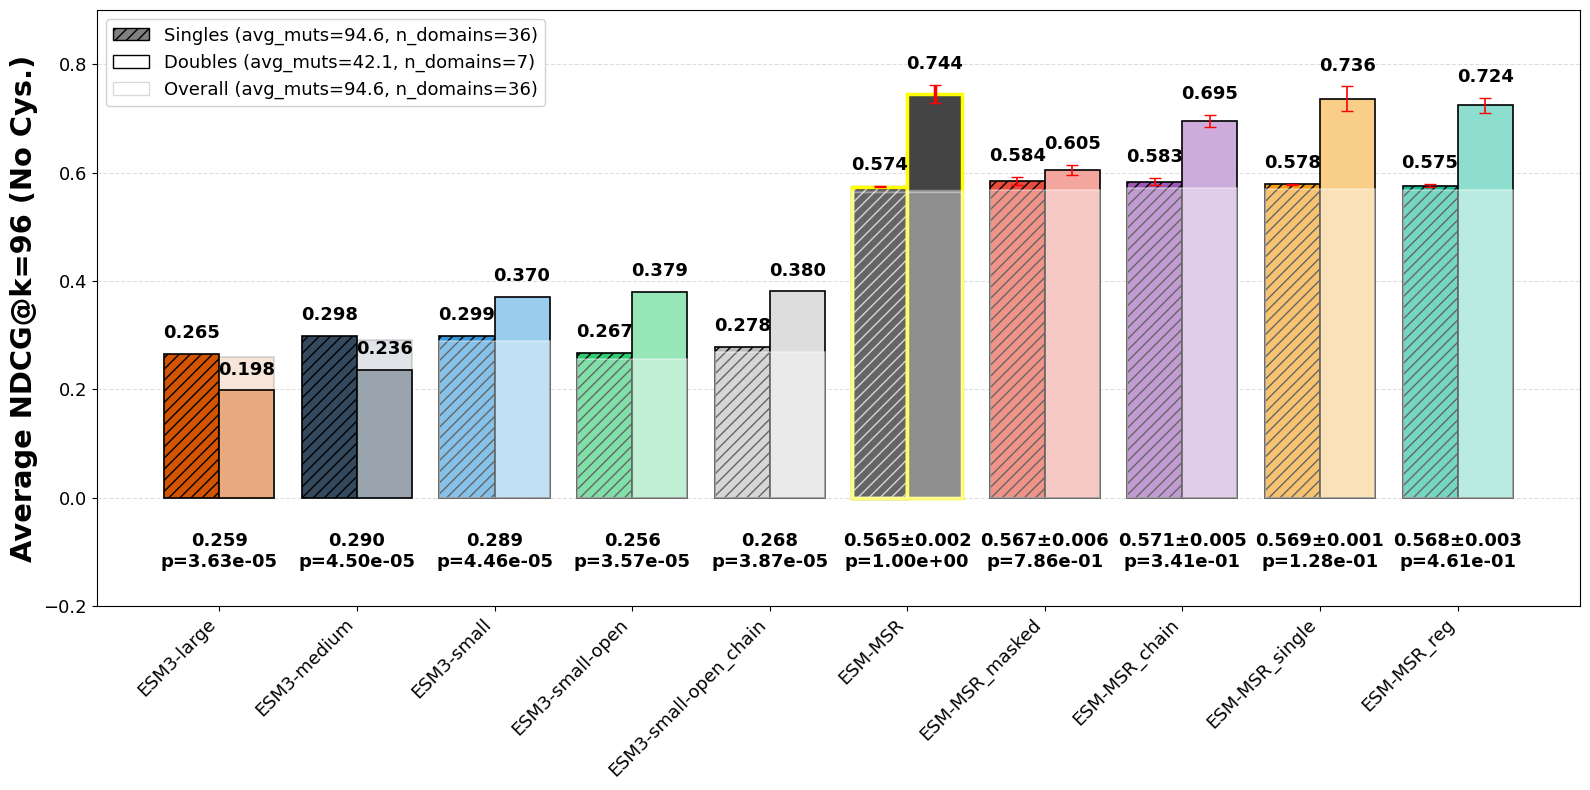

In [22]:
import analysis_utils_msr
import importlib
importlib.reload(analysis_utils_msr)

analysis_utils_msr.create_triple_metric_chart_with_pvals(series_bar1=df_ndcg96_no_cys.loc[('hyperopt_splits-S-test', 'grouped')], 
                                      series_bar2=df_ndcg96_no_cys.loc[('hyperopt_splits-D-test', 'grouped')], 
                                      series_overall=df_ndcg96_no_cys.loc[('hyperopt_splits-test', 'grouped')], 
                                      model_groups=['ESM3-large','ESM3-medium','ESM3-small','ESM3-small-open', 'ESM3-small-open_chain', 'ESM-MSR', 'ESM-MSR_masked', 'ESM-MSR_chain', 'ESM-MSR_single', 'ESM-MSR_reg'],
                                      title=None, y_label='Average NDCG@k=96 (No Cys.)', highlighted_model='ESM-MSR', enforce_global_n=False, ylim=(-0.2,0.9), figsize=(16,8), p_value_y_coord=-0.1, label_min_sep=0.02, fontsize_multiplier=1.3, legend_loc='upper left')

(<Figure size 1600x800 with 1 Axes>, <Axes: ylabel='Average NDCG@k=96'>)

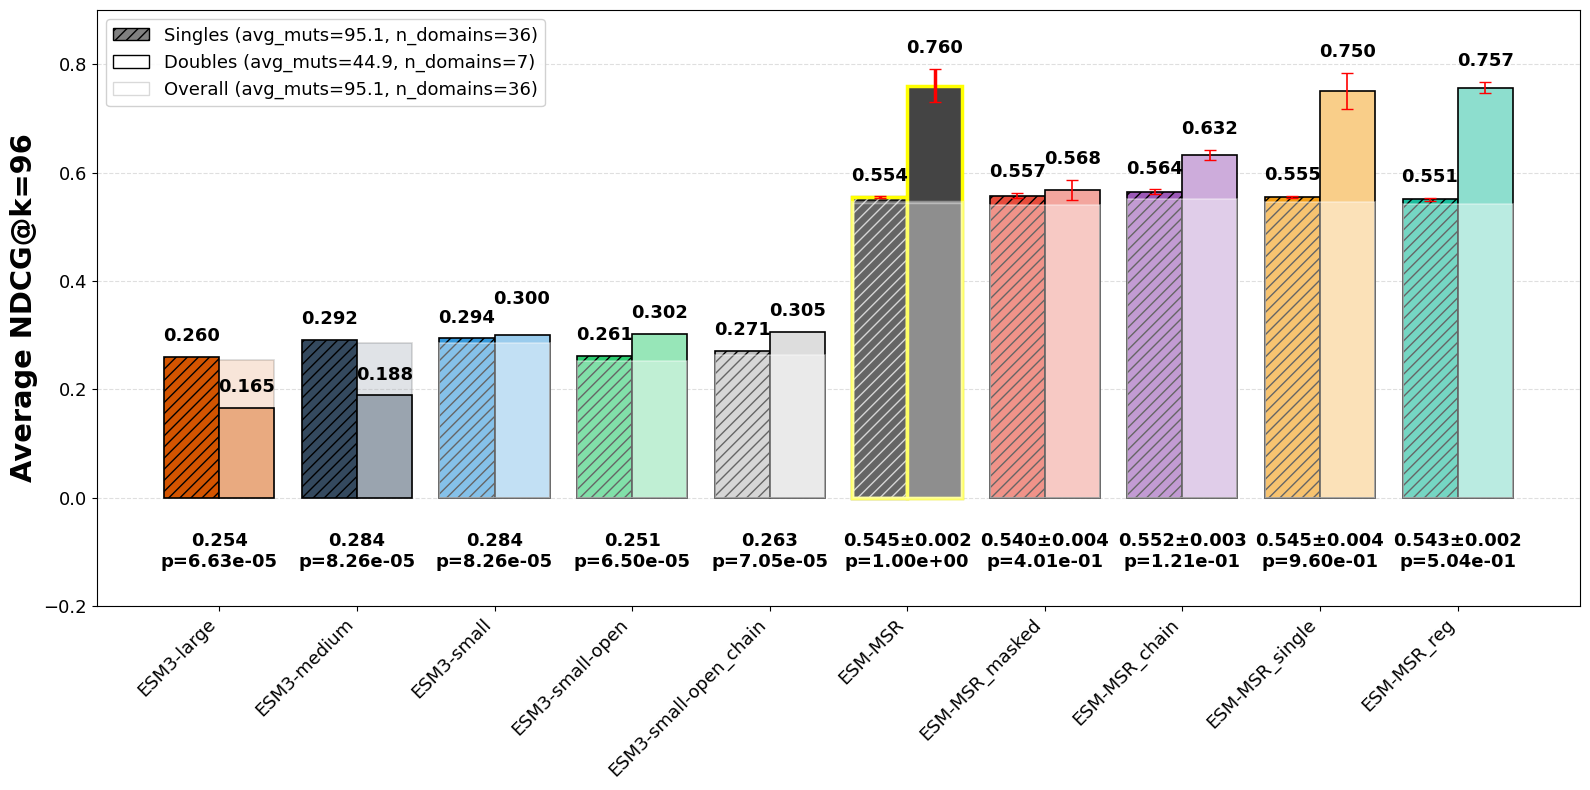

In [23]:
analysis_utils_msr.create_triple_metric_chart_with_pvals(series_bar1=df_ndcg96.loc[('hyperopt_splits-S-test', 'grouped')], 
                                      series_bar2=df_ndcg96.loc[('hyperopt_splits-D-test', 'grouped')], 
                                      series_overall=df_ndcg96.loc[('hyperopt_splits-test', 'grouped')], 
                                      model_groups=['ESM3-large','ESM3-medium','ESM3-small','ESM3-small-open', 'ESM3-small-open_chain', 'ESM-MSR', 'ESM-MSR_masked', 'ESM-MSR_chain', 'ESM-MSR_single', 'ESM-MSR_reg'],
                                      title=None, y_label='Average NDCG@k=96', highlighted_model='ESM-MSR', enforce_global_n=False, ylim=(-0.2,0.9), figsize=(16,8), p_value_y_coord=-0.1, label_min_sep=0.02, fontsize_multiplier=1.3, legend_loc='upper left')

In [24]:
df_ndcg_pos = pd.DataFrame(index=pd.MultiIndex.from_product([['hyperopt_splits-S-test', 'hyperopt_splits-D-test'], ['ungrouped', 'grouped']]))

# 1. Freeze the top_n argument into a new callable
assess_ndcg_pos = partial(assess_grouped_ndcg, threshold=0)

# 2. Pass the frozen function into your wrapper
df_ndcg_pos = assess_all_models(df, df_ndcg_pos, assess_ndcg_pos)

df_ndcg_pos
df_ndcg_pos[[c for c in df_ndcg_pos.columns if not '_n' in c]].iloc[:,:15]


ESM-MSR_1
ESM-MSR_2
ESM-MSR_3
ESM-MSR_alpha_med_1
ESM-MSR_alpha_med_2
ESM-MSR_alpha_med_3
ESM-MSR_alpha_low_1
ESM-MSR_alpha_low_2
ESM-MSR_alpha_low_3
ESM-MSR_single_1
ESM-MSR_single_2
ESM-MSR_single_3
ESM-MSR_reg_1
ESM-MSR_reg_2
ESM-MSR_reg_3
ESM-MSR_masked_1
ESM-MSR_masked_2
ESM-MSR_masked_3
ESM-MSR_chain_1
ESM-MSR_chain_2
ESM-MSR_chain_3
SPURS_1
SPURS_2
SPURS_3
ThermoMPNN(-D)_1
ThermoMPNN(-D)_2
ThermoMPNN(-D)_3
MutateEverything_1
MutateEverything_2
MutateEverything_3
ESM3-small-open
ESM3-small-open_chain
ESM3-small
ESM3-medium
ESM3-large
Rosetta Cartesian DDG_1
Rosetta Cartesian DDG_2
Rosetta Cartesian DDG_3
ProteinMPNN


ESM-MSR_1  ESM-MSR_1_groups  ESM-MSR_2  \
hyperopt_splits-S-test ungrouped   0.848576               NaN   0.857328   
                       grouped     0.765541              36.0   0.769049   
hyperopt_splits-D-test ungrouped   0.799619               NaN   0.815078   
                       grouped     0.845431               7.0   0.774881   
hyperopt_splits-test   ungrouped   0.850210               NaN   0.858608   
                       grouped     0.763130              36.0   0.766362   

                                  ESM-MSR_2_groups  ESM-MSR_3  \
hyperopt_splits-S-test ungrouped               NaN   0.860076   
                       grouped                36.0   0.773500   
hyperopt_splits-D-test ungrouped               NaN   0.813884   
                       grouped                 7.0   0.855678   
hyperopt_splits-test   ungrouped               NaN   0.861331   
                       grouped                36.0   0.771074   

                                  ESM-MSR_3_groups  ESM-MSR_alpha_med_1  \
hyperopt_splits-S-test ungrouped               NaN             0.845036   
                       grouped                36.0             0.739211   
hyperopt_splits-D-test ungrouped               NaN             0.774216   
                       grouped                 7.0             0.711831   
hyperopt_splits-test   ungrouped               NaN             0.845389   
                       grouped                36.0             0.737983   

                                  ESM-MSR_alpha_med_1_groups  \
hyperopt_splits-S-test ungrouped                         NaN   
                       grouped                          36.0   
hyperopt_splits-D-test ungrouped                         NaN   
                       grouped                           7.0   
hyperopt_splits-test   ungrouped                         NaN   
                       grouped                          36.0   

                                  ESM-MSR_alpha_med_2  \
hyperopt_splits-S-test ungrouped             0.844747   
                       grouped               0.738379   
hyperopt_splits-D-test ungrouped             0.775577   
                       grouped               0.704173   
hyperopt_splits-test   ungrouped             0.844674   
                       grouped               0.737022   

                                  ESM-MSR_alpha_med_2_groups  \
hyperopt_splits-S-test ungrouped                         NaN   
                       grouped                          36.0   
hyperopt_splits-D-test ungrouped                         NaN   
                       grouped                           7.0   
hyperopt_splits-test   ungrouped                         NaN   
                       grouped                          36.0   

                                  ESM-MSR_alpha_med_3  \
hyperopt_splits-S-test ungrouped             0.845288   
                       grouped               0.732719   
hyperopt_splits-D-test ungrouped             0.763244   
                       grouped               0.696834   
hyperopt_splits-test   ungrouped             0.844845   
                       grouped               0.731091   

                                  ESM-MSR_alpha_med_3_groups  \
hyperopt_splits-S-test ungrouped                         NaN   
                       grouped                          36.0   
hyperopt_splits-D-test ungrouped                         NaN   
                       grouped                           7.0   
hyperopt_splits-test   ungrouped                         NaN   
                       grouped                          36.0   

                                  ESM-MSR_alpha_low_1  \
hyperopt_splits-S-test ungrouped             0.807860   
                       grouped               0.682118   
hyperopt_splits-D-test ungrouped             0.561585   
                       grouped               0.602405   
hyperopt_splits-test   ungrouped             0.802678   
                       grouped

(<Figure size 1600x800 with 1 Axes>, <Axes: ylabel='Average NDCG'>)

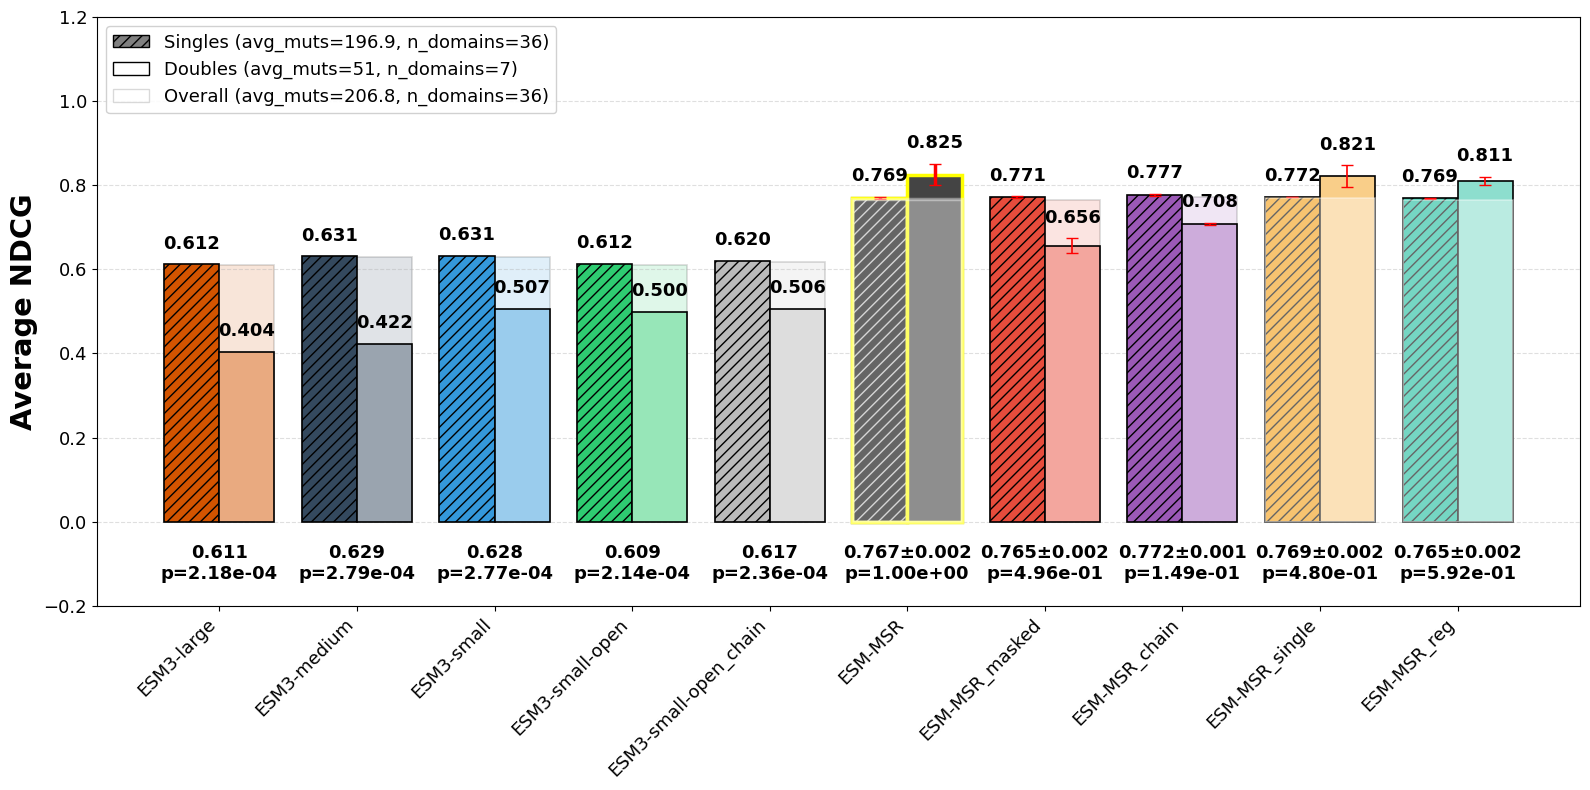

In [25]:
analysis_utils_msr.create_triple_metric_chart_with_pvals(series_bar1=df_ndcg_pos.loc[('hyperopt_splits-S-test', 'grouped')], 
                                      series_bar2=df_ndcg_pos.loc[('hyperopt_splits-D-test', 'grouped')], 
                                      series_overall=df_ndcg_pos.loc[('hyperopt_splits-test', 'grouped')], 
                                      model_groups=['ESM3-large','ESM3-medium','ESM3-small','ESM3-small-open', 'ESM3-small-open_chain', 'ESM-MSR', 'ESM-MSR_masked', 'ESM-MSR_chain', 'ESM-MSR_single', 'ESM-MSR_reg'],
                                      title=None, y_label='Average NDCG', highlighted_model='ESM-MSR', enforce_global_n=False, ylim=(-0.2,1.2), figsize=(16,8), p_value_y_coord=-0.1, label_min_sep=0.02, fontsize_multiplier=1.3, legend_loc='upper left')

In [26]:
# add additive scores
# should be 556 mutants missing
import analysis_utils_msr
import importlib
importlib.reload(analysis_utils_msr)
#from analysis_utils_msr import sum_individual_mutation_scores

#cols = df.columns.drop('code').drop('mut_type')
#cols = ['Rosetta Cartesian DDG_1', 'Rosetta Cartesian DDG_2', 'Rosetta Cartesian DDG_3', 'ddG_ML_me']
cols = ['ddG']
df_epistatic = df.copy(deep=True)

#print(len(df.loc[df['mut_type'].str.contains(':')]))
for c in cols:
    if not c.endswith('_n'):
        print(c)
        # synthesize additive mutation predictions and scores
        df_epistatic = sum_individual_mutation_scores(df_epistatic, c, new_score_column=None) #, df_missing, missing1, missing2

#df_epistatic = df_epistatic[[c for c in df_epistatic.columns if 'additive' in c] + ['code', 'ddG', 'mut_type']]
df_epistatic = df_epistatic[[c for c in df_epistatic.columns if not c.endswith('_n')]]
df_epistatic = df_epistatic.dropna(subset='ESM-MSR_1')
#df_epistatic.loc[df_epistatic.index.str.contains(':'), 'ThermoMPNN(-D)_1_additive'] = df_epistatic.loc[df_epistatic.index.str.contains(':'), 'ThermoMPNN_1']
#df_epistatic.loc[df_epistatic.index.str.contains(':'), 'ThermoMPNN(-D)_2_additive'] = df_epistatic.loc[df_epistatic.index.str.contains(':'), 'ThermoMPNN_2']
#df_epistatic.loc[df_epistatic.index.str.contains(':'), 'ThermoMPNN(-D)_3_additive'] = df_epistatic.loc[df_epistatic.index.str.contains(':'), 'ThermoMPNN_3']

#print(len(df_epistatic))
#df_epistatic['ThermoMPNN(-D)_1_additive'].dropna()

ddG


In [27]:
# Get all grouped and ungrouped ranking correlations for epistatic / combined mutants

df_scores_epistatic = pd.DataFrame(index=pd.MultiIndex.from_product([['hyperopt_splits-D-test'], ['ungrouped', 'grouped']]))

assess_all_models(df_epistatic.loc[df_epistatic['mut_type'].str.contains(':')], df_scores_epistatic, assess_grouped_spearman, splits=['hyperopt_splits-D-test'])

df_scores_epistatic

ESM-MSR_1
ESM-MSR_2
ESM-MSR_3
ESM-MSR_alpha_med_1
ESM-MSR_alpha_med_2
ESM-MSR_alpha_med_3
ESM-MSR_alpha_low_1
ESM-MSR_alpha_low_2
ESM-MSR_alpha_low_3
ESM-MSR_single_1
ESM-MSR_single_2
ESM-MSR_single_3
ESM-MSR_reg_1
ESM-MSR_reg_2
ESM-MSR_reg_3
ESM-MSR_masked_1
ESM-MSR_masked_2
ESM-MSR_masked_3
ESM-MSR_chain_1
ESM-MSR_chain_2
ESM-MSR_chain_3
SPURS_1
SPURS_2
SPURS_3
ThermoMPNN(-D)_1
ThermoMPNN(-D)_2
ThermoMPNN(-D)_3
MutateEverything_1
MutateEverything_2
MutateEverything_3
ESM3-small-open
ESM3-small-open_chain
ESM3-small
ESM3-medium
ESM3-large
Rosetta Cartesian DDG_1
Rosetta Cartesian DDG_2
Rosetta Cartesian DDG_3
ProteinMPNN


ESM-MSR_1   ESM-MSR_1_n  ESM-MSR_1_groups  \
hyperopt_splits-D-test ungrouped   0.352032  10732.000000               NaN   
                       grouped     0.800176   1533.142857               7.0   

                                  ESM-MSR_2   ESM-MSR_2_n  ESM-MSR_2_groups  \
hyperopt_splits-D-test ungrouped   0.364904  10732.000000               NaN   
                       grouped     0.794892   1533.142857               7.0   

                                  ESM-MSR_3   ESM-MSR_3_n  ESM-MSR_3_groups  \
hyperopt_splits-D-test ungrouped   0.353008  10732.000000               NaN   
                       grouped     0.800261   1533.142857               7.0   

                                  ESM-MSR_alpha_med_1  ...  \
hyperopt_splits-D-test ungrouped             0.344491  ...   
                       grouped               0.739334  ...   

                                  Rosetta Cartesian DDG_1_groups  \
hyperopt_splits-D-test ungrouped                             NaN   
                       grouped                               7.0   

                                  Rosetta Cartesian DDG_2  \
hyperopt_splits-D-test ungrouped                 0.481485   
                       grouped                   0.461834   

                                  Rosetta Cartesian DDG_2_n  \
hyperopt_splits-D-test ungrouped               10732.000000   
                       grouped                  1533.142857   

                                  Rosetta Cartesian DDG_2_groups  \
hyperopt_splits-D-test ungrouped                             NaN   
                       grouped                               7.0   

                                  Rosetta Cartesian DDG_3  \
hyperopt_splits-D-test ungrouped                 0.481839   
                       grouped                   0.466217   

                                  Rosetta Cartesian DDG_3_n  \
hyperopt_splits-D-test ungrouped               10732.000000   
                       grouped                  1533.142857   

                                  Rosetta Cartesian DDG_3_groups  ProteinMPNN  \
hyperopt_splits-D-test ungrouped                             NaN     0.211427   
                       grouped                               7.0     0.426416   

                                  ProteinMPNN_n  ProteinMPNN_groups  
hyperopt_splits-D-test ungrouped   10732.000000                 NaN  
                       grouped      1533.142857                 7.0  

[2 rows x 117 columns]

In [28]:
assess_all_models(df_epistatic.loc[df_epistatic['mut_type'].str.contains(':')], df_scores_epistatic, assess_grouped_spearman, splits=['hyperopt_splits-D-test'], add_suffix='_additive')
df_scores_epistatic = assess_grouped_spearman(df_epistatic.loc[df_epistatic['mut_type'].str.contains(':')], df_scores_epistatic, 'Negative_additive', 'hyperopt_splits-D-test', pred_col='ddG_additive', label='ddG')

df_scores_epistatic

ESM-MSR_1
ESM-MSR_2
ESM-MSR_3
ESM-MSR_alpha_med_1
ESM-MSR_alpha_med_2
ESM-MSR_alpha_med_3
ESM-MSR_alpha_low_1
ESM-MSR_alpha_low_2
ESM-MSR_alpha_low_3
ESM-MSR_single_1
ESM-MSR_single_2
ESM-MSR_single_3
ESM-MSR_reg_1
ESM-MSR_reg_2
ESM-MSR_reg_3
ESM-MSR_masked_1
ESM-MSR_masked_2
ESM-MSR_masked_3
ESM-MSR_chain_1
ESM-MSR_chain_2
ESM-MSR_chain_3
SPURS_1
SPURS_2
SPURS_3
ThermoMPNN(-D)_1
ThermoMPNN(-D)_2
ThermoMPNN(-D)_3
MutateEverything_1
MutateEverything_2
MutateEverything_3
ESM3-small-open
ESM3-small-open_chain
ESM3-small
ESM3-medium
ESM3-large
Rosetta Cartesian DDG_1
Rosetta Cartesian DDG_2
Rosetta Cartesian DDG_3
ProteinMPNN


ESM-MSR_1   ESM-MSR_1_n  ESM-MSR_1_groups  \
hyperopt_splits-D-test ungrouped   0.352032  10732.000000               NaN   
                       grouped     0.800176   1533.142857               7.0   

                                  ESM-MSR_2   ESM-MSR_2_n  ESM-MSR_2_groups  \
hyperopt_splits-D-test ungrouped   0.364904  10732.000000               NaN   
                       grouped     0.794892   1533.142857               7.0   

                                  ESM-MSR_3   ESM-MSR_3_n  ESM-MSR_3_groups  \
hyperopt_splits-D-test ungrouped   0.353008  10732.000000               NaN   
                       grouped     0.800261   1533.142857               7.0   

                                  ESM-MSR_alpha_med_1  ...  \
hyperopt_splits-D-test ungrouped             0.344491  ...   
                       grouped               0.739334  ...   

                                  Rosetta Cartesian DDG_additive_2_groups  \
hyperopt_splits-D-test ungrouped                                      NaN   
                       grouped                                        7.0   

                                  Rosetta Cartesian DDG_additive_3  \
hyperopt_splits-D-test ungrouped                          0.393372   
                       grouped                            0.372765   

                                  Rosetta Cartesian DDG_additive_3_n  \
hyperopt_splits-D-test ungrouped                        10699.000000   
                       grouped                           1528.428571   

                                  Rosetta Cartesian DDG_additive_3_groups  \
hyperopt_splits-D-test ungrouped                                      NaN   
                       grouped                                        7.0   

                                  ProteinMPNN_additive  \
hyperopt_splits-D-test ungrouped              0.130812   
                       grouped                0.377328   

                                  ProteinMPNN_additive_n  \
hyperopt_splits-D-test ungrouped            10732.000000   
                       grouped               1533.142857   

                                  ProteinMPNN_additive_groups  \
hyperopt_splits-D-test ungrouped                          NaN   
                       grouped                            7.0   

                                  Negative_additive  Negative_additive_n  \
hyperopt_splits-D-test ungrouped           0.730326         10176.000000   
                       grouped             0.784848          1453.714286   

                                  Negative_additive_groups  
hyperopt_splits-D-test ungrouped                       NaN  
                       grouped                         7.0  

[2 rows x 237 columns]

In [29]:
# Peek at the additive correlations

df_scores_additive_2 = df_scores_epistatic[[c for c in df_scores_epistatic.columns if c.endswith('_additive')]]#.dropna()
df_scores_additive_2.columns = [c[:-9] for c in df_scores_additive_2.columns]
df_scores_additive_2

ESM3-small-open  ESM3-small-open_chain  \
hyperopt_splits-D-test ungrouped         0.065987               0.051884   
                       grouped           0.355787               0.365291   

                                  ESM3-small  ESM3-medium  ESM3-large  \
hyperopt_splits-D-test ungrouped    0.115948     0.357528    0.396180   
                       grouped      0.397451     0.339708    0.319223   

                                  ProteinMPNN  Negative  
hyperopt_splits-D-test ungrouped     0.130812  0.730326  
                       grouped       0.377328  0.784848

In [30]:
# compress replicates into mean and stdev
df_scores_std_2 = unify_similar_columns(df_scores_additive_2)
df_scores_std_2

ESM3-small-open  ESM3-small-open_chain  \
hyperopt_splits-D-test ungrouped         0.065987               0.051884   
                       grouped           0.355787               0.365291   

                                  ESM3-small  ESM3-medium  ESM3-large  \
hyperopt_splits-D-test ungrouped    0.115948     0.357528    0.396180   
                       grouped      0.397451     0.339708    0.319223   

                                  ProteinMPNN  Negative  
hyperopt_splits-D-test ungrouped     0.130812  0.730326  
                       grouped       0.377328  0.784848

(<Figure size 1600x800 with 1 Axes>, <Axes: ylabel="Average Spearman's ρ">)

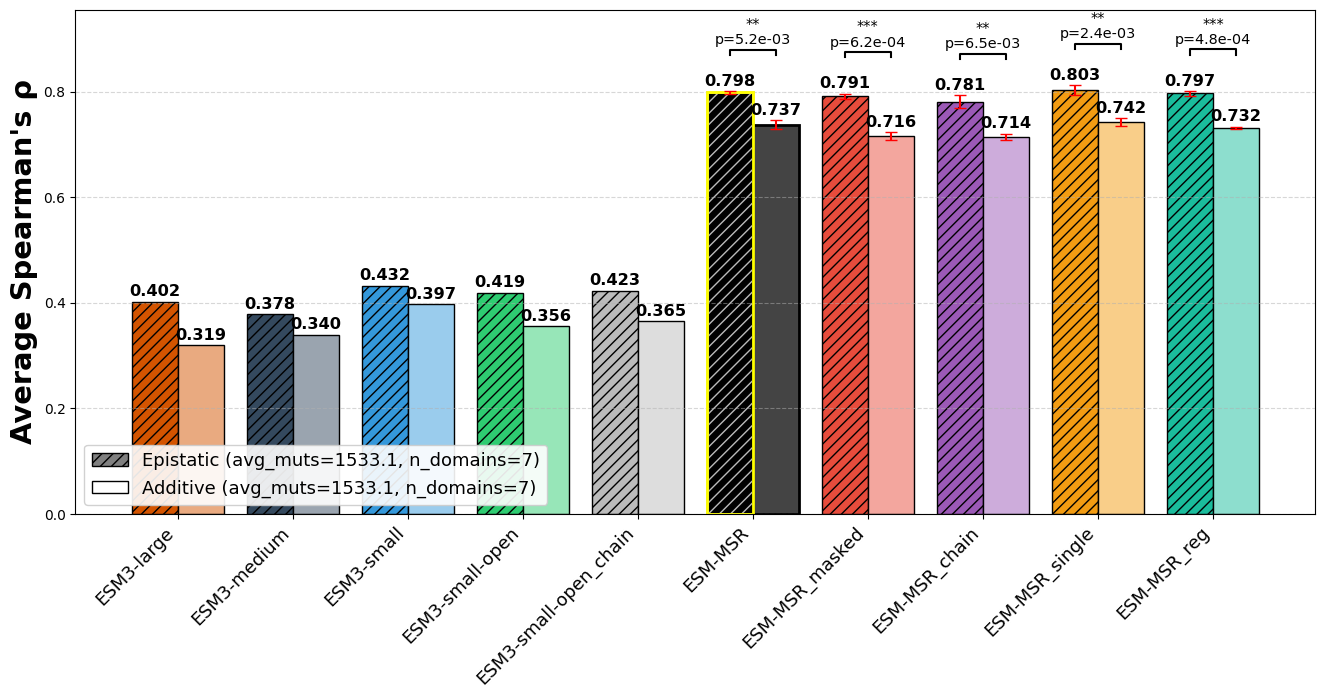

In [31]:
# For ~52,000 testing doubles, compare additive approximation to original (combined/epistatic) prediction (grouped by structure, then take mean)
import analysis_utils_msr
import importlib
importlib.reload(analysis_utils_msr)
analysis_utils_msr.create_metric_comparison_chart_epistatic(df_scores_epistatic.loc[('hyperopt_splits-D-test', 'grouped')], 
                                                            model_groups=['ESM3-large','ESM3-medium','ESM3-small','ESM3-small-open', 'ESM3-small-open_chain', 'ESM-MSR', 'ESM-MSR_masked', 'ESM-MSR_chain', 'ESM-MSR_single', 'ESM-MSR_reg'],
                                                            highlighted_model='ESM-MSR', title=None, y_label='Average Spearman\'s ρ', figsize=(16,8), bracket_height_factor=0.05, fontsize_multiplier=1.3, legend_loc='lower left') # 'ESM3-small-open_masked','ESM-MSR_masked', 'ESM-MSR_single', 'ESM-MSR_reg', 'ESM-MSR_hybrid',

(<Figure size 1600x800 with 1 Axes>, <Axes: ylabel="Pooled Spearman's ρ">)

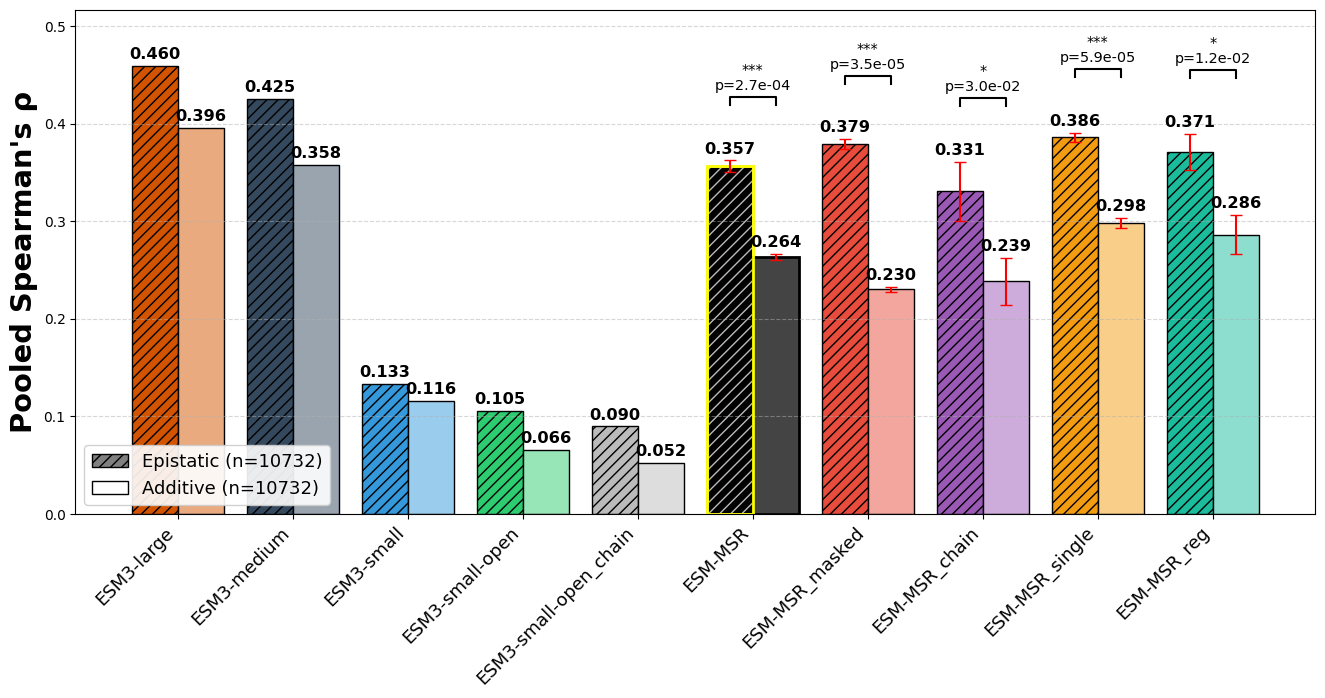

In [32]:
# For ~52,000 testing doubles, compare additive approximation to original (combined/epistatic) prediction (pool all predictions together)

analysis_utils_msr.create_metric_comparison_chart_epistatic(df_scores_epistatic.loc[('hyperopt_splits-D-test', 'ungrouped')], 
                                                            model_groups=['ESM3-large','ESM3-medium','ESM3-small','ESM3-small-open', 'ESM3-small-open_chain', 'ESM-MSR', 'ESM-MSR_masked', 'ESM-MSR_chain', 'ESM-MSR_single', 'ESM-MSR_reg'],
                                                            highlighted_model='ESM-MSR', title=None, y_label='Pooled Spearman\'s ρ', figsize=(16,8), is_grouped=False, legend_loc='lower left') #'Grouped Performance Comparison on Doubles from Feb19_Tsuboyama Test Set'

In [33]:
# repeat analysis for specifically only stabilizing or destabilizing mutations

df_pos = df.loc[df['ddG']>0]

df_scores_pos = pd.DataFrame(index=pd.MultiIndex.from_product([['hyperopt_splits-test'], ['ungrouped', 'grouped']]))
df_scores_pos_doubles = pd.DataFrame(index=pd.MultiIndex.from_product([['hyperopt_splits-D-test'], ['ungrouped', 'grouped']]))

df_scores_pos = assess_all_models(df_pos, df_scores_pos, assess_grouped_spearman, splits=['hyperopt_splits-test'])
df_scores_pos_doubles = assess_all_models(df_pos, df_scores_pos_doubles, assess_grouped_spearman, splits=['hyperopt_splits-D-test'])

df_neg = df.loc[df['ddG']<=0]

df_scores_neg = pd.DataFrame(index=pd.MultiIndex.from_product([['hyperopt_splits-test'], ['ungrouped', 'grouped']]))
df_scores_neg_doubles = pd.DataFrame(index=pd.MultiIndex.from_product([['hyperopt_splits-D-test'], ['ungrouped', 'grouped']]))

df_scores_neg = assess_all_models(df_neg, df_scores_neg, assess_grouped_spearman, splits=['hyperopt_splits-test'])
df_scores_neg_doubles = assess_all_models(df_neg, df_scores_neg_doubles, assess_grouped_spearman, splits=['hyperopt_splits-D-test'])

df_scores_combined = df_scores.join(df_scores_pos, rsuffix='_pos').join(df_scores_neg, rsuffix='_neg')
df_scores_combined

df_scores_combined_doubles = df_scores.join(df_scores_pos_doubles, rsuffix='_pos').join(df_scores_neg_doubles, rsuffix='_neg')
df_scores_combined_doubles

ESM-MSR_1
ESM-MSR_2
ESM-MSR_3
ESM-MSR_alpha_med_1
ESM-MSR_alpha_med_2
ESM-MSR_alpha_med_3
ESM-MSR_alpha_low_1
ESM-MSR_alpha_low_2
ESM-MSR_alpha_low_3
ESM-MSR_single_1
ESM-MSR_single_2
ESM-MSR_single_3
ESM-MSR_reg_1
ESM-MSR_reg_2
ESM-MSR_reg_3
ESM-MSR_masked_1
ESM-MSR_masked_2
ESM-MSR_masked_3
ESM-MSR_chain_1
ESM-MSR_chain_2
ESM-MSR_chain_3
SPURS_1
SPURS_2
SPURS_3
ThermoMPNN(-D)_1
ThermoMPNN(-D)_2
ThermoMPNN(-D)_3
MutateEverything_1
MutateEverything_2
MutateEverything_3
ESM3-small-open
ESM3-small-open_chain
ESM3-small
ESM3-medium
ESM3-large
Rosetta Cartesian DDG_1
Rosetta Cartesian DDG_2
Rosetta Cartesian DDG_3
ProteinMPNN
ESM-MSR_1
ESM-MSR_2
ESM-MSR_3
ESM-MSR_alpha_med_1
ESM-MSR_alpha_med_2
ESM-MSR_alpha_med_3
ESM-MSR_alpha_low_1
ESM-MSR_alpha_low_2
ESM-MSR_alpha_low_3
ESM-MSR_single_1
ESM-MSR_single_2
ESM-MSR_single_3
ESM-MSR_reg_1
ESM-MSR_reg_2
ESM-MSR_reg_3
ESM-MSR_masked_1
ESM-MSR_masked_2
ESM-MSR_masked_3
ESM-MSR_chain_1
ESM-MSR_chain_2
ESM-MSR_chain_3
SPURS_1
SPURS_2
SPURS_3
Ther

ESM-MSR_1   ESM-MSR_1_n  ESM-MSR_1_groups  \
hyperopt_splits-S-test ungrouped   0.765504  32968.000000               NaN   
                       grouped     0.813044    915.777778              36.0   
hyperopt_splits-D-test ungrouped   0.352032  10732.000000               NaN   
                       grouped     0.800176   1533.142857               7.0   
hyperopt_splits-test   ungrouped   0.717845  43700.000000               NaN   
                       grouped     0.803669   1213.888889              36.0   

                                  ESM-MSR_2   ESM-MSR_2_n  ESM-MSR_2_groups  \
hyperopt_splits-S-test ungrouped   0.778725  32968.000000               NaN   
                       grouped     0.817307    915.777778              36.0   
hyperopt_splits-D-test ungrouped   0.364904  10732.000000               NaN   
                       grouped     0.794892   1533.142857               7.0   
hyperopt_splits-test   ungrouped   0.726468  43700.000000               NaN   
                       grouped     0.808524   1213.888889              36.0   

                                  ESM-MSR_3   ESM-MSR_3_n  ESM-MSR_3_groups  \
hyperopt_splits-S-test ungrouped   0.777003  32968.000000               NaN   
                       grouped     0.816856    915.777778              36.0   
hyperopt_splits-D-test ungrouped   0.353008  10732.000000               NaN   
                       grouped     0.800261   1533.142857               7.0   
hyperopt_splits-test   ungrouped   0.736934  43700.000000               NaN   
                       grouped     0.807614   1213.888889              36.0   

                                  ESM-MSR_alpha_med_1  ...  \
hyperopt_splits-S-test ungrouped             0.758606  ...   
                       grouped               0.789040  ...   
hyperopt_splits-D-test ungrouped             0.344491  ...   
                       grouped               0.739334  ...   
hyperopt_splits-test   ungrouped             0.738772  ...   
                       grouped               0.780463  ...   

                                  Rosetta Cartesian DDG_1_groups_neg  \
hyperopt_splits-S-test ungrouped                                 NaN   
                       grouped                                   NaN   
hyperopt_splits-D-test ungrouped                                 NaN   
                       grouped                                   7.0   
hyperopt_splits-test   ungrouped                                 NaN   
                       grouped                                   NaN   

                                  Rosetta Cartesian DDG_2_neg  \
hyperopt_splits-S-test ungrouped                          NaN   
                       grouped                            NaN   
hyperopt_splits-D-test ungrouped                     0.448837   
                       grouped                       0.447347   
hyperopt_splits-test   ungrouped                          NaN   
                       grouped                            NaN   

                                  Rosetta Cartesian DDG_2_n_neg  \
hyperopt_splits-S-test ungrouped                            NaN   
                       grouped                              NaN   
hyperopt_splits-D-test ungrouped                   10375.000000   
                       grouped                      1482.142857   
hyperopt_splits-test   ungrouped                            NaN   
                       grouped                              NaN   

                                  Rosetta Cartesian DDG_2_groups_neg  \
hyperopt_splits-S-test ungrouped                                 NaN   
                       grouped                                   NaN   
hyperopt_splits-D-test ungrouped                                 NaN   
                       grouped                                   7.0   
hyperopt_splits-test   ungrouped                                 NaN   
                       grouped                                   NaN   

 

In [34]:
df_scores_combined[[c for c in df_scores_combined.columns if ('SPURS' in c and '_group' in c)]]

SPURS_1_groups  SPURS_2_groups  \
hyperopt_splits-S-test ungrouped             NaN             NaN   
                       grouped              36.0            36.0   
hyperopt_splits-D-test ungrouped             NaN             NaN   
                       grouped               7.0             7.0   
hyperopt_splits-test   ungrouped             NaN             NaN   
                       grouped              36.0            36.0   

                                  SPURS_3_groups  SPURS_1_groups_pos  \
hyperopt_splits-S-test ungrouped             NaN                 NaN   
                       grouped              36.0                 NaN   
hyperopt_splits-D-test ungrouped             NaN                 NaN   
                       grouped               7.0                 NaN   
hyperopt_splits-test   ungrouped             NaN                 NaN   
                       grouped              36.0                36.0   

                                  SPURS_2_groups_pos  SPURS_3_groups_pos  \
hyperopt_splits-S-test ungrouped                 NaN                 NaN   
                       grouped                   NaN                 NaN   
hyperopt_splits-D-test ungrouped                 NaN                 NaN   
                       grouped                   NaN                 NaN   
hyperopt_splits-test   ungrouped                 NaN                 NaN   
                       grouped                  36.0                36.0   

                                  SPURS_1_groups_neg  SPURS_2_groups_neg  \
hyperopt_splits-S-test ungrouped                 NaN                 NaN   
                       grouped                   NaN                 NaN   
hyperopt_splits-D-test ungrouped                 NaN                 NaN   
                       grouped                   NaN                 NaN   
hyperopt_splits-test   ungrouped                 NaN                 NaN   
                       grouped                  36.0                36.0   

                                  SPURS_3_groups_neg  
hyperopt_splits-S-test ungrouped                 NaN  
                       grouped                   NaN  
hyperopt_splits-D-test ungrouped                 NaN  
                       grouped                   NaN  
hyperopt_splits-test   ungrouped                 NaN  
                       grouped                  36.0

(<Figure size 1600x800 with 1 Axes>, <Axes: ylabel="Average Spearman's ρ">)

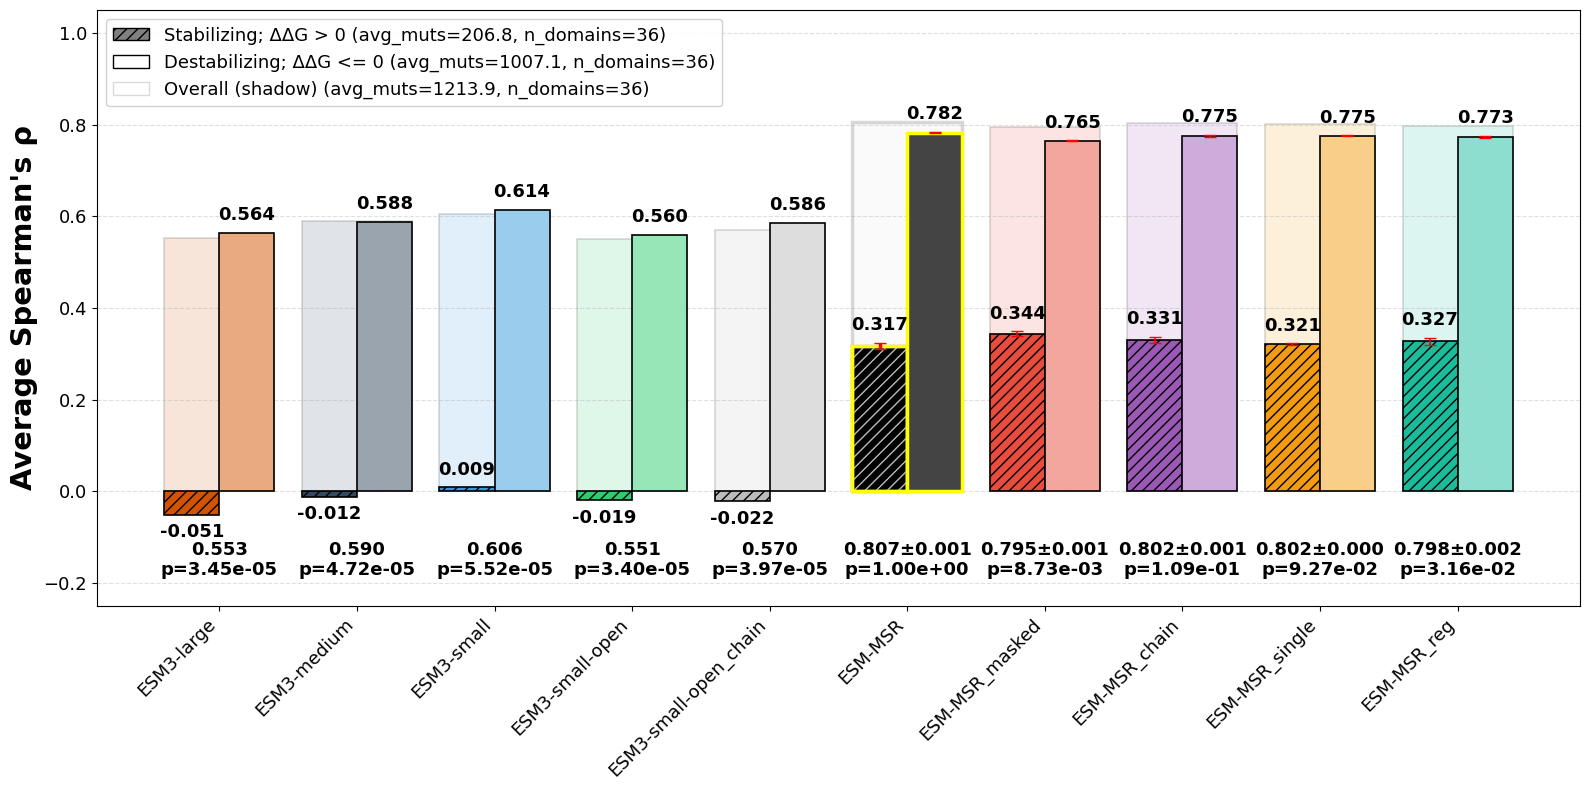

In [35]:
import analysis_utils_msr
import importlib
importlib.reload(analysis_utils_msr) 

analysis_utils_msr.create_pos_neg_overall_chart(
    df_scores_combined.loc[('hyperopt_splits-test', 'grouped')], 
    model_groups=['ESM3-large','ESM3-medium','ESM3-small','ESM3-small-open', 'ESM3-small-open_chain', 'ESM-MSR', 'ESM-MSR_masked', 'ESM-MSR_chain', 'ESM-MSR_single', 'ESM-MSR_reg'], p_value_y_coord=-0.15,
    title=None, y_label='Average Spearman\'s ρ', highlighted_model='ESM-MSR', enforce_global_n=True, epistasis=False, figsize=(16, 8), ylim=(-0.25, 1.05), legend_loc='upper left', fontsize_multiplier=1.3) #'ESM-MSR_direct',

(<Figure size 1600x800 with 1 Axes>, <Axes: ylabel="Pooled Spearman's ρ">)

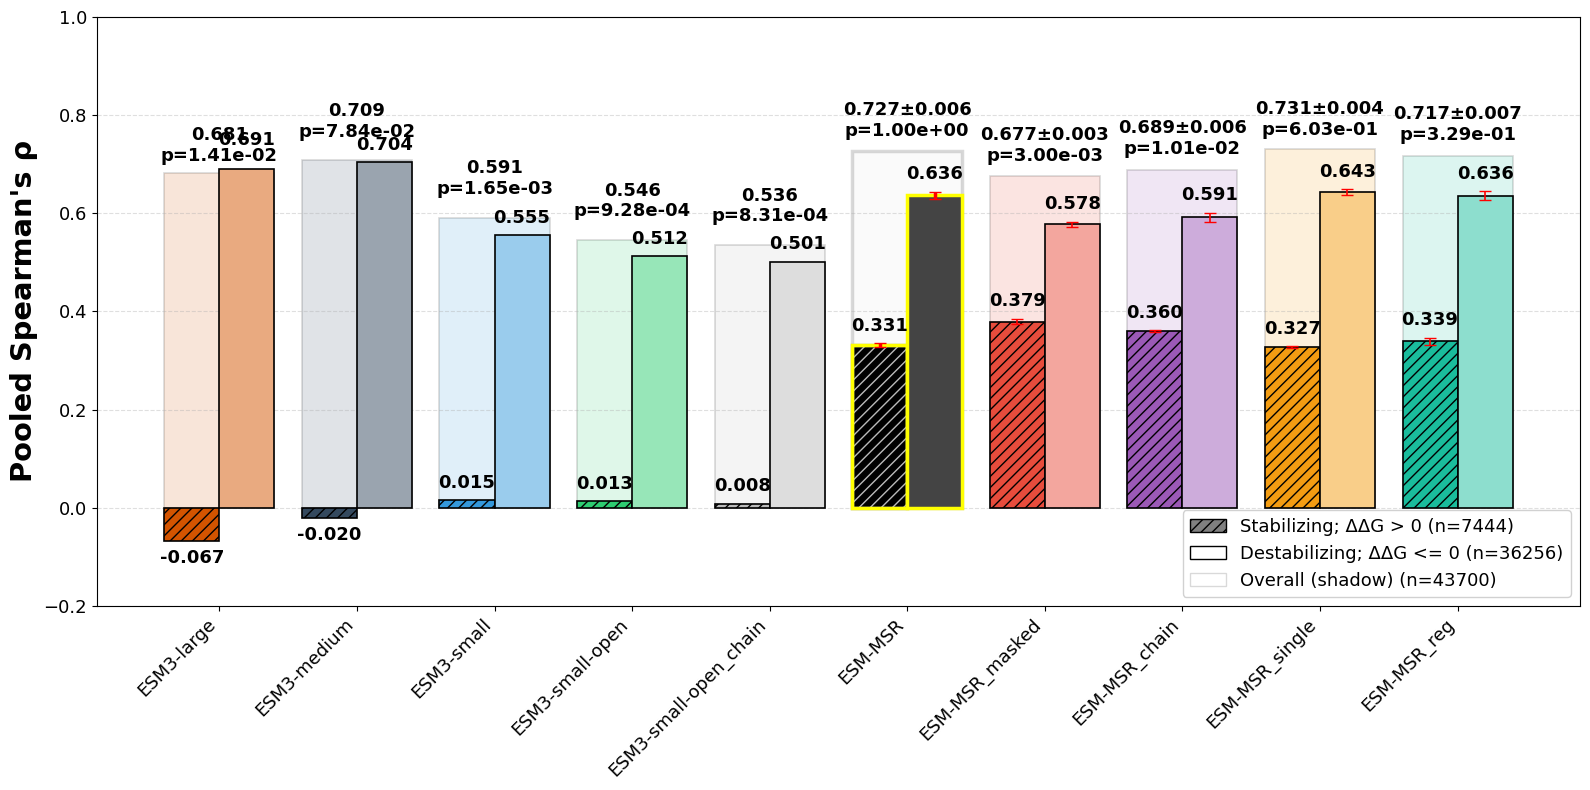

In [36]:
analysis_utils_msr.create_pos_neg_overall_chart(df_scores_combined.loc[('hyperopt_splits-test', 'ungrouped')], 
                                                model_groups=['ESM3-large','ESM3-medium','ESM3-small','ESM3-small-open', 'ESM3-small-open_chain', 'ESM-MSR', 'ESM-MSR_masked', 'ESM-MSR_chain', 'ESM-MSR_single', 'ESM-MSR_reg'], 
                                                title=None, y_label='Pooled Spearman\'s ρ', highlighted_model='ESM-MSR', enforce_global_n=False, epistasis=False, figsize=(16, 8), ylim=(-0.2, 1), is_grouped=False, fontsize_multiplier=1.3, legend_loc='lower right') #'ESM-MSR_direct', 

In [37]:
# repeat pos vs neg analysis, for doubles only now

df_pos = df.loc[df['ddG']>0] #.dropna()
df_scores_pos_doubles = pd.DataFrame(index=pd.MultiIndex.from_product([['hyperopt_splits-D-test'], ['ungrouped', 'grouped']]))

df_scores_pos_doubles = assess_all_models(df_pos.loc[df_pos['mut_type'].str.contains(':')], df_scores_pos_doubles, assess_grouped_spearman, splits=('hyperopt_splits-D-test', 'hyperopt_splits-test'))

df_neg = df.loc[df['ddG']<=0] #.dropna()
df_scores_neg_doubles = pd.DataFrame(index=pd.MultiIndex.from_product([['hyperopt_splits-D-test'], ['ungrouped', 'grouped']]))

df_scores_neg_doubles = assess_all_models(df_neg.loc[df_neg['mut_type'].str.contains(':')], df_scores_neg_doubles, assess_grouped_spearman, splits=('hyperopt_splits-D-test', 'hyperopt_splits-test'))

df_scores_combined_doubles = df_scores.join(df_scores_pos_doubles, rsuffix='_pos').join(df_scores_neg_doubles, rsuffix='_neg')
df_scores_combined_doubles

ESM-MSR_1
ESM-MSR_2
ESM-MSR_3
ESM-MSR_alpha_med_1
ESM-MSR_alpha_med_2
ESM-MSR_alpha_med_3
ESM-MSR_alpha_low_1
ESM-MSR_alpha_low_2
ESM-MSR_alpha_low_3
ESM-MSR_single_1
ESM-MSR_single_2
ESM-MSR_single_3
ESM-MSR_reg_1
ESM-MSR_reg_2
ESM-MSR_reg_3
ESM-MSR_masked_1
ESM-MSR_masked_2
ESM-MSR_masked_3
ESM-MSR_chain_1
ESM-MSR_chain_2
ESM-MSR_chain_3
SPURS_1
SPURS_2
SPURS_3
ThermoMPNN(-D)_1
ThermoMPNN(-D)_2
ThermoMPNN(-D)_3
MutateEverything_1
MutateEverything_2
MutateEverything_3
ESM3-small-open
ESM3-small-open_chain
ESM3-small
ESM3-medium
ESM3-large
Rosetta Cartesian DDG_1
Rosetta Cartesian DDG_2
Rosetta Cartesian DDG_3
ProteinMPNN
ESM-MSR_1
ESM-MSR_2
ESM-MSR_3
ESM-MSR_alpha_med_1
ESM-MSR_alpha_med_2
ESM-MSR_alpha_med_3
ESM-MSR_alpha_low_1
ESM-MSR_alpha_low_2
ESM-MSR_alpha_low_3
ESM-MSR_single_1
ESM-MSR_single_2
ESM-MSR_single_3
ESM-MSR_reg_1
ESM-MSR_reg_2
ESM-MSR_reg_3
ESM-MSR_masked_1
ESM-MSR_masked_2
ESM-MSR_masked_3
ESM-MSR_chain_1
ESM-MSR_chain_2
ESM-MSR_chain_3
SPURS_1
SPURS_2
SPURS_3
Ther

ESM-MSR_1   ESM-MSR_1_n  ESM-MSR_1_groups  \
hyperopt_splits-S-test ungrouped   0.765504  32968.000000               NaN   
                       grouped     0.813044    915.777778              36.0   
hyperopt_splits-D-test ungrouped   0.352032  10732.000000               NaN   
                       grouped     0.800176   1533.142857               7.0   
hyperopt_splits-test   ungrouped   0.717845  43700.000000               NaN   
                       grouped     0.803669   1213.888889              36.0   

                                  ESM-MSR_2   ESM-MSR_2_n  ESM-MSR_2_groups  \
hyperopt_splits-S-test ungrouped   0.778725  32968.000000               NaN   
                       grouped     0.817307    915.777778              36.0   
hyperopt_splits-D-test ungrouped   0.364904  10732.000000               NaN   
                       grouped     0.794892   1533.142857               7.0   
hyperopt_splits-test   ungrouped   0.726468  43700.000000               NaN   
                       grouped     0.808524   1213.888889              36.0   

                                  ESM-MSR_3   ESM-MSR_3_n  ESM-MSR_3_groups  \
hyperopt_splits-S-test ungrouped   0.777003  32968.000000               NaN   
                       grouped     0.816856    915.777778              36.0   
hyperopt_splits-D-test ungrouped   0.353008  10732.000000               NaN   
                       grouped     0.800261   1533.142857               7.0   
hyperopt_splits-test   ungrouped   0.736934  43700.000000               NaN   
                       grouped     0.807614   1213.888889              36.0   

                                  ESM-MSR_alpha_med_1  ...  \
hyperopt_splits-S-test ungrouped             0.758606  ...   
                       grouped               0.789040  ...   
hyperopt_splits-D-test ungrouped             0.344491  ...   
                       grouped               0.739334  ...   
hyperopt_splits-test   ungrouped             0.738772  ...   
                       grouped               0.780463  ...   

                                  Rosetta Cartesian DDG_1_groups_neg  \
hyperopt_splits-S-test ungrouped                                 NaN   
                       grouped                                   NaN   
hyperopt_splits-D-test ungrouped                                 NaN   
                       grouped                                   7.0   
hyperopt_splits-test   ungrouped                                 NaN   
                       grouped                                   7.0   

                                  Rosetta Cartesian DDG_2_neg  \
hyperopt_splits-S-test ungrouped                          NaN   
                       grouped                            NaN   
hyperopt_splits-D-test ungrouped                     0.448837   
                       grouped                       0.447347   
hyperopt_splits-test   ungrouped                     0.448837   
                       grouped                       0.447347   

                                  Rosetta Cartesian DDG_2_n_neg  \
hyperopt_splits-S-test ungrouped                            NaN   
                       grouped                              NaN   
hyperopt_splits-D-test ungrouped                   10375.000000   
                       grouped                      1482.142857   
hyperopt_splits-test   ungrouped                   10375.000000   
                       grouped                      1482.142857   

                                  Rosetta Cartesian DDG_2_groups_neg  \
hyperopt_splits-S-test ungrouped                                 NaN   
                       grouped                                   NaN   
hyperopt_splits-D-test ungrouped                                 NaN   
                       grouped                                   7.0   
hyperopt_splits-test   ungrouped                                 NaN   
                       grouped                                   7.0   

 

(<Figure size 1600x800 with 1 Axes>, <Axes: ylabel="Average Spearman's ρ">)

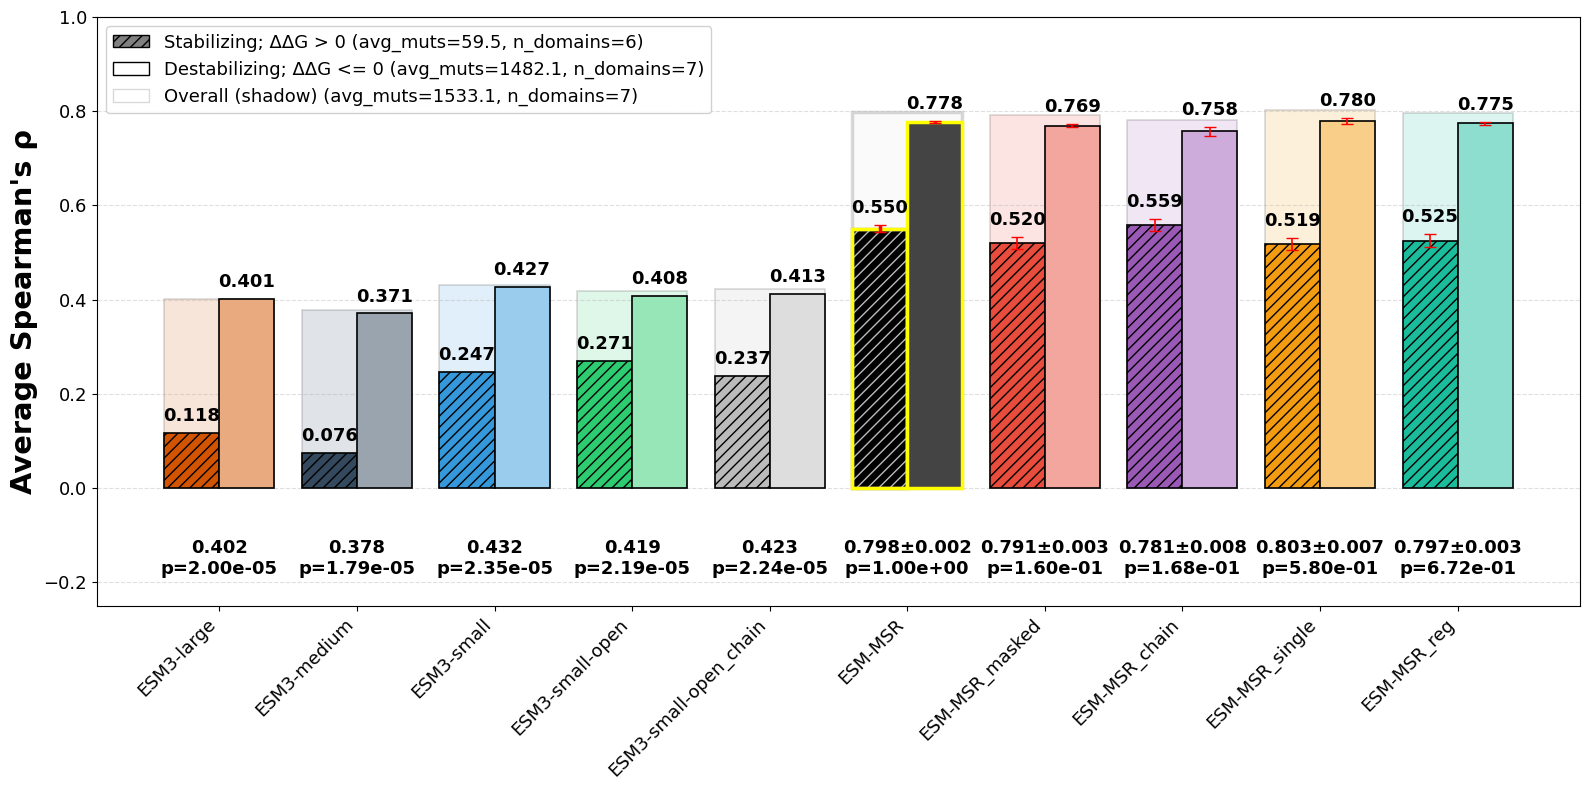

In [38]:
analysis_utils_msr.create_pos_neg_overall_chart(df_scores_combined_doubles.loc[('hyperopt_splits-D-test', 'grouped')], 
                                                model_groups=['ESM3-large','ESM3-medium','ESM3-small','ESM3-small-open', 'ESM3-small-open_chain', 'ESM-MSR', 'ESM-MSR_masked', 'ESM-MSR_chain', 'ESM-MSR_single', 'ESM-MSR_reg'], 
                                                title=None, y_label='Average Spearman\'s ρ', highlighted_model='ESM-MSR', enforce_global_n=False, epistasis=False, fontsize_multiplier=1.3, legend_loc='upper left', figsize=(16, 8), ylim=(-0.25, 1.), p_value_y_coord=-0.15)

(<Figure size 1600x800 with 1 Axes>, <Axes: ylabel="Pooled Spearman's ρ">)

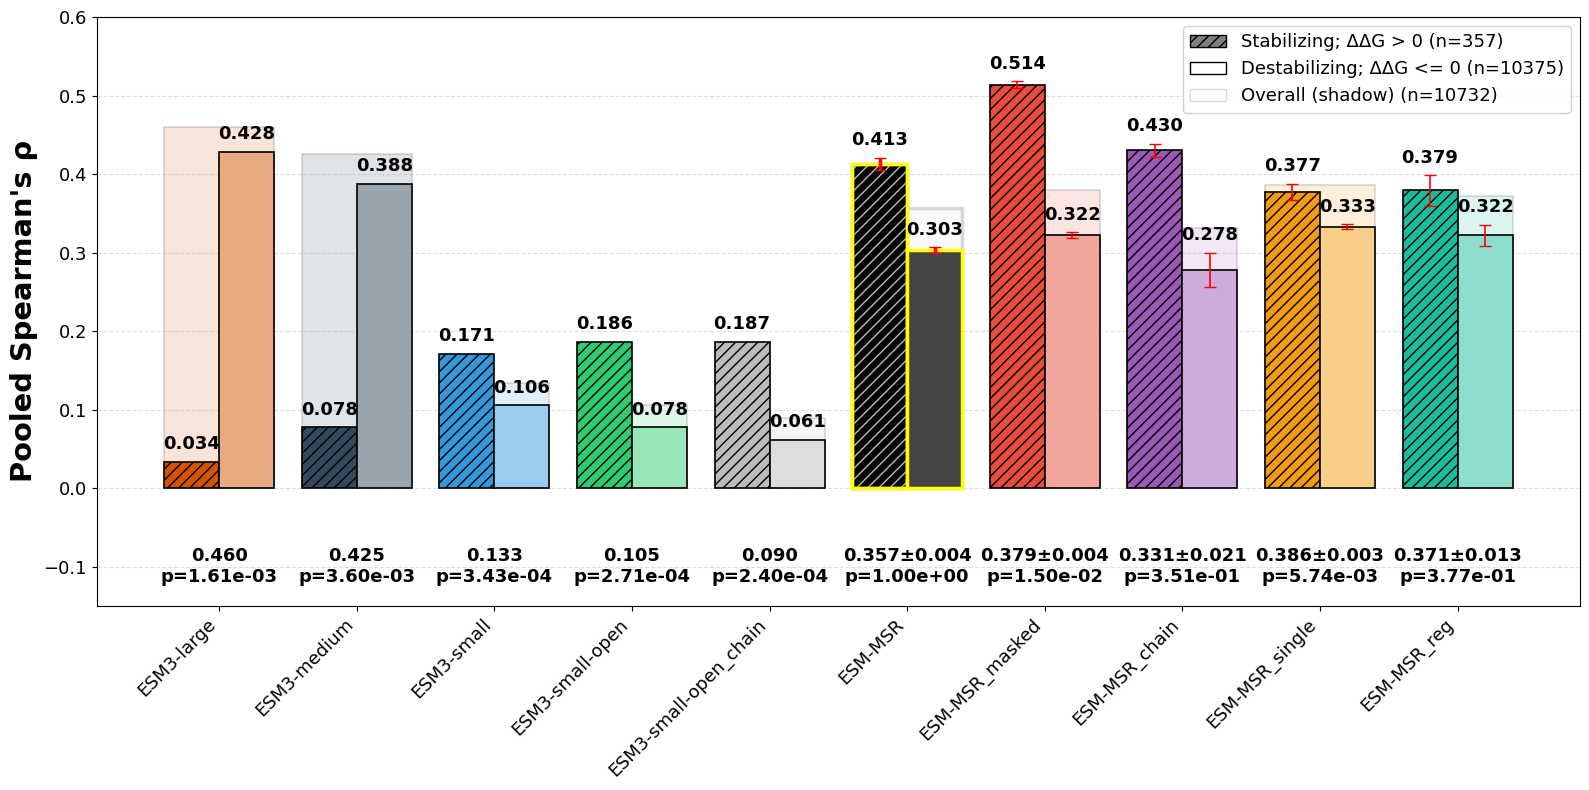

In [39]:
analysis_utils_msr.create_pos_neg_overall_chart(df_scores_combined_doubles.loc[('hyperopt_splits-D-test', 'ungrouped')], 
                                                model_groups=['ESM3-large','ESM3-medium','ESM3-small','ESM3-small-open', 'ESM3-small-open_chain', 'ESM-MSR', 'ESM-MSR_masked', 'ESM-MSR_chain', 'ESM-MSR_single', 'ESM-MSR_reg'], 
                                                title=None, y_label='Pooled Spearman\'s ρ', highlighted_model='ESM-MSR', enforce_global_n=False, epistasis=False, figsize=(16, 8), ylim=(-0.15,0.6), fontsize_multiplier=1.3, is_grouped=False, p_value_y_coord=-0.1)

In [40]:
import importlib
importlib.reload(analysis_utils_msr)
from analysis_utils_msr import compute_dddg

df_scores_dddG = pd.DataFrame(index=pd.MultiIndex.from_product([['hyperopt_splits-D-test'], ['ungrouped', 'grouped']]))
df_dddG = df_epistatic.copy(deep=True)
df_dddG = compute_dddg(df_dddG)
df_dddG

,ThermoMPNN_1,ThermoMPNN(-D)_1,ThermoMPNN_2,ThermoMPNN(-D)_2,ThermoMPNN_3,ThermoMPNN(-D)_3,ThermoMPNN(-D)_additive_1,ThermoMPNN(-D)_additive_2,ThermoMPNN(-D)_additive_3,ddG_ML_thermo,...,ESM-MSR_reg_2_dddG,ESM-MSR_reg_3_dddG,ESM-MSR_masked_1_dddG,ESM-MSR_masked_2_dddG,ESM-MSR_masked_3_dddG,ESM-MSR_chain_1_dddG,ESM-MSR_chain_2_dddG,ESM-MSR_chain_3_dddG,ESM3-small-open_chain_dddG,ddG_dddG
uid,,,,,,,,,,,,,,,,,,,,,
1UFM_A11C,0.182458,0.182458,0.229011,0.229011,0.112110,0.112110,0.182458,0.229011,0.112110,0.004061,...,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
1UFM_A11D,-0.534806,-0.534806,-0.776187,-0.776187,-0.690362,-0.690362,-0.534806,-0.776187,-0.690362,-0.023454,...,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
1UFM_A11E,-0.127483,-0.127483,-0.176427,-0.176427,-0.169683,-0.169683,-0.127483,-0.176427,-0.169683,0.111864,...,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
1UFM_A11F,-0.037749,-0.037749,-0.077629,-0.077629,-0.115784,-0.115784,-0.037749,-0.077629,-0.115784,-0.153650,...,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
1UFM_A11G,-0.565192,-0.565192,-0.628311,-0.628311,-0.642682,-0.642682,-0.565192,-0.628311,-0.642682,-0.393182,...,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HHH_rd1_0949_R10Y:E36S,-1.687004,-0.557682,-1.533284,-1.408043,-1.497178,-0.774565,-1.687004,-1.533284,-1.497178,NaN,...,0.673687,0.733862,1.271679,1.411662,1.494090,0.580722,0.736679,0.579608,1.863220,0.946647
HHH_rd1_0949_R10Y:E36T,-1.304661,-0.486829,-1.297930,-1.210776,-1.352677,-0.265816,-1.304661,-1.297930,-1.352677,NaN,...,0.601406,0.540778,1.214785,1.327240,1.431294,0.521472,0.652309,0.499841,1.553223,0.602194
HHH_rd1_0949_R10Y:E36V,-0.525491,-0.274588,-0.531802,-0.501731,-0.583954,0.229817,-0.525491,-0.531802,-0.583954,NaN,...,0.832717,0.708154,1.357612,1.584037,1.663669,0.840289,0.982540,0.881671,1.907593,0.544439


In [41]:
df_scores_dddG = pd.DataFrame(index=pd.MultiIndex.from_product([['hyperopt_splits-D-test'], ['ungrouped', 'grouped']]))

df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM-MSR_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_1_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM-MSR_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_2_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM-MSR_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_3_dddG', label='ddG_dddG')

df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM-MSR_alpha_med_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_med_1_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM-MSR_alpha_med_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_med_2_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM-MSR_alpha_med_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_med_3_dddG', label='ddG_dddG')

df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM-MSR_alpha_low_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_low_1_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM-MSR_alpha_low_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_low_2_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM-MSR_alpha_low_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_low_3_dddG', label='ddG_dddG')

df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM-MSR_single_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_single_1_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM-MSR_single_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_single_2_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM-MSR_single_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_single_3_dddG', label='ddG_dddG')

df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM-MSR_reg_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_reg_1_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM-MSR_reg_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_reg_2_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM-MSR_reg_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_reg_3_dddG', label='ddG_dddG')

#df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM-MSR_hybrid', 'hyperopt_splits-D-test', pred_col='ESM-MSR_hybrid_dddG', label='ddG_dddG')

df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM-MSR_chain_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_chain_1_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM-MSR_chain_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_chain_2_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM-MSR_chain_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_chain_3_dddG', label='ddG_dddG')

df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM-MSR_masked_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_masked_1_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM-MSR_masked_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_masked_2_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM-MSR_masked_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_masked_3_dddG', label='ddG_dddG')

df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'Negative_additive', 'hyperopt_splits-D-test', pred_col='ddG_additive', label='ddG_dddG')
df_scores_dddG['Negative_additive'] *= -1

df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'SPURS_1', 'hyperopt_splits-D-test', pred_col='SPURS_1_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'SPURS_2', 'hyperopt_splits-D-test', pred_col='SPURS_2_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'SPURS_3', 'hyperopt_splits-D-test', pred_col='SPURS_3_dddG', label='ddG_dddG')

df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ThermoMPNN(-D)_1', 'hyperopt_splits-D-test', pred_col='ThermoMPNN(-D)_1_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ThermoMPNN(-D)_2', 'hyperopt_splits-D-test', pred_col='ThermoMPNN(-D)_2_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ThermoMPNN(-D)_3', 'hyperopt_splits-D-test', pred_col='ThermoMPNN(-D)_3_dddG', label='ddG_dddG')

df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'MutateEverything_1', 'hyperopt_splits-D-test', pred_col='MutateEverything_1_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'MutateEverything_2', 'hyperopt_splits-D-test', pred_col='MutateEverything_2_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'MutateEverything_3', 'hyperopt_splits-D-test', pred_col='MutateEverything_3_dddG', label='ddG_dddG')

df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM3-small-open', 'hyperopt_splits-D-test', pred_col='ESM3-small-open_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM3-small-open_chain', 'hyperopt_splits-D-test', pred_col='ESM3-small-open_chain_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM3-small', 'hyperopt_splits-D-test', pred_col='ESM3-small_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM3-medium', 'hyperopt_splits-D-test', pred_col='ESM3-medium_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM3-large', 'hyperopt_splits-D-test', pred_col='ESM3-large_dddG', label='ddG_dddG')

df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'Rosetta Cartesian DDG_1', 'hyperopt_splits-D-test', pred_col='Rosetta Cartesian DDG_1_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'Rosetta Cartesian DDG_2', 'hyperopt_splits-D-test', pred_col='Rosetta Cartesian DDG_2_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'Rosetta Cartesian DDG_3', 'hyperopt_splits-D-test', pred_col='Rosetta Cartesian DDG_3_dddG', label='ddG_dddG')

df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ProteinMPNN', 'hyperopt_splits-D-test', pred_col='ProteinMPNN_dddG', label='ddG_dddG')

df_scores_dddG



df_dddG_pos = df_dddG.loc[df_dddG['ddG_dddG']>=0]
df_scores_dddG_pos = pd.DataFrame(index=pd.MultiIndex.from_product([['hyperopt_splits-D-test'], ['ungrouped', 'grouped']]))

df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM-MSR_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_1_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM-MSR_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_2_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM-MSR_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_3_dddG', label='ddG_dddG')

df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM-MSR_alpha_med_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_med_1_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM-MSR_alpha_med_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_med_2_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM-MSR_alpha_med_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_med_3_dddG', label='ddG_dddG')

df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM-MSR_alpha_low_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_low_1_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM-MSR_alpha_low_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_low_2_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM-MSR_alpha_low_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_low_3_dddG', label='ddG_dddG')

df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM-MSR_single_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_single_1_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM-MSR_single_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_single_2_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM-MSR_single_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_single_3_dddG', label='ddG_dddG')

df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM-MSR_reg_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_reg_1_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM-MSR_reg_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_reg_2_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM-MSR_reg_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_reg_3_dddG', label='ddG_dddG')

#df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM-MSR_hybrid', 'hyperopt_splits-D-test', pred_col='ESM-MSR_hybrid_dddG', label='ddG_dddG')

df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM-MSR_chain_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_chain_1_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM-MSR_chain_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_chain_2_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM-MSR_chain_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_chain_3_dddG', label='ddG_dddG')

df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM-MSR_masked_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_masked_1_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM-MSR_masked_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_masked_2_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM-MSR_masked_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_masked_3_dddG', label='ddG_dddG')

df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'Negative_additive', 'hyperopt_splits-D-test', pred_col='ddG_additive', label='ddG_dddG')
df_scores_dddG_pos['Negative_additive'] *= -1

df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'SPURS_1', 'hyperopt_splits-D-test', pred_col='SPURS_1_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'SPURS_2', 'hyperopt_splits-D-test', pred_col='SPURS_2_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'SPURS_3', 'hyperopt_splits-D-test', pred_col='SPURS_3_dddG', label='ddG_dddG')

df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ThermoMPNN(-D)_1', 'hyperopt_splits-D-test', pred_col='ThermoMPNN(-D)_1_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ThermoMPNN(-D)_2', 'hyperopt_splits-D-test', pred_col='ThermoMPNN(-D)_2_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ThermoMPNN(-D)_3', 'hyperopt_splits-D-test', pred_col='ThermoMPNN(-D)_3_dddG', label='ddG_dddG')

df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'MutateEverything_1', 'hyperopt_splits-D-test', pred_col='MutateEverything_1_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'MutateEverything_2', 'hyperopt_splits-D-test', pred_col='MutateEverything_2_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'MutateEverything_3', 'hyperopt_splits-D-test', pred_col='MutateEverything_3_dddG', label='ddG_dddG')

df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM3-small-open', 'hyperopt_splits-D-test', pred_col='ESM3-small-open_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM3-small-open_chain', 'hyperopt_splits-D-test', pred_col='ESM3-small-open_chain_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM3-small', 'hyperopt_splits-D-test', pred_col='ESM3-small_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM3-medium', 'hyperopt_splits-D-test', pred_col='ESM3-medium_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM3-large', 'hyperopt_splits-D-test', pred_col='ESM3-large_dddG', label='ddG_dddG')

df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'Rosetta Cartesian DDG_1', 'hyperopt_splits-D-test', pred_col='Rosetta Cartesian DDG_1_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'Rosetta Cartesian DDG_2', 'hyperopt_splits-D-test', pred_col='Rosetta Cartesian DDG_2_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'Rosetta Cartesian DDG_3', 'hyperopt_splits-D-test', pred_col='Rosetta Cartesian DDG_3_dddG', label='ddG_dddG')

df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ProteinMPNN', 'hyperopt_splits-D-test', pred_col='ProteinMPNN_dddG', label='ddG_dddG')



df_dddG_neg = df_dddG.loc[df_dddG['ddG_dddG']<0]
df_scores_dddG_neg = pd.DataFrame(index=pd.MultiIndex.from_product([['hyperopt_splits-D-test'], ['ungrouped', 'grouped']]))

df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM-MSR_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_1_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM-MSR_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_2_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM-MSR_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_3_dddG', label='ddG_dddG')

df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM-MSR_alpha_med_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_med_1_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM-MSR_alpha_med_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_med_2_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM-MSR_alpha_med_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_med_3_dddG', label='ddG_dddG')

df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM-MSR_alpha_low_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_low_1_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM-MSR_alpha_low_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_low_2_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM-MSR_alpha_low_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_low_3_dddG', label='ddG_dddG')

df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM-MSR_single_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_single_1_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM-MSR_single_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_single_2_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM-MSR_single_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_single_3_dddG', label='ddG_dddG')

df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM-MSR_reg_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_reg_1_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM-MSR_reg_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_reg_2_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM-MSR_reg_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_reg_3_dddG', label='ddG_dddG')

#df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM-MSR_hybrid', 'hyperopt_splits-D-test', pred_col='ESM-MSR_hybrid_dddG', label='ddG_dddG')

df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM-MSR_chain_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_chain_1_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM-MSR_chain_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_chain_2_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM-MSR_chain_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_chain_3_dddG', label='ddG_dddG')

df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM-MSR_masked_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_masked_1_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM-MSR_masked_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_masked_2_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM-MSR_masked_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_masked_3_dddG', label='ddG_dddG')

df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'Negative_additive', 'hyperopt_splits-D-test', pred_col='ddG_additive', label='ddG_dddG')
df_scores_dddG_neg['Negative_additive'] *= -1

df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'SPURS_1', 'hyperopt_splits-D-test', pred_col='SPURS_1_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'SPURS_2', 'hyperopt_splits-D-test', pred_col='SPURS_2_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'SPURS_3', 'hyperopt_splits-D-test', pred_col='SPURS_3_dddG', label='ddG_dddG')

df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ThermoMPNN(-D)_1', 'hyperopt_splits-D-test', pred_col='ThermoMPNN(-D)_1_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ThermoMPNN(-D)_2', 'hyperopt_splits-D-test', pred_col='ThermoMPNN(-D)_2_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ThermoMPNN(-D)_3', 'hyperopt_splits-D-test', pred_col='ThermoMPNN(-D)_3_dddG', label='ddG_dddG')

df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'MutateEverything_1', 'hyperopt_splits-D-test', pred_col='MutateEverything_1_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'MutateEverything_2', 'hyperopt_splits-D-test', pred_col='MutateEverything_2_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'MutateEverything_3', 'hyperopt_splits-D-test', pred_col='MutateEverything_3_dddG', label='ddG_dddG')

df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM3-small-open', 'hyperopt_splits-D-test', pred_col='ESM3-small-open_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM3-small-open_chain', 'hyperopt_splits-D-test', pred_col='ESM3-small-open_chain_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM3-small', 'hyperopt_splits-D-test', pred_col='ESM3-small_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM3-medium', 'hyperopt_splits-D-test', pred_col='ESM3-medium_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM3-large', 'hyperopt_splits-D-test', pred_col='ESM3-large_dddG', label='ddG_dddG')

df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'Rosetta Cartesian DDG_1', 'hyperopt_splits-D-test', pred_col='Rosetta Cartesian DDG_1_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'Rosetta Cartesian DDG_2', 'hyperopt_splits-D-test', pred_col='Rosetta Cartesian DDG_2_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'Rosetta Cartesian DDG_3', 'hyperopt_splits-D-test', pred_col='Rosetta Cartesian DDG_3_dddG', label='ddG_dddG')

df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ProteinMPNN', 'hyperopt_splits-D-test', pred_col='ProteinMPNN_dddG', label='ddG_dddG')

df_scores_dddG_combined = df_scores_dddG.join(df_scores_dddG_pos, rsuffix='_pos').join(df_scores_dddG_neg, rsuffix='_neg')

df_scores_dddG_combined[[c for c in df_scores_dddG_combined.columns if 'ESM-MSR' in c]].columns



Index(['ESM-MSR_1', 'ESM-MSR_1_n', 'ESM-MSR_1_groups', 'ESM-MSR_2',
       'ESM-MSR_2_n', 'ESM-MSR_2_groups', 'ESM-MSR_3', 'ESM-MSR_3_n',
       'ESM-MSR_3_groups', 'ESM-MSR_alpha_med_1',
       ...
       'ESM-MSR_chain_3_groups_neg', 'ESM-MSR_masked_1_neg',
       'ESM-MSR_masked_1_n_neg', 'ESM-MSR_masked_1_groups_neg',
       'ESM-MSR_masked_2_neg', 'ESM-MSR_masked_2_n_neg',
       'ESM-MSR_masked_2_groups_neg', 'ESM-MSR_masked_3_neg',
       'ESM-MSR_masked_3_n_neg', 'ESM-MSR_masked_3_groups_neg'],
      dtype='object', length=189)

(<Figure size 1600x800 with 1 Axes>, <Axes: ylabel="Average Spearman's ρ">)

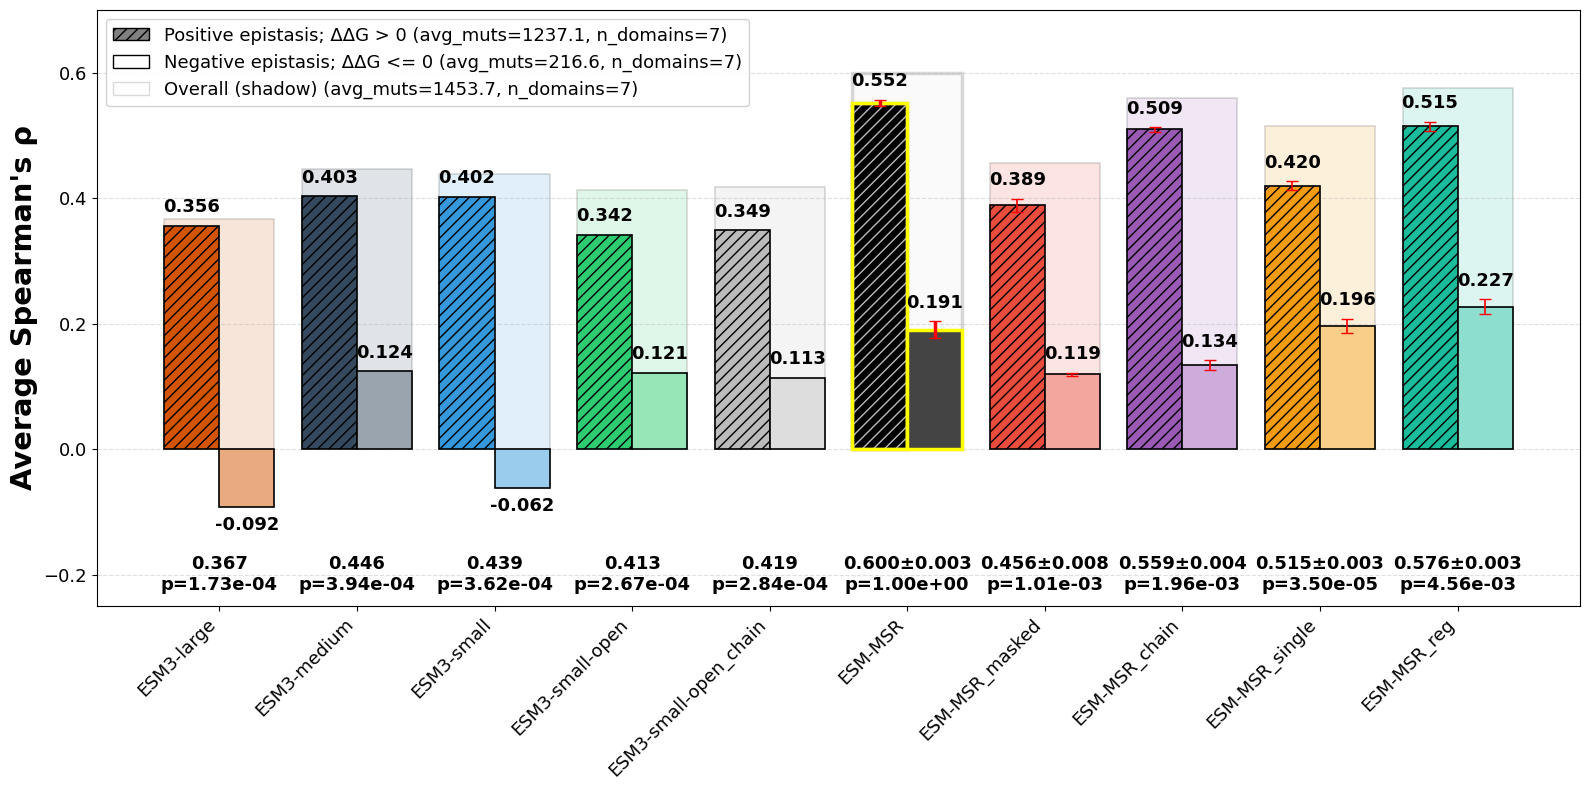

In [42]:
import importlib
importlib.reload(analysis_utils_msr)
analysis_utils_msr.create_pos_neg_overall_chart(df_scores_dddG_combined.loc[('hyperopt_splits-D-test', 'grouped')], 
                                                model_groups=['ESM3-large','ESM3-medium','ESM3-small','ESM3-small-open', 'ESM3-small-open_chain', 'ESM-MSR', 'ESM-MSR_masked', 'ESM-MSR_chain', 'ESM-MSR_single', 'ESM-MSR_reg'], 
                                                title=None, y_label='Average Spearman\'s ρ', highlighted_model='ESM-MSR', enforce_global_n=False, figsize=(16,8), ylim=(-0.25, 0.7), legend_loc='upper left',  p_value_y_coord=-0.2, fontsize_multiplier=1.3)


(<Figure size 1600x800 with 1 Axes>, <Axes: ylabel="Pooled Spearman's ρ">)

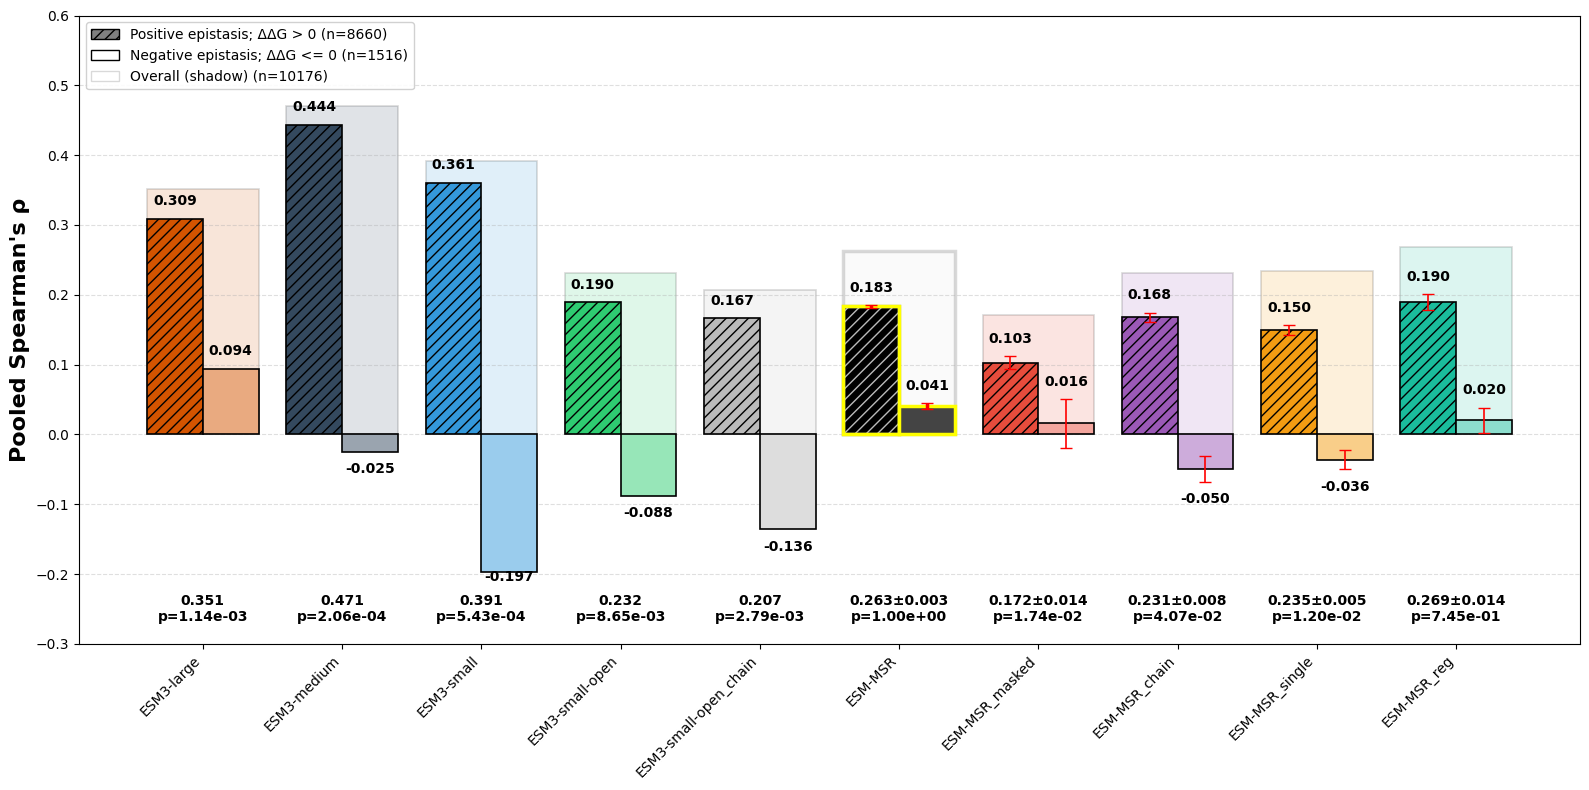

In [43]:
analysis_utils_msr.create_pos_neg_overall_chart(df_scores_dddG_combined.loc[('hyperopt_splits-D-test', 'ungrouped')], 
                                                model_groups=['ESM3-large','ESM3-medium','ESM3-small','ESM3-small-open', 'ESM3-small-open_chain', 'ESM-MSR', 'ESM-MSR_masked', 'ESM-MSR_chain', 'ESM-MSR_single', 'ESM-MSR_reg'], 
                                                title=None, y_label='Pooled Spearman\'s ρ', highlighted_model='ESM-MSR', enforce_global_n=False, figsize=(16,8), ylim=(-0.3, 0.6), p_value_y_coord=-0.25, legend_loc='upper left', fontsize_multiplier=1., is_grouped=False)


In [44]:
import importlib
importlib.reload(analysis_utils_msr)
from analysis_utils_msr import assess_classification_metric

df_scores_dddG_cls = pd.DataFrame(index=pd.MultiIndex.from_product([['hyperopt_splits-D-test'], ['ungrouped']]))
assess_mcc = partial(assess_classification_metric, metric_name='mcc', flip_labels=True)

df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_1_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_2_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_3_dddG', label='ddG_dddG')

df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_alpha_med_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_med_1_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_alpha_med_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_med_2_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_alpha_med_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_med_3_dddG', label='ddG_dddG')

df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_alpha_low_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_low_1_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_alpha_low_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_low_2_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_alpha_low_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_low_3_dddG', label='ddG_dddG')

df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_single_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_single_1_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_single_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_single_2_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_single_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_single_3_dddG', label='ddG_dddG')

df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_reg_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_reg_1_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_reg_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_reg_2_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_reg_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_reg_3_dddG', label='ddG_dddG')

#df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_hybrid', 'hyperopt_splits-D-test', pred_col='ESM-MSR_hybrid_dddG', label='ddG_dddG')

df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_chain_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_chain_1_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_chain_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_chain_2_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_chain_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_chain_3_dddG', label='ddG_dddG')

df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_masked_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_masked_1_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_masked_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_masked_2_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_masked_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_masked_3_dddG', label='ddG_dddG')

#df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'Negative_additive', 'hyperopt_splits-D-test', pred_col='ddG_additive', label='ddG_dddG')
#df_scores_dddG_cls['Negative_additive'] *= -1

df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'SPURS_1', 'hyperopt_splits-D-test', pred_col='SPURS_1_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'SPURS_2', 'hyperopt_splits-D-test', pred_col='SPURS_2_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'SPURS_3', 'hyperopt_splits-D-test', pred_col='SPURS_3_dddG', label='ddG_dddG')

df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ThermoMPNN(-D)_1', 'hyperopt_splits-D-test', pred_col='ThermoMPNN(-D)_1_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ThermoMPNN(-D)_2', 'hyperopt_splits-D-test', pred_col='ThermoMPNN(-D)_2_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ThermoMPNN(-D)_3', 'hyperopt_splits-D-test', pred_col='ThermoMPNN(-D)_3_dddG', label='ddG_dddG')

df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'MutateEverything_1', 'hyperopt_splits-D-test', pred_col='MutateEverything_1_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'MutateEverything_2', 'hyperopt_splits-D-test', pred_col='MutateEverything_2_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'MutateEverything_3', 'hyperopt_splits-D-test', pred_col='MutateEverything_3_dddG', label='ddG_dddG')

df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM3-small-open', 'hyperopt_splits-D-test', pred_col='ESM3-small-open_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM3-small-open_chain', 'hyperopt_splits-D-test', pred_col='ESM3-small-open_chain_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM3-small', 'hyperopt_splits-D-test', pred_col='ESM3-small_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM3-medium', 'hyperopt_splits-D-test', pred_col='ESM3-medium_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM3-large', 'hyperopt_splits-D-test', pred_col='ESM3-large_dddG', label='ddG_dddG')

df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')].fillna(0), df_scores_dddG_cls, 'Rosetta Cartesian DDG_1', 'hyperopt_splits-D-test', pred_col='Rosetta Cartesian DDG_1_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')].fillna(0), df_scores_dddG_cls, 'Rosetta Cartesian DDG_2', 'hyperopt_splits-D-test', pred_col='Rosetta Cartesian DDG_2_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')].fillna(0), df_scores_dddG_cls, 'Rosetta Cartesian DDG_3', 'hyperopt_splits-D-test', pred_col='Rosetta Cartesian DDG_3_dddG', label='ddG_dddG')

df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ProteinMPNN', 'hyperopt_splits-D-test', pred_col='ProteinMPNN_dddG', label='ddG_dddG')

df_scores_dddG_cls


,,ESM-MSR_1,ESM-MSR_1_n,ESM-MSR_2,ESM-MSR_2_n,ESM-MSR_3,ESM-MSR_3_n,ESM-MSR_alpha_med_1,ESM-MSR_alpha_med_1_n,ESM-MSR_alpha_med_2,ESM-MSR_alpha_med_2_n,...,ESM3-large,ESM3-large_n,Rosetta Cartesian DDG_1,Rosetta Cartesian DDG_1_n,Rosetta Cartesian DDG_2,Rosetta Cartesian DDG_2_n,Rosetta Cartesian DDG_3,Rosetta Cartesian DDG_3_n,ProteinMPNN,ProteinMPNN_n
hyperopt_splits-D-test,ungrouped,0.159002,10732.0,0.127042,10732.0,0.097352,10732.0,0.101706,10732.0,0.088851,10732.0,...,0.005746,10732.0,0.114577,10732.0,0.108779,10732.0,0.104497,10732.0,0.081598,10732.0


(<Figure size 1600x800 with 1 Axes>, <Axes: ylabel='MCC'>)

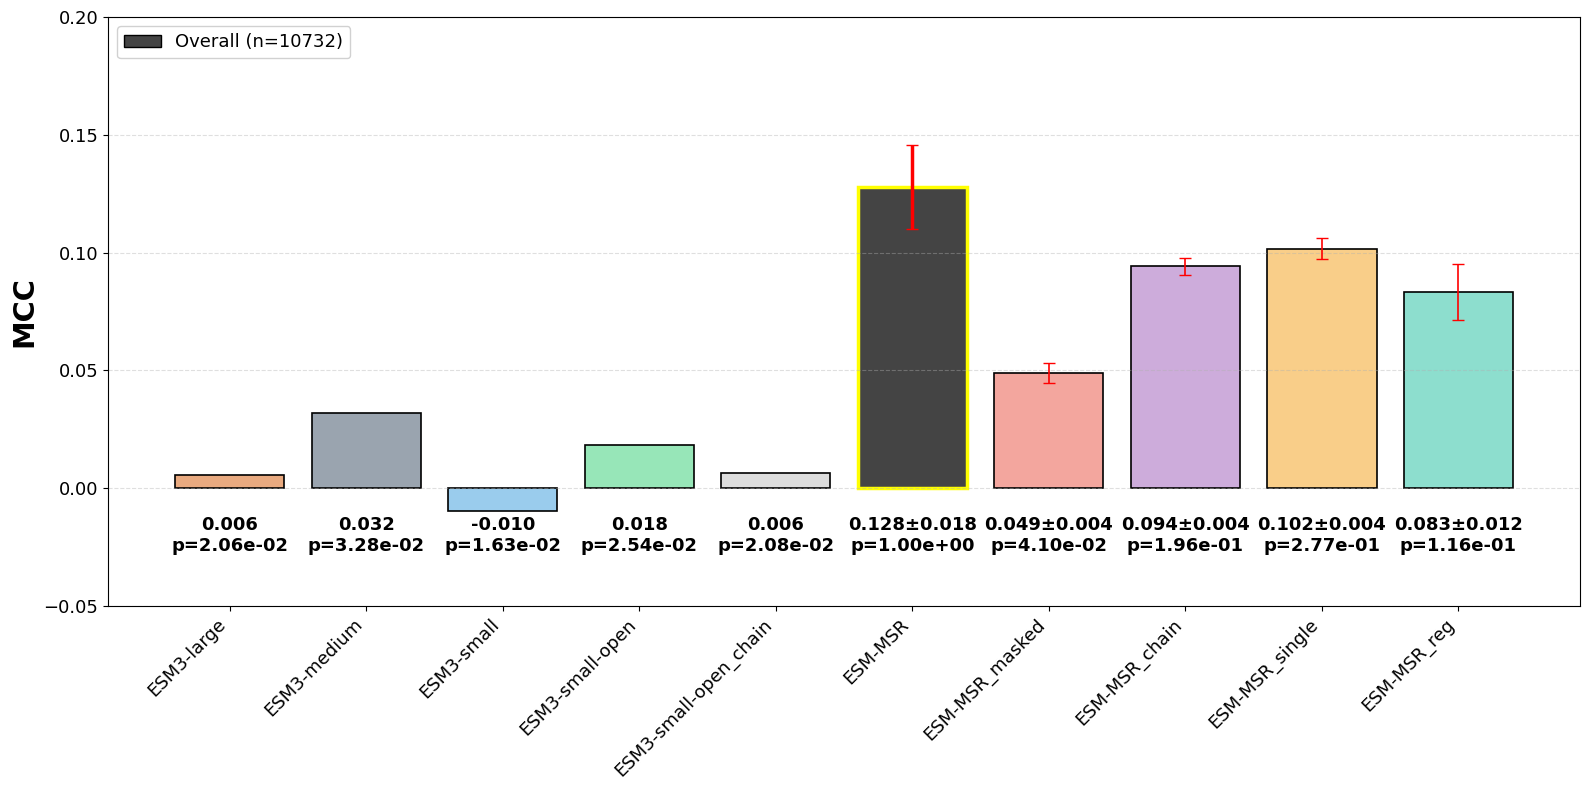

In [45]:
import importlib
importlib.reload(analysis_utils_msr)
analysis_utils_msr.create_triple_metric_chart_with_pvals(series_bar1=None,
                                      series_bar2=None, 
                                      series_overall=df_scores_dddG_cls.loc[('hyperopt_splits-D-test', 'ungrouped')], 
                                      model_groups=['ESM3-large','ESM3-medium','ESM3-small','ESM3-small-open', 'ESM3-small-open_chain', 'ESM-MSR', 'ESM-MSR_masked', 'ESM-MSR_chain', 'ESM-MSR_single', 'ESM-MSR_reg'], 
                                      title=None, y_label='MCC', highlighted_model='ESM-MSR', enforce_global_n=False, ylim=(-0.05,0.2), figsize=(16,8), p_value_y_coord=-0.02, label_min_sep=0.02, fontsize_multiplier=1.3, legend_loc='upper left', is_grouped=False, highlight_gray='#444444')

In [46]:
import importlib
importlib.reload(analysis_utils_msr)
from analysis_utils_msr import assess_classification_metric

df_scores_dddG_cls = pd.DataFrame(index=pd.MultiIndex.from_product([['hyperopt_splits-D-test'], ['ungrouped']]))
assess_auprc = partial(assess_classification_metric, metric_name='auprc', flip_labels=True)

df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_1_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_2_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_3_dddG', label='ddG_dddG')

df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_alpha_med_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_med_1_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_alpha_med_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_med_2_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_alpha_med_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_med_3_dddG', label='ddG_dddG')

df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_alpha_low_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_low_1_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_alpha_low_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_low_2_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_alpha_low_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_low_3_dddG', label='ddG_dddG')

df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_single_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_single_1_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_single_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_single_2_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_single_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_single_3_dddG', label='ddG_dddG')

df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_reg_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_reg_1_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_reg_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_reg_2_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_reg_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_reg_3_dddG', label='ddG_dddG')

#df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_hybrid', 'hyperopt_splits-D-test', pred_col='ESM-MSR_hybrid_dddG', label='ddG_dddG')

df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_chain_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_chain_1_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_chain_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_chain_2_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_chain_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_chain_3_dddG', label='ddG_dddG')

df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_masked_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_masked_1_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_masked_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_masked_2_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_masked_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_masked_3_dddG', label='ddG_dddG')

#df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'Negative_additive', 'hyperopt_splits-D-test', pred_col='ddG_additive', label='ddG_dddG')
#df_scores_dddG_cls['Negative_additive'] *= -1

df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'SPURS_1', 'hyperopt_splits-D-test', pred_col='SPURS_1_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'SPURS_2', 'hyperopt_splits-D-test', pred_col='SPURS_2_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'SPURS_3', 'hyperopt_splits-D-test', pred_col='SPURS_3_dddG', label='ddG_dddG')

df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ThermoMPNN(-D)_1', 'hyperopt_splits-D-test', pred_col='ThermoMPNN(-D)_1_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ThermoMPNN(-D)_2', 'hyperopt_splits-D-test', pred_col='ThermoMPNN(-D)_2_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ThermoMPNN(-D)_3', 'hyperopt_splits-D-test', pred_col='ThermoMPNN(-D)_3_dddG', label='ddG_dddG')

df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'MutateEverything_1', 'hyperopt_splits-D-test', pred_col='MutateEverything_1_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'MutateEverything_2', 'hyperopt_splits-D-test', pred_col='MutateEverything_2_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'MutateEverything_3', 'hyperopt_splits-D-test', pred_col='MutateEverything_3_dddG', label='ddG_dddG')

df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM3-small-open', 'hyperopt_splits-D-test', pred_col='ESM3-small-open_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM3-small-open_chain', 'hyperopt_splits-D-test', pred_col='ESM3-small-open_chain_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM3-small', 'hyperopt_splits-D-test', pred_col='ESM3-small_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM3-medium', 'hyperopt_splits-D-test', pred_col='ESM3-medium_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM3-large', 'hyperopt_splits-D-test', pred_col='ESM3-large_dddG', label='ddG_dddG')

df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')].fillna(0), df_scores_dddG_cls, 'Rosetta Cartesian DDG_1', 'hyperopt_splits-D-test', pred_col='Rosetta Cartesian DDG_1_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')].fillna(0), df_scores_dddG_cls, 'Rosetta Cartesian DDG_2', 'hyperopt_splits-D-test', pred_col='Rosetta Cartesian DDG_2_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')].fillna(0), df_scores_dddG_cls, 'Rosetta Cartesian DDG_3', 'hyperopt_splits-D-test', pred_col='Rosetta Cartesian DDG_3_dddG', label='ddG_dddG')

df_scores_dddG_cls = assess_auprc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ProteinMPNN', 'hyperopt_splits-D-test', pred_col='ProteinMPNN_dddG', label='ddG_dddG')

df_scores_dddG_cls


,,ESM-MSR_1,ESM-MSR_1_n,ESM-MSR_2,ESM-MSR_2_n,ESM-MSR_3,ESM-MSR_3_n,ESM-MSR_alpha_med_1,ESM-MSR_alpha_med_1_n,ESM-MSR_alpha_med_2,ESM-MSR_alpha_med_2_n,...,ESM3-large,ESM3-large_n,Rosetta Cartesian DDG_1,Rosetta Cartesian DDG_1_n,Rosetta Cartesian DDG_2,Rosetta Cartesian DDG_2_n,Rosetta Cartesian DDG_3,Rosetta Cartesian DDG_3_n,ProteinMPNN,ProteinMPNN_n
hyperopt_splits-D-test,ungrouped,0.263979,10732.0,0.258579,10732.0,0.262551,10732.0,0.25502,10732.0,0.246209,10732.0,...,0.227479,10732.0,0.193338,10732.0,0.192147,10732.0,0.195989,10732.0,0.237004,10732.0


(<Figure size 1600x800 with 1 Axes>, <Axes: ylabel='AUPRC'>)

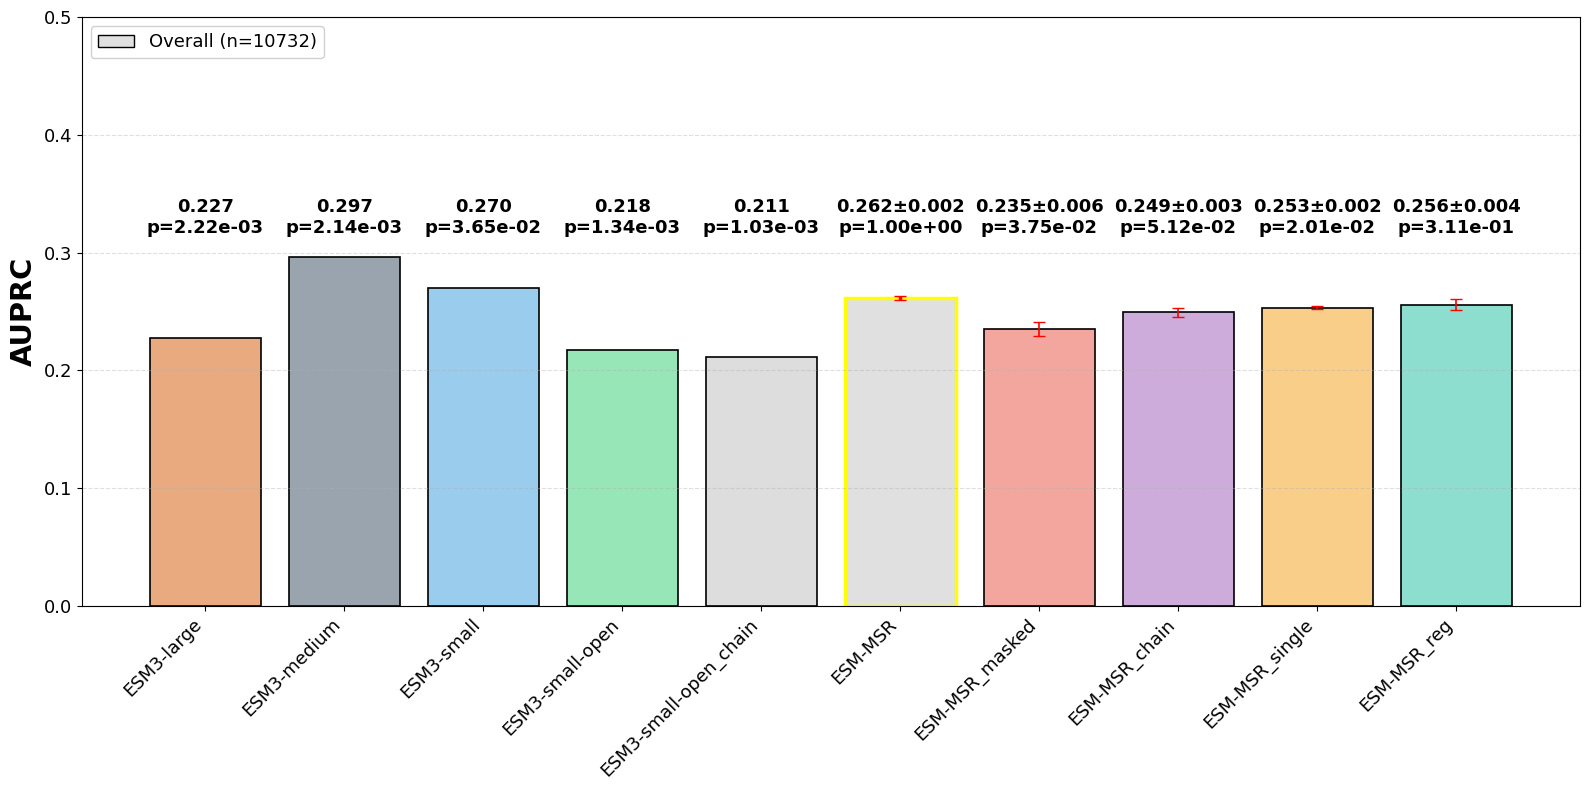

In [47]:
analysis_utils_msr.create_triple_metric_chart_with_pvals(series_bar1=None,
                                      series_bar2=None, 
                                      series_overall=df_scores_dddG_cls.loc[('hyperopt_splits-D-test', 'ungrouped')], 
                                      model_groups=['ESM3-large','ESM3-medium','ESM3-small','ESM3-small-open', 'ESM3-small-open_chain', 'ESM-MSR', 'ESM-MSR_masked', 'ESM-MSR_chain', 'ESM-MSR_single', 'ESM-MSR_reg'], 
                                      title=None, y_label='AUPRC', highlighted_model='ESM-MSR', enforce_global_n=False, ylim=(0,0.5), figsize=(16,8), p_value_y_coord=0.33, label_min_sep=0.02, fontsize_multiplier=1.3, legend_loc='upper left', is_grouped=False)

In [48]:
df_dddG_valid = df_dddG.loc[df_dddG['ddG_additive']>=-2]
df_scores_dddG_valid = pd.DataFrame(index=pd.MultiIndex.from_product([['hyperopt_splits-D-test'], ['ungrouped', 'grouped']]))

df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_1_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_2_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_3_dddG', label='ddG_dddG')

df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_alpha_med_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_med_1_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_alpha_med_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_med_2_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_alpha_med_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_med_3_dddG', label='ddG_dddG')

df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_alpha_low_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_low_1_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_alpha_low_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_low_2_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_alpha_low_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_low_3_dddG', label='ddG_dddG')

df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_single_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_single_1_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_single_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_single_2_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_single_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_single_3_dddG', label='ddG_dddG')

df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_reg_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_reg_1_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_reg_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_reg_2_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_reg_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_reg_3_dddG', label='ddG_dddG')

df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_chain_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_chain_1_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_chain_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_chain_2_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_chain_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_chain_3_dddG', label='ddG_dddG')

df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_masked_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_masked_1_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_masked_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_masked_2_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_masked_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_masked_3_dddG', label='ddG_dddG')

df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'Negative_additive', 'hyperopt_splits-D-test', pred_col='ddG_additive', label='ddG_dddG')
df_scores_dddG_valid['Negative_additive'] *= -1

df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'SPURS_1', 'hyperopt_splits-D-test', pred_col='SPURS_1_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'SPURS_2', 'hyperopt_splits-D-test', pred_col='SPURS_2_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'SPURS_3', 'hyperopt_splits-D-test', pred_col='SPURS_3_dddG', label='ddG_dddG')

df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ThermoMPNN(-D)_1', 'hyperopt_splits-D-test', pred_col='ThermoMPNN(-D)_1_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ThermoMPNN(-D)_2', 'hyperopt_splits-D-test', pred_col='ThermoMPNN(-D)_2_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ThermoMPNN(-D)_3', 'hyperopt_splits-D-test', pred_col='ThermoMPNN(-D)_3_dddG', label='ddG_dddG')

df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'MutateEverything_1', 'hyperopt_splits-D-test', pred_col='MutateEverything_1_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'MutateEverything_2', 'hyperopt_splits-D-test', pred_col='MutateEverything_2_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'MutateEverything_3', 'hyperopt_splits-D-test', pred_col='MutateEverything_3_dddG', label='ddG_dddG')

df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM3-small-open', 'hyperopt_splits-D-test', pred_col='ESM3-small-open_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM3-small-open_chain', 'hyperopt_splits-D-test', pred_col='ESM3-small-open_chain_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM3-small', 'hyperopt_splits-D-test', pred_col='ESM3-small_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM3-medium', 'hyperopt_splits-D-test', pred_col='ESM3-medium_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM3-large', 'hyperopt_splits-D-test', pred_col='ESM3-large_dddG', label='ddG_dddG')

df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'Rosetta Cartesian DDG_1', 'hyperopt_splits-D-test', pred_col='Rosetta Cartesian DDG_1_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'Rosetta Cartesian DDG_2', 'hyperopt_splits-D-test', pred_col='Rosetta Cartesian DDG_2_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'Rosetta Cartesian DDG_3', 'hyperopt_splits-D-test', pred_col='Rosetta Cartesian DDG_3_dddG', label='ddG_dddG')

df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ProteinMPNN', 'hyperopt_splits-D-test', pred_col='ProteinMPNN_dddG', label='ddG_dddG')



df_dddG_dubious = df_dddG.loc[df_dddG['ddG_additive']<-2]
df_scores_dddG_dubious = pd.DataFrame(index=pd.MultiIndex.from_product([['hyperopt_splits-D-test'], ['ungrouped', 'grouped']]))

df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_1_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_2_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_3_dddG', label='ddG_dddG')

df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_alpha_med_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_med_1_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_alpha_med_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_med_2_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_alpha_med_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_med_3_dddG', label='ddG_dddG')

df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_alpha_low_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_low_1_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_alpha_low_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_low_2_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_alpha_low_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_alpha_low_3_dddG', label='ddG_dddG')

df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_single_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_single_1_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_single_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_single_2_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_single_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_single_3_dddG', label='ddG_dddG')

df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_reg_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_reg_1_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_reg_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_reg_2_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_reg_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_reg_3_dddG', label='ddG_dddG')

df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_chain_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_chain_1_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_chain_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_chain_2_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_chain_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_chain_3_dddG', label='ddG_dddG')

df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_masked_1', 'hyperopt_splits-D-test', pred_col='ESM-MSR_masked_1_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_masked_2', 'hyperopt_splits-D-test', pred_col='ESM-MSR_masked_2_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_masked_3', 'hyperopt_splits-D-test', pred_col='ESM-MSR_masked_3_dddG', label='ddG_dddG')

df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'Negative_additive', 'hyperopt_splits-D-test', pred_col='ddG_additive', label='ddG_dddG')
df_scores_dddG_dubious['Negative_additive'] *= -1

df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'SPURS_1', 'hyperopt_splits-D-test', pred_col='SPURS_1_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'SPURS_2', 'hyperopt_splits-D-test', pred_col='SPURS_2_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'SPURS_3', 'hyperopt_splits-D-test', pred_col='SPURS_3_dddG', label='ddG_dddG')

df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ThermoMPNN(-D)_1', 'hyperopt_splits-D-test', pred_col='ThermoMPNN(-D)_1_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ThermoMPNN(-D)_2', 'hyperopt_splits-D-test', pred_col='ThermoMPNN(-D)_2_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ThermoMPNN(-D)_3', 'hyperopt_splits-D-test', pred_col='ThermoMPNN(-D)_3_dddG', label='ddG_dddG')

df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'MutateEverything_1', 'hyperopt_splits-D-test', pred_col='MutateEverything_1_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'MutateEverything_2', 'hyperopt_splits-D-test', pred_col='MutateEverything_2_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'MutateEverything_3', 'hyperopt_splits-D-test', pred_col='MutateEverything_3_dddG', label='ddG_dddG')

df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM3-small-open', 'hyperopt_splits-D-test', pred_col='ESM3-small-open_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM3-small-open_chain', 'hyperopt_splits-D-test', pred_col='ESM3-small-open_chain_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM3-small', 'hyperopt_splits-D-test', pred_col='ESM3-small_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM3-medium', 'hyperopt_splits-D-test', pred_col='ESM3-medium_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM3-large', 'hyperopt_splits-D-test', pred_col='ESM3-large_dddG', label='ddG_dddG')

df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'Rosetta Cartesian DDG_1', 'hyperopt_splits-D-test', pred_col='Rosetta Cartesian DDG_1_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'Rosetta Cartesian DDG_2', 'hyperopt_splits-D-test', pred_col='Rosetta Cartesian DDG_2_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'Rosetta Cartesian DDG_3', 'hyperopt_splits-D-test', pred_col='Rosetta Cartesian DDG_3_dddG', label='ddG_dddG')

df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ProteinMPNN', 'hyperopt_splits-D-test', pred_col='ProteinMPNN_dddG', label='ddG_dddG')

df_scores_dddG_combined_2 = df_scores_dddG.join(df_scores_dddG_valid, rsuffix='_pos').join(df_scores_dddG_dubious, rsuffix='_neg')

df_scores_dddG_combined_2[[c for c in df_scores_dddG_combined_2.columns if 'ESM-MSR' in c]].columns



Index(['ESM-MSR_1', 'ESM-MSR_1_n', 'ESM-MSR_1_groups', 'ESM-MSR_2',
       'ESM-MSR_2_n', 'ESM-MSR_2_groups', 'ESM-MSR_3', 'ESM-MSR_3_n',
       'ESM-MSR_3_groups', 'ESM-MSR_alpha_med_1',
       ...
       'ESM-MSR_chain_3_groups_neg', 'ESM-MSR_masked_1_neg',
       'ESM-MSR_masked_1_n_neg', 'ESM-MSR_masked_1_groups_neg',
       'ESM-MSR_masked_2_neg', 'ESM-MSR_masked_2_n_neg',
       'ESM-MSR_masked_2_groups_neg', 'ESM-MSR_masked_3_neg',
       'ESM-MSR_masked_3_n_neg', 'ESM-MSR_masked_3_groups_neg'],
      dtype='object', length=189)

(<Figure size 1600x1000 with 1 Axes>, <Axes: ylabel="Average Spearman's ρ">)

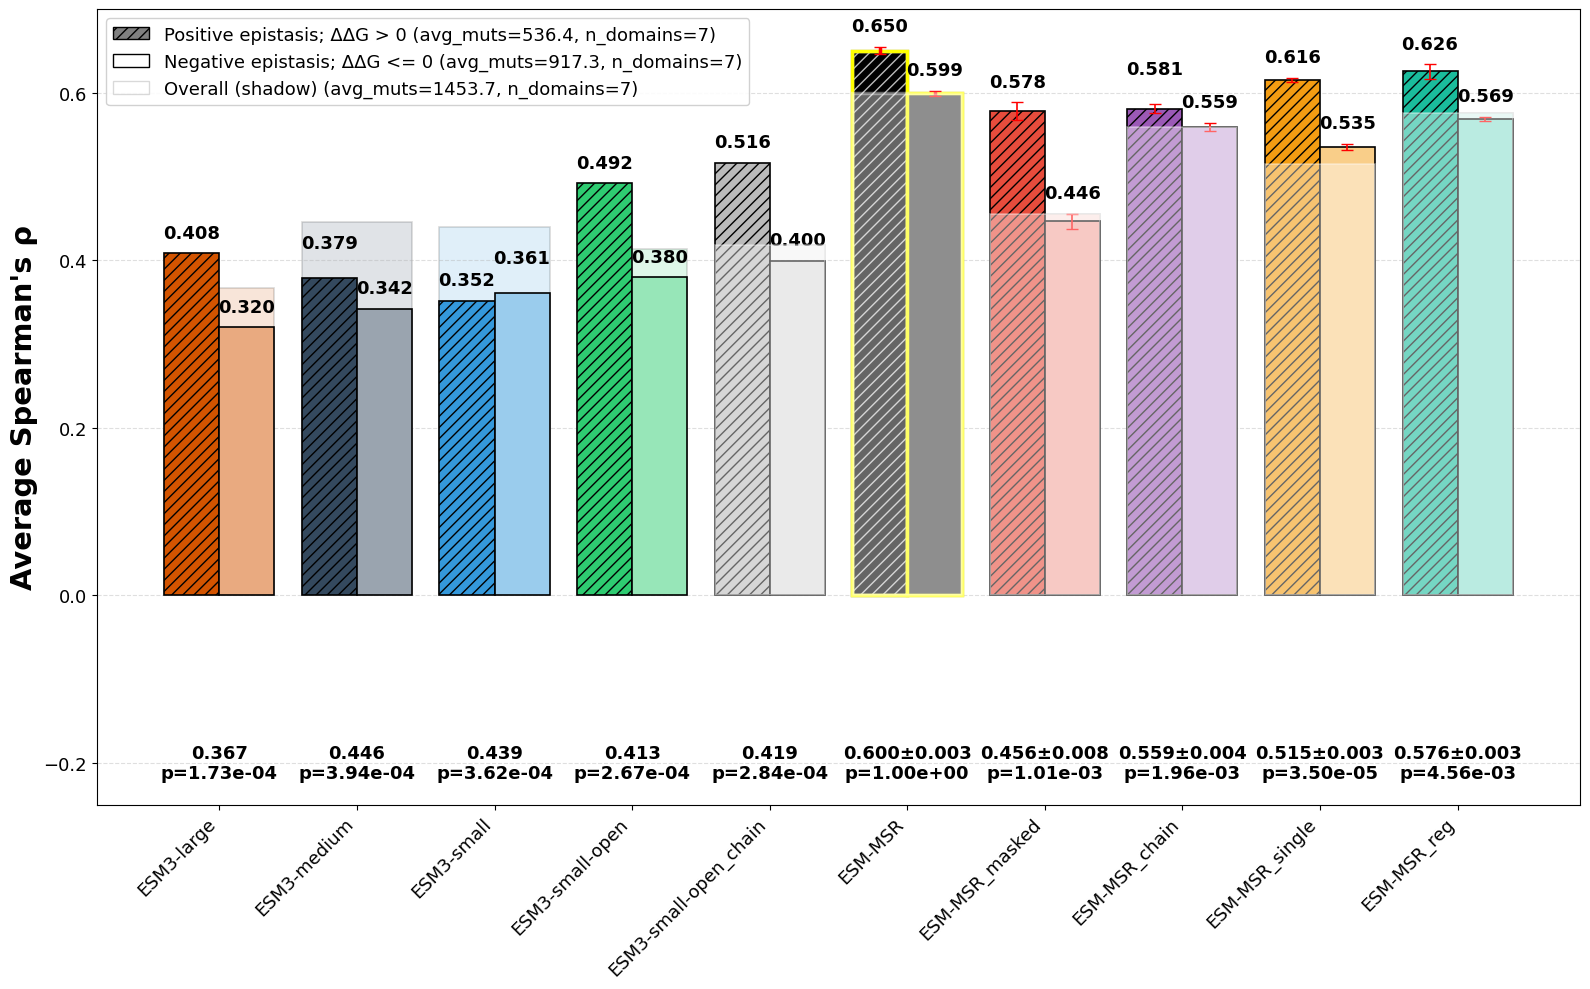

In [49]:
import importlib
importlib.reload(analysis_utils_msr)
analysis_utils_msr.create_pos_neg_overall_chart(df_scores_dddG_combined_2.loc[('hyperopt_splits-D-test', 'grouped')], 
                                                model_groups=['ESM3-large','ESM3-medium','ESM3-small','ESM3-small-open', 'ESM3-small-open_chain', 'ESM-MSR', 'ESM-MSR_masked', 'ESM-MSR_chain', 'ESM-MSR_single', 'ESM-MSR_reg'], 
                                                title=None, y_label='Average Spearman\'s ρ', highlighted_model='ESM-MSR', enforce_global_n=False, figsize=(16,10), ylim=(-0.25, 0.7), legend_loc='upper left',  p_value_y_coord=-0.2, fontsize_multiplier=1.3)


In [50]:
df_dddG = df_epistatic.copy(deep=True)
df_dddG = compute_dddg(df_dddG)

df_dddG = df_dddG.loc[df_dddG.index.str.contains(':')].reset_index()
df_dddG['code'] = df_dddG['uid'].apply(lambda x: x.split('_')[0])
df_dddG['pos1'] = df_dddG['mut_type'].apply(lambda x: x.split(':')[0][1:-1]).astype(int)
df_dddG['pos2'] = df_dddG['mut_type'].apply(lambda x: x.split(':')[1][1:-1]).astype(int)
df_dddG['mut1'] = df_dddG['mut_type'].apply(lambda x: x.split(':')[0][-1]).astype(str)
df_dddG['mut2'] = df_dddG['mut_type'].apply(lambda x: x.split(':')[1][-1]).astype(str)
tmp = df_dddG.drop(['uid', 'mut_type'], axis=1)
pt = tmp.pivot_table(index=['code', 'pos1', 'pos2', 'mut1'], columns=['mut2'])
pt

ESM-MSR_1                                          \
mut2                        A         C         D         E         F   
code pos1 pos2 mut1                                                     
1UFM 14   49   A    -1.114347       NaN -1.294540 -0.811828 -1.196557   
               D    -1.542809       NaN -1.737846 -1.341140 -1.724250   
               F    -0.904436       NaN -1.093126 -0.578241 -0.666567   
               G    -2.031697       NaN -2.211481 -1.758093 -2.096697   
               H    -1.238430       NaN -1.383013 -0.847595 -1.343363   
...                       ...       ...       ...       ...       ...   
HHH  36   39   S    -1.937498       NaN -3.848206 -2.637868 -2.163040   
               T    -2.027340       NaN -3.972990 -2.762277 -2.252117   
               V    -1.924339 -1.867715 -3.917674 -2.703239 -2.080019   
               W    -1.443978 -1.352501 -3.373727 -2.288049 -1.352063   
               Y    -1.582097 -1.522289       NaN -2.417407 -1.575207   

                                                                       ...  \
mut2                        G         H         I         K         L  ...   
code pos1 pos2 mut1                                                    ...   
1UFM 14   49   A    -1.960371 -1.374147 -1.124939 -1.163056 -1.105243  ...   
               D    -2.363911 -1.782124 -1.550019 -1.524974 -1.533886  ...   
               F    -1.761964 -0.975416 -0.614628 -0.911470 -0.646508  ...   
               G    -2.853233 -2.266081 -2.032692 -2.043689 -2.020407  ...   
               H    -2.080213 -1.504137 -1.205050 -1.305719 -1.199978  ...   
...                       ...       ...       ...       ...       ...  ...   
HHH  36   39   S    -3.437373 -2.395945 -1.888238 -1.197873 -1.569708  ...   
               T    -3.489027 -2.500239 -1.980910 -1.268751 -1.650904  ...   
               V    -3.367916 -2.408534 -1.876210 -1.230632 -1.498533  ...   
               W    -2.872181 -1.826809 -1.482457 -0.683887 -1.036362  ...   
               Y    -3.047439 -2.028417 -1.533821 -0.808580 -1.045771  ...   

                     random_3                                          \
mut2                        M         N         P         Q         R   
code pos1 pos2 mut1                                                     
1UFM 14   49   A     0.707125  0.299065  0.901790       NaN  0.493317   
               D     0.858160  0.547783  0.059050       NaN  0.324502   
               F     0.888442  0.165431  0.763377       NaN  0.756020   
               G     0.218676  0.488878  0.335604       NaN  0.966592   
               H     0.535266  0.252873  0.694153       NaN  0.945816   
...                       ...       ...       ...       ...       ...   
HHH  36   39   S     0.586398  0.648947       NaN  0.121681       NaN   
               T     0.564036  0.228902  0.668972  0.034539       NaN   
               V     0.433113  0.562953       NaN  0.194186       NaN   
               W     0.522741  0.833468  0.746561  0.664959       NaN   
               Y     0.646327  0.476040  0.172077  0.742705       NaN   

                                                                       
mut2                        S         T         V         W         Y  
code pos1 pos2 mut1                                                    
1UFM 14   49   A     0.464511  0.629772  0.389562  0.556972  0.852129  
               D     0.593334  0.466309  0.316586  0.423685  0.402802  
               F     0.320457  0.714559  0.808692  0.965947  0.704150  
               G     0.984334  0.470201  0.277717  0.345804  0.803216  
               H     0.828878  0.695118  0.821499  0.071031  0.882398  
...                       ...       ...       ...       ...       ...  
HHH  36   39   S     0.319264  0.485043  0.942951  0.146648  0.872481  
               T     0.441266  0.952964  0.452781  0.128749  0.310119  
               V     0.838586  0.591481  0.977549  0.157192  0.297587  
               W 

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

# 20 canonical amino acids (1-letter)
AA  = ['K', 'R', 'H', 'D', 'E', 'S', 'T', 'N', 'Q', 'Y', 'C', 'A', 'V', 'I', 'L', 'M', 'F', 'W', 'P', 'G']
IDX = {aa:i for i,aa in enumerate(AA)}
POS = {'K','R','H'}
NEG = {'D','E'}

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_joint_with_marginals(
    P, PA, PB, aa_labels, *,
    cmap='viridis',
    vmin=None, vmax=None,
    pos1=0, pos2=0
):
    n = len(aa_labels)
    
    # 1. Main Plot
    fig, ax_main = plt.subplots(figsize=(9., 8.))
    
    im = ax_main.imshow(P, origin='lower', interpolation='nearest',
                        cmap=cmap, vmin=vmin, vmax=vmax, aspect='equal')
    
    ax_main.set_xticks([])
    #ax_main.set_xticklabels(aa_labels)
    ax_main.set_yticks([])
    #ax_main.set_yticklabels(aa_labels)
    ax_main.grid(False)
    ax_main.set_xlabel(pos2, rotation=0, fontsize=16)
    ax_main.set_ylabel(pos1, rotation=90, fontsize=16)

    # Annotate identities
    for i in range(n):
        ax_main.text(i, i, aa_labels[i], ha='center', va='center', fontsize=16, color='red')

    # 2. Divider for Marginals
    divider = make_axes_locatable(ax_main)
    
    # Append Top Axis
    ax_top = divider.append_axes("top", size="20%", pad=0.1, sharex=ax_main)
    
    # Append Right Axis
    ax_right = divider.append_axes("right", size="20%", pad=0.1, sharey=ax_main)
    
    # Append Colorbar Axis
    ax_cbar = divider.append_axes("right", size="5%", pad=0.15)

    extra = 0.2

    # --- 3. Top marginal P(B) ---
    pb = PB.squeeze()
    ax_top.bar(range(n), pb, align='center')
    ax_top.set_xlim(-0.5, n-0.5)
    ax_top.set_ylim(pb.min()-extra, pb.max()+extra)
    
    # Visuals: Add "score" and ticks
    ax_top.set_ylabel("score", fontsize=12)
    ax_top.tick_params(axis='y', labelsize=10)      # Show Y values
    ax_top.tick_params(axis='x', labelbottom=False) # Hide X labels (sharex with main)
    ax_top.grid(False)
    # (Optional) Remove top/right spines for cleanliness, keep Left/Bottom
    ax_top.spines['top'].set_visible(False)
    ax_top.spines['right'].set_visible(False)

    # --- 4. Right marginal P(A) ---
    pa = PA.squeeze()
    ax_right.barh(range(n), pa, align='center')
    ax_right.set_ylim(-0.5, n-0.5)
    ax_right.set_xlim(pa.min()-extra, pa.max()+extra)
    
    # Visuals: Add "score" and ticks
    ax_right.set_xlabel("score", fontsize=12)
    ax_right.tick_params(axis='x', labelsize=10)    # Show X values
    ax_right.tick_params(axis='y', labelleft=False) # Hide Y labels (sharey with main)
    ax_right.grid(False)
    # (Optional) Remove top/right spines for cleanliness, keep Bottom/Left
    ax_right.spines['top'].set_visible(False)
    ax_right.spines['right'].set_visible(False)

    # --- 5. Colorbar ---
    cbar = fig.colorbar(im, cax=ax_cbar)
    cbar.ax.tick_params(length=3)

    return fig

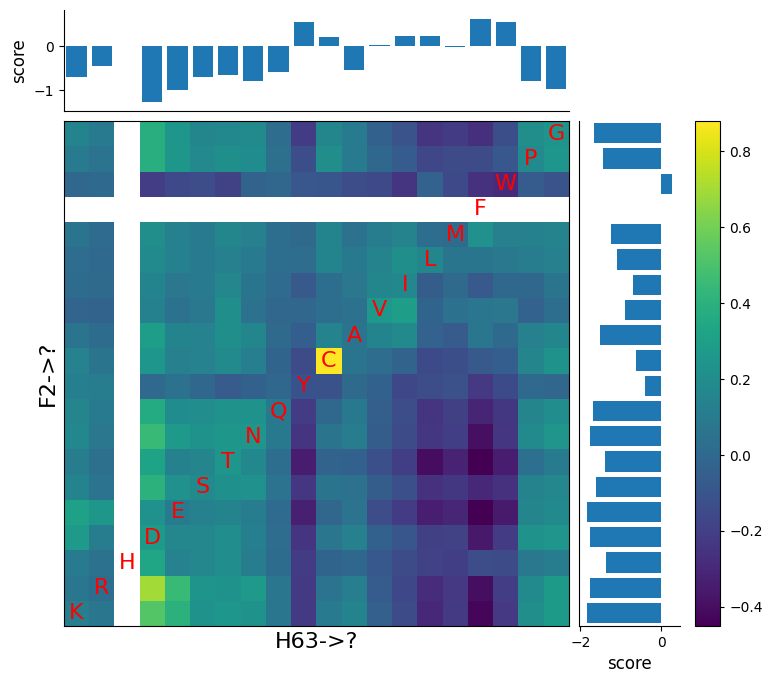

In [52]:
p = df_epistatic.loc[~df_epistatic.index.str.contains(':')]
p = p.loc[p['code']=='6M3N']
p['mutation'] = p['mut_type'].apply(lambda x: x[-1])

PA = p.loc[p['mut_type'].apply(lambda x: int(x[1:-1]))==2]
PA = PA.set_index('mutation')
PA.loc['F', :] = np.nan
PA = PA.loc[AA]

PB = p.loc[p['mut_type'].apply(lambda x: int(x[1:-1]))==63]
PB = PB.set_index('mutation')
PB.loc['H', :] = np.nan
PB = PB.loc[AA]

p_test_double = pt.loc[('6M3N', 2, 63), ('ESM-MSR_1_dddG', slice(None))]
p_test_double = p_test_double.T.reset_index(level=0, drop=True).T
p_test_double.loc['F', :] = np.nan
p_test_double

AA = ['K', 'R', 'H', 'D', 'E', 'S', 'T', 'N', 'Q', 'Y', 'C', 'A', 'V', 'I', 'L', 'M', 'F', 'W', 'P', 'G']
p_test_double = p_test_double.loc[AA, AA]
#pa = p_test_double.mean(axis=1)
#pb = p_test_double.mean(axis=0)
pa = PA['ESM-MSR_1']
pb = PB['ESM-MSR_1']
_ = plot_joint_with_marginals(p_test_double, pa, pb, aa_labels=AA, pos1='F2->?', pos2='H63->?')

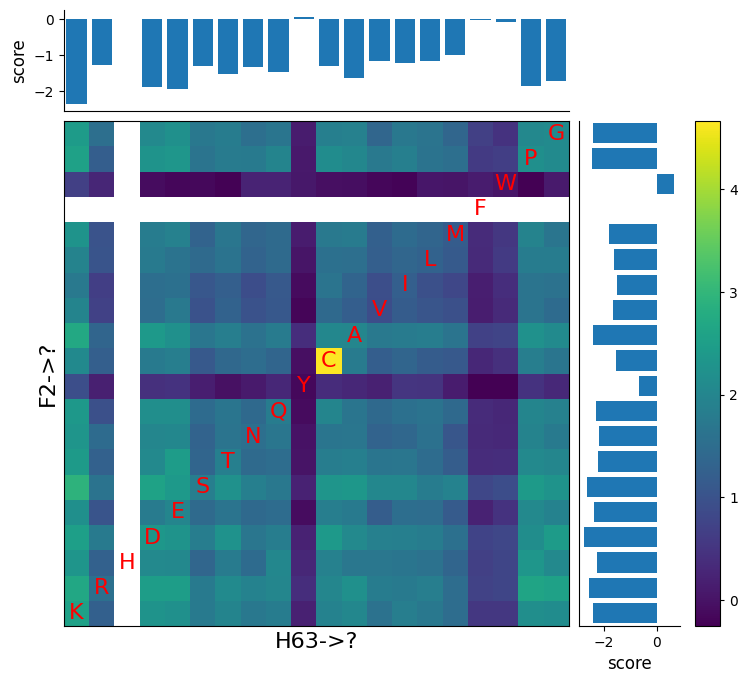

In [53]:
p_test_double = pt.loc[('6M3N', 2, 63), ('ddG_dddG', slice(None))]
p_test_double = p_test_double.T.reset_index(level=0, drop=True).T
p_test_double.loc['F', :] = np.nan
p_test_double

AA = ['K', 'R', 'H', 'D', 'E', 'S', 'T', 'N', 'Q', 'Y', 'C', 'A', 'V', 'I', 'L', 'M', 'F', 'W', 'P', 'G']
p_test_double = p_test_double.loc[AA, AA]
#pa = p_test_double.mean(axis=1)
#pb = p_test_double.mean(axis=0)
pa = PA['ddG']
pb = PB['ddG']
_ = plot_joint_with_marginals(p_test_double, pa, pb, aa_labels=AA, pos1='F2->?', pos2='H63->?')

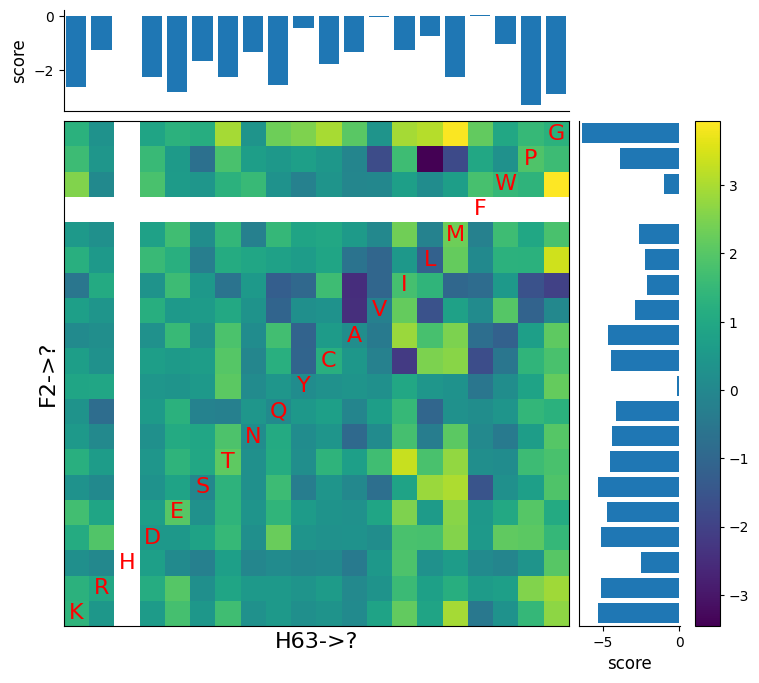

In [54]:
p_test_double = pt.loc[('6M3N', 2, 63), ('Rosetta Cartesian DDG_1_dddG', slice(None))]
p_test_double = p_test_double.T.reset_index(level=0, drop=True).T
p_test_double.loc['F', :] = np.nan
p_test_double

AA = ['K', 'R', 'H', 'D', 'E', 'S', 'T', 'N', 'Q', 'Y', 'C', 'A', 'V', 'I', 'L', 'M', 'F', 'W', 'P', 'G']
p_test_double = p_test_double.loc[AA, AA]
#pa = p_test_double.mean(axis=1)
#pb = p_test_double.mean(axis=0)
pa = PA['Rosetta Cartesian DDG_1']
pb = PB['Rosetta Cartesian DDG_1']
_ = plot_joint_with_marginals(p_test_double, pa, pb, aa_labels=AA, pos1='F2->?', pos2='H63->?')

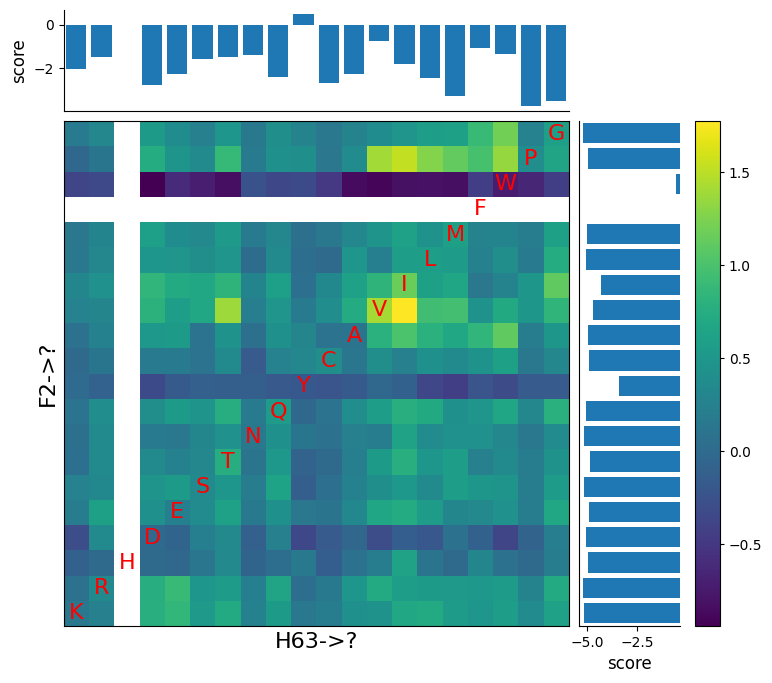

In [55]:
p_test_double = pt.loc[('6M3N', 2, 63), ('ProteinMPNN_dddG', slice(None))]
p_test_double = p_test_double.T.reset_index(level=0, drop=True).T
p_test_double.loc['F', :] = np.nan
p_test_double

AA = ['K', 'R', 'H', 'D', 'E', 'S', 'T', 'N', 'Q', 'Y', 'C', 'A', 'V', 'I', 'L', 'M', 'F', 'W', 'P', 'G']
p_test_double = p_test_double.loc[AA, AA]
#pa = p_test_double.mean(axis=1)
#pb = p_test_double.mean(axis=0)
pa = PA['ProteinMPNN']
pb = PB['ProteinMPNN']
_ = plot_joint_with_marginals(p_test_double, pa, pb, aa_labels=AA, pos1='F2->?', pos2='H63->?')

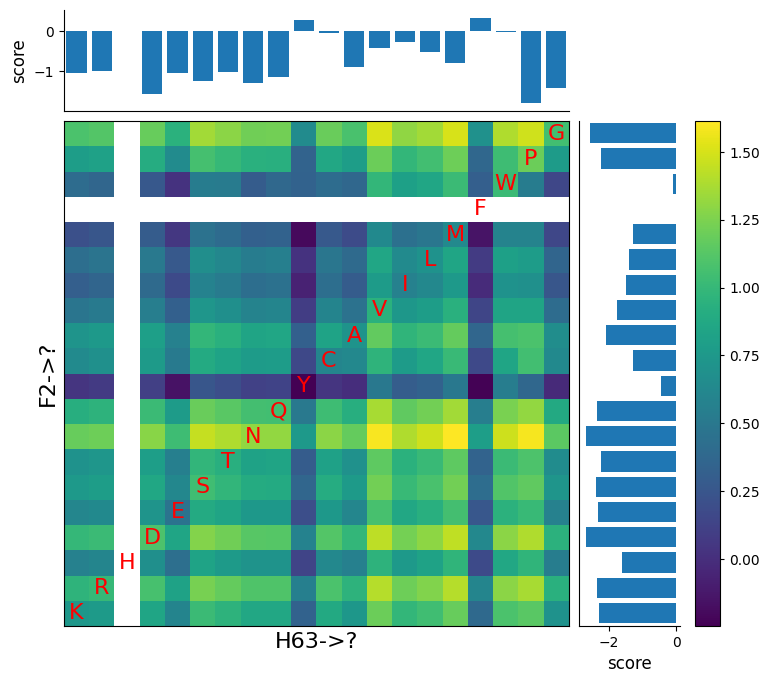

In [56]:
p_test_double = pt.loc[('6M3N', 2, 63), ('ThermoMPNN(-D)_1_dddG', slice(None))]
p_test_double = p_test_double.T.reset_index(level=0, drop=True).T
p_test_double.loc['F', :] = np.nan
p_test_double

AA = ['K', 'R', 'H', 'D', 'E', 'S', 'T', 'N', 'Q', 'Y', 'C', 'A', 'V', 'I', 'L', 'M', 'F', 'W', 'P', 'G']
p_test_double = p_test_double.loc[AA, AA]
#pa = p_test_double.mean(axis=1)
#pb = p_test_double.mean(axis=0)
pa = PA['ThermoMPNN(-D)_1']
pb = PB['ThermoMPNN(-D)_1']
_ = plot_joint_with_marginals(p_test_double, pa, pb, aa_labels=AA, pos1='F2->?', pos2='H63->?')

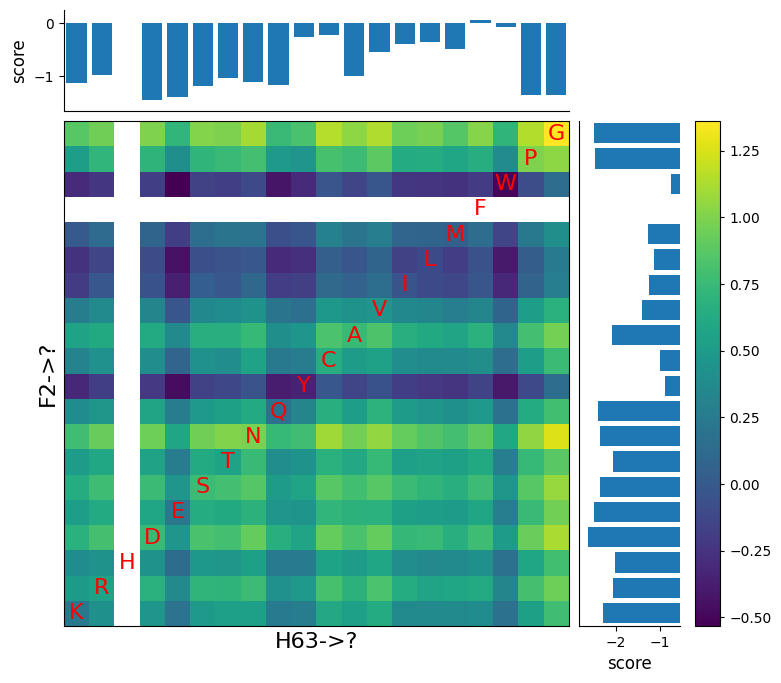

In [57]:
p_test_double = pt.loc[('6M3N', 2, 63), ('SPURS_1_dddG', slice(None))]
p_test_double = p_test_double.T.reset_index(level=0, drop=True).T
p_test_double.loc['F', :] = np.nan
p_test_double

AA = ['K', 'R', 'H', 'D', 'E', 'S', 'T', 'N', 'Q', 'Y', 'C', 'A', 'V', 'I', 'L', 'M', 'F', 'W', 'P', 'G']
p_test_double = p_test_double.loc[AA, AA]
#pa = p_test_double.mean(axis=1)
#pb = p_test_double.mean(axis=0)
pa = PA['SPURS_1']
pb = PB['SPURS_1']
_ = plot_joint_with_marginals(p_test_double, pa, pb, aa_labels=AA, pos1='F2->?', pos2='H63->?')

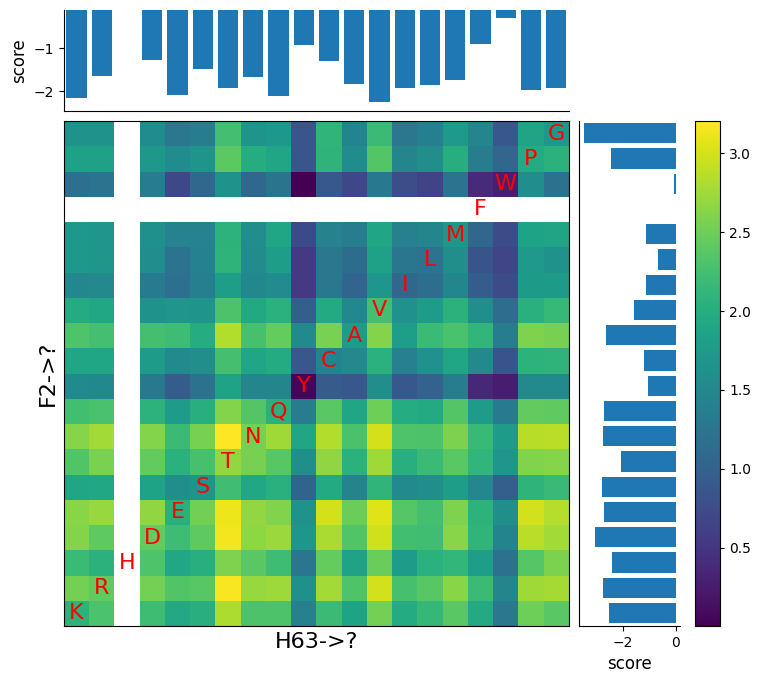

In [58]:
p_test_double = pt.loc[('6M3N', 2, 63), ('MutateEverything_1_dddG', slice(None))]
p_test_double = p_test_double.T.reset_index(level=0, drop=True).T
p_test_double.loc['F', :] = np.nan
p_test_double

AA = ['K', 'R', 'H', 'D', 'E', 'S', 'T', 'N', 'Q', 'Y', 'C', 'A', 'V', 'I', 'L', 'M', 'F', 'W', 'P', 'G']
p_test_double = p_test_double.loc[AA, AA]
#pa = p_test_double.mean(axis=1)
#pb = p_test_double.mean(axis=0)
pa = PA['MutateEverything_1']
pb = PB['MutateEverything_1']
_ = plot_joint_with_marginals(p_test_double, pa, pb, aa_labels=AA, pos1='F2->?', pos2='H63->?')

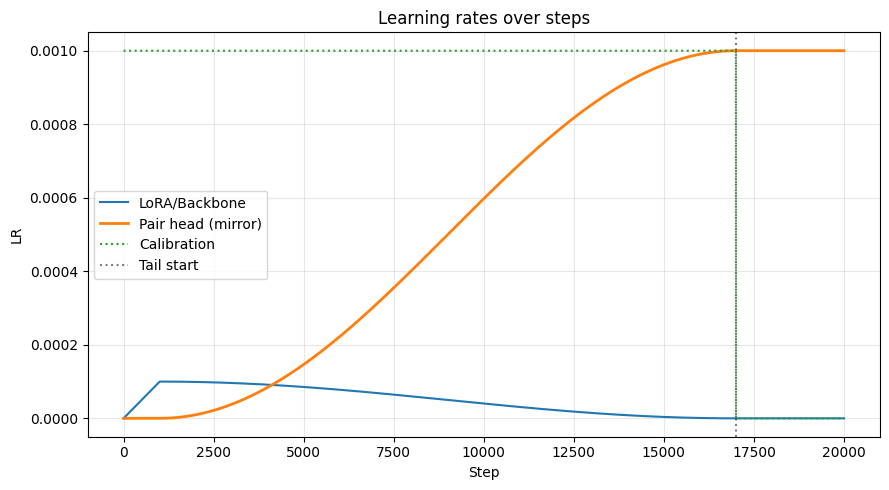

In [59]:
import math
import numpy as np
import matplotlib.pyplot as plt

# --- Match these to your hparams ---
base_lr           = 1e-4
pair_lr_mult      = 10.0
calib_lr_mult     = 10.0
lr_warmup_steps   = 1000
lr_total_steps    = 20000
lr_tail_steps     = 3000
lr_tail_lora_mult = 0.0   # 0.0 => LoRA frozen in tail
tail_only_pair    = True

main_end = max(0, lr_total_steps - lr_tail_steps)

def warmcos(step, warmup, total_main):
    if total_main <= 0:
        return 1.0
    if step < warmup:
        return step / max(1, warmup)
    t = min(max(0, step - warmup), max(1, total_main - warmup))
    prog = t / max(1, total_main - warmup)
    return 0.5 * (1.0 + math.cos(math.pi * prog))  # 1 -> 0

def lambda_lora(step):
    if step < main_end:
        return warmcos(step, lr_warmup_steps, main_end)
    return lr_tail_lora_mult

def lambda_pair(step):
    if step < lr_warmup_steps:
        return 0.0
    if step < main_end:
        return 1.0 - warmcos(step, lr_warmup_steps, main_end)
    return max(0.0, min(1.0, 1.0 - lr_tail_lora_mult))

def lambda_calib(step):
    if step < main_end:
        return 1.0
    return 0.0 if tail_only_pair else 1.0

steps = np.arange(lr_total_steps+1)
lora_lr  = base_lr * np.array([lambda_lora(s)  for s in steps])
pair_lr  = base_lr * pair_lr_mult  * np.array([lambda_pair(s)  for s in steps])
cal_lr   = base_lr * calib_lr_mult * np.array([lambda_calib(s) for s in steps])

plt.figure(figsize=(9,5))
plt.plot(steps, lora_lr,  label="LoRA/Backbone")
plt.plot(steps, pair_lr,  label="Pair head (mirror)", linewidth=2)
plt.plot(steps, cal_lr,   label="Calibration", linestyle=":")
plt.axvline(main_end, color='k', linestyle=':', alpha=0.5, label="Tail start")
plt.title("Learning rates over steps")
plt.xlabel("Step")
plt.ylabel("LR")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [60]:
# Extract the part of 'code' after the last underscore.
# If no underscore, it takes the whole string.
# If 'code' is NaN, this will result in NaN.
part_after_last_underscore = df['code'].str.rsplit('_', n=1).str[-1]

# Regex for: one letter, two digits, one letter.
# ^ and $ ensure the entire extracted part matches this pattern.
# na=False ensures that if part_after_last_underscore is NaN, it evaluates to False.
regex_suffix_pattern = r'^[a-zA-Z]\d{2}[a-zA-Z]$'
condition2 = part_after_last_underscore.str.fullmatch(regex_suffix_pattern, na=False)

df_destab = df.loc[condition2]
df_no_destab = df.drop(df_destab.index)

# 1. Extract the part of 'code' before the first underscore.
#    If no underscore, it takes the whole string.
code_prefix = df['code'].str.split('_', n=1).str[0]

# 2. Define the regex to match strings containing only A, E, G, H, X.
#    ^ asserts position at start of the string.
#    [AEGHX] matches any character from the set A, E, G, H, X.
#    * matches the previous token between zero and unlimited times.
#    $ asserts position at the end of the string.
regex_pattern = r'^[AEGHX]*$'

# 3. Create a boolean Series by checking if the extracted prefix fully matches the regex.
#    .str.fullmatch() checks if the entire string matches the pattern.
#    .fillna(False) handles any NaN values that might result from NaN 'code' values
#    or if 'code' wasn't a string type initially for some rows.
matches = code_prefix.str.fullmatch(regex_pattern).fillna(False)
matches2 = df.loc[df['code'].str.contains('TrROS')].index

# 4. Use the boolean Series to filter the original DataFrame.
df_synthetic = df.loc[matches | df['code'].str.contains('TrROS', na=False, regex=False)]
df_natural = df.drop(df_synthetic.index)

df_singles = df.loc[~df['mut_type'].str.contains(':')]
df_doubles = df.loc[df['mut_type'].str.contains(':')]

# All raw predictions
df

,ThermoMPNN_1,ThermoMPNN(-D)_1,ThermoMPNN_2,ThermoMPNN(-D)_2,ThermoMPNN_3,ThermoMPNN(-D)_3,ThermoMPNN(-D)_additive_1,ThermoMPNN(-D)_additive_2,ThermoMPNN(-D)_additive_3,ddG_ML_thermo,...,ESM-MSR_chain_3,ESM-MSR_chain_additive_3,ESM3-small-open_chain,ESM3-small-open_chain_additive,random_1,random_2,random_3,ddG_1,ddG_2,ddG_3
uid,,,,,,,,,,,,,,,,,,,,,
1UFM_A11C,0.182458,0.182458,0.229011,0.229011,0.112110,0.112110,0.182458,0.229011,0.112110,0.004061,...,-0.008952,NaN,-3.500977,-3.500977,0.266242,0.232601,0.651649,-0.001795,-0.203509,0.080637
1UFM_A11D,-0.534806,-0.534806,-0.776187,-0.776187,-0.690362,-0.690362,-0.534806,-0.776187,-0.690362,-0.023454,...,-0.349982,NaN,-3.756836,-3.756836,0.085816,0.381325,0.406105,-0.001695,0.094962,-0.008737
1UFM_A11E,-0.127483,-0.127483,-0.176427,-0.176427,-0.169683,-0.169683,-0.127483,-0.176427,-0.169683,0.111864,...,-0.195433,NaN,-2.891602,-2.891602,0.358930,0.492106,0.094360,0.197139,0.102911,0.299761
1UFM_A11F,-0.037749,-0.037749,-0.077629,-0.077629,-0.115784,-0.115784,-0.037749,-0.077629,-0.115784,-0.153650,...,-0.200250,NaN,-0.421875,-0.421875,0.293084,0.259923,0.475430,-0.229725,-0.075959,-0.007831
1UFM_A11G,-0.565192,-0.565192,-0.628311,-0.628311,-0.642682,-0.642682,-0.565192,-0.628311,-0.642682,-0.393182,...,-0.567176,NaN,-1.704346,-1.704346,0.765170,0.408962,0.949805,-0.459324,-0.265877,-0.216910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HHH_rd1_0949_R10Y:E36S,-1.687004,-0.557682,-1.533284,-1.408043,-1.497178,-0.774565,-1.687004,-1.533284,-1.497178,NaN,...,-1.184945,-1.764554,-6.273010,-8.136230,0.698036,0.873268,0.729934,-0.165918,-0.515169,-0.009864
HHH_rd1_0949_R10Y:E36T,-1.304661,-0.486829,-1.297930,-1.210776,-1.352677,-0.265816,-1.304661,-1.297930,-1.352677,NaN,...,-0.959004,-1.458845,-6.709229,-8.262451,0.966489,0.464279,0.506215,-0.330918,-0.594883,-0.290881
HHH_rd1_0949_R10Y:E36V,-0.525491,-0.274588,-0.531802,-0.501731,-0.583954,0.229817,-0.525491,-0.531802,-0.583954,NaN,...,-0.217062,-1.098734,-4.707153,-6.614746,0.741760,0.125230,0.065568,0.195539,0.312578,0.377793


In [61]:
df_destab

,ThermoMPNN_1,ThermoMPNN(-D)_1,ThermoMPNN_2,ThermoMPNN(-D)_2,ThermoMPNN_3,ThermoMPNN(-D)_3,ThermoMPNN(-D)_additive_1,ThermoMPNN(-D)_additive_2,ThermoMPNN(-D)_additive_3,ddG_ML_thermo,...,ESM-MSR_chain_3,ESM-MSR_chain_additive_3,ESM3-small-open_chain,ESM3-small-open_chain_additive,random_1,random_2,random_3,ddG_1,ddG_2,ddG_3
uid,,,,,,,,,,,,,,,,,,,,,
2K5H_G11S_A16C,0.046979,0.046979,0.249217,0.249217,0.076645,0.076645,0.046979,0.249217,0.076645,-0.213358,...,-0.127358,NaN,-4.082031,-4.082031,0.227231,0.831739,0.560210,-0.222266,-0.083012,-0.388255
2K5H_G11S_A16D,-1.036003,-1.036003,-0.852490,-0.852490,-1.009371,-1.009371,-1.036003,-0.852490,-1.009371,-2.029711,...,-0.919783,NaN,-2.433594,-2.433594,0.821421,0.254597,0.238177,-1.890641,-1.965869,-1.894870
2K5H_G11S_A16E,-0.587239,-0.587239,-0.503795,-0.503795,-0.641665,-0.641665,-0.587239,-0.503795,-0.641665,-1.146346,...,-0.429852,NaN,-0.200195,-0.200195,0.594929,0.902725,0.170025,-0.986082,-1.243993,-1.067220
2K5H_G11S_A16F,-0.024102,-0.024102,0.287125,0.287125,-0.126980,-0.126980,-0.024102,0.287125,-0.126980,-0.681503,...,-0.523631,NaN,-2.895508,-2.895508,0.008136,0.103901,0.164835,-0.585100,-0.693950,-0.651663
2K5H_G11S_A16G,-0.708306,-0.708306,-0.459338,-0.459338,-0.631421,-0.631421,-0.708306,-0.459338,-0.631421,-0.894964,...,-0.554826,NaN,-2.598633,-2.598633,0.324165,0.557107,0.965186,-0.939095,-0.926402,-0.937515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2K5H_G23A_W32I,-1.067356,-1.067356,-0.905483,-0.905483,-1.144713,-1.144713,-1.067356,-0.905483,-1.144713,-2.467404,...,-1.256215,NaN,-11.465332,-11.465332,0.405903,0.069871,0.929252,-2.303665,-2.522628,-2.055155
2K5H_G23A_W32L,-0.775358,-0.775358,-0.826621,-0.826621,-1.234344,-1.234344,-0.775358,-0.826621,-1.234344,-1.535847,...,-1.303674,NaN,-9.309570,-9.309570,0.142279,0.719162,0.942754,-1.694718,-1.477443,-1.586405
2K5H_G23A_W32M,-1.115607,-1.115607,-1.004328,-1.004328,-1.199729,-1.199729,-1.115607,-1.004328,-1.199729,-1.658541,...,-1.275073,NaN,-9.964844,-9.964844,0.991721,0.974705,0.407502,-1.591982,-1.699850,-1.567220


In [62]:
df_synthetic

,ThermoMPNN_1,ThermoMPNN(-D)_1,ThermoMPNN_2,ThermoMPNN(-D)_2,ThermoMPNN_3,ThermoMPNN(-D)_3,ThermoMPNN(-D)_additive_1,ThermoMPNN(-D)_additive_2,ThermoMPNN(-D)_additive_3,ddG_ML_thermo,...,ESM-MSR_chain_3,ESM-MSR_chain_additive_3,ESM3-small-open_chain,ESM3-small-open_chain_additive,random_1,random_2,random_3,ddG_1,ddG_2,ddG_3
uid,,,,,,,,,,,,,,,,,,,,,
EA_run3_0321_0005_A17C,-0.830232,-0.830232,-0.766644,-0.766644,-0.724406,-0.724406,-0.830232,-0.766644,-0.724406,-1.642537,...,-0.464985,NaN,-9.240234,-9.240234,0.391167,0.652393,0.558388,-1.486391,-1.680768,-1.676226
EA_run3_0321_0005_A17D,-2.164598,-2.164598,-2.033794,-2.033794,-2.250737,-2.250737,-2.164598,-2.033794,-2.250737,-1.047616,...,-2.072132,NaN,-13.870117,-13.870117,0.025601,0.294989,0.125544,-1.030188,-1.133273,-0.892505
EA_run3_0321_0005_A17E,-2.029873,-2.029873,-1.955475,-1.955475,-2.051458,-2.051458,-2.029873,-1.955475,-2.051458,-1.141996,...,-2.076048,NaN,-13.519531,-13.519531,0.984508,0.384167,0.983859,-1.125088,-1.300655,-1.382899
EA_run3_0321_0005_A17F,-1.202985,-1.202985,-1.222521,-1.222521,-1.385140,-1.385140,-1.202985,-1.222521,-1.385140,-0.086403,...,-1.048928,NaN,-16.625000,-16.625000,0.965987,0.397095,0.219628,-0.000360,-0.074482,-0.186427
EA_run3_0321_0005_A17G,-1.583284,-1.583284,-1.513969,-1.513969,-1.603062,-1.603062,-1.583284,-1.513969,-1.603062,-0.826196,...,-1.572290,NaN,-7.304688,-7.304688,0.143633,0.221726,0.968050,-0.850873,-0.554655,-0.496227
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HHH_rd1_0949_R10Y:E36S,-1.687004,-0.557682,-1.533284,-1.408043,-1.497178,-0.774565,-1.687004,-1.533284,-1.497178,NaN,...,-1.184945,-1.764554,-6.273010,-8.136230,0.698036,0.873268,0.729934,-0.165918,-0.515169,-0.009864
HHH_rd1_0949_R10Y:E36T,-1.304661,-0.486829,-1.297930,-1.210776,-1.352677,-0.265816,-1.304661,-1.297930,-1.352677,NaN,...,-0.959004,-1.458845,-6.709229,-8.262451,0.966489,0.464279,0.506215,-0.330918,-0.594883,-0.290881
HHH_rd1_0949_R10Y:E36V,-0.525491,-0.274588,-0.531802,-0.501731,-0.583954,0.229817,-0.525491,-0.531802,-0.583954,NaN,...,-0.217062,-1.098734,-4.707153,-6.614746,0.741760,0.125230,0.065568,0.195539,0.312578,0.377793


In [63]:
df_scores_singles = pd.DataFrame(index=pd.MultiIndex.from_product([['hyperopt_splits-test'], ['ungrouped', 'grouped']]))

df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'ESM-MSR_1', 'hyperopt_splits-test', pred_col='ESM-MSR_1', label='ddG')
df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'ESM-MSR_2', 'hyperopt_splits-test', pred_col='ESM-MSR_2', label='ddG')
df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'ESM-MSR_3', 'hyperopt_splits-test', pred_col='ESM-MSR_3', label='ddG')
df_scores_singles = df_scores_singles.iloc[:, -6:].dropna(how='all')

df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'SPURS_1', 'hyperopt_splits-test', pred_col='SPURS_1', label='ddG')
df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'SPURS_2', 'hyperopt_splits-test', pred_col='SPURS_2', label='ddG')
df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'SPURS_3', 'hyperopt_splits-test', pred_col='SPURS_3', label='ddG')

df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'ThermoMPNN(-D)_1', 'hyperopt_splits-test', pred_col='ThermoMPNN(-D)_1', label='ddG')
df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'ThermoMPNN(-D)_2', 'hyperopt_splits-test', pred_col='ThermoMPNN(-D)_2', label='ddG')
df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'ThermoMPNN(-D)_3', 'hyperopt_splits-test', pred_col='ThermoMPNN(-D)_3', label='ddG')

df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'MutateEverything_1', 'hyperopt_splits-test', pred_col='MutateEverything_1', label='ddG')
df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'MutateEverything_2', 'hyperopt_splits-test', pred_col='MutateEverything_2', label='ddG')
df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'MutateEverything_3', 'hyperopt_splits-test', pred_col='MutateEverything_3', label='ddG')

df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'ESM3-small-open', 'hyperopt_splits-test', pred_col='ESM3-small-open', label='ddG')
#df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'ESM3-small', 'hyperopt_splits-test', pred_col='ESM3-small', label='ddG')
#df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'ESM3-medium', 'hyperopt_splits-test', pred_col='ESM3-medium', label='ddG')
#df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'ESM3-large', 'hyperopt_splits-test', pred_col='ESM3-large', label='ddG')

df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'Rosetta Cartesian DDG_1', 'hyperopt_splits-test', pred_col='Rosetta Cartesian DDG_1', label='ddG')
df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'Rosetta Cartesian DDG_2', 'hyperopt_splits-test', pred_col='Rosetta Cartesian DDG_2', label='ddG')
df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'Rosetta Cartesian DDG_3', 'hyperopt_splits-test', pred_col='Rosetta Cartesian DDG_3', label='ddG')

df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'ProteinMPNN', 'hyperopt_splits-test', pred_col='ProteinMPNN', label='ddG')

df_scores_singles

df_scores_doubles = pd.DataFrame(index=pd.MultiIndex.from_product([['hyperopt_splits-test'], ['ungrouped', 'grouped']]))

df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'ESM-MSR_1', 'hyperopt_splits-test', pred_col='ESM-MSR_1', label='ddG')
df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'ESM-MSR_2', 'hyperopt_splits-test', pred_col='ESM-MSR_2', label='ddG')
df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'ESM-MSR_3', 'hyperopt_splits-test', pred_col='ESM-MSR_3', label='ddG')
df_scores_doubles = df_scores_doubles.iloc[:, -6:].dropna(how='all')

df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'SPURS_1', 'hyperopt_splits-test', pred_col='SPURS_1', label='ddG')
df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'SPURS_2', 'hyperopt_splits-test', pred_col='SPURS_2', label='ddG')
df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'SPURS_3', 'hyperopt_splits-test', pred_col='SPURS_3', label='ddG')

df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'ThermoMPNN(-D)_1', 'hyperopt_splits-test', pred_col='ThermoMPNN(-D)_1', label='ddG')
df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'ThermoMPNN(-D)_2', 'hyperopt_splits-test', pred_col='ThermoMPNN(-D)_2', label='ddG')
df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'ThermoMPNN(-D)_3', 'hyperopt_splits-test', pred_col='ThermoMPNN(-D)_3', label='ddG')

df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'MutateEverything_1', 'hyperopt_splits-test', pred_col='MutateEverything_1', label='ddG')
df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'MutateEverything_2', 'hyperopt_splits-test', pred_col='MutateEverything_2', label='ddG')
df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'MutateEverything_3', 'hyperopt_splits-test', pred_col='MutateEverything_3', label='ddG')

df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'ESM3-small-open', 'hyperopt_splits-test', pred_col='ESM3-small-open', label='ddG')
#df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'ESM3-small', 'hyperopt_splits-test', pred_col='ESM3-small', label='ddG')
#df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'ESM3-medium', 'hyperopt_splits-test', pred_col='ESM3-medium', label='ddG')
#df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'ESM3-large', 'hyperopt_splits-test', pred_col='ESM3-large', label='ddG')

df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'Rosetta Cartesian DDG_1', 'hyperopt_splits-test', pred_col='Rosetta Cartesian DDG_1', label='ddG')
df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'Rosetta Cartesian DDG_2', 'hyperopt_splits-test', pred_col='Rosetta Cartesian DDG_2', label='ddG')
df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'Rosetta Cartesian DDG_3', 'hyperopt_splits-test', pred_col='Rosetta Cartesian DDG_3', label='ddG')

df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'ProteinMPNN', 'hyperopt_splits-test', pred_col='ProteinMPNN', label='ddG')

df_scores_doubles

df_scores_destab = pd.DataFrame(index=pd.MultiIndex.from_product([['hyperopt_splits-test'], ['ungrouped', 'grouped']]))

df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'ESM-MSR_1', 'hyperopt_splits-test', pred_col='ESM-MSR_1', label='ddG')
df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'ESM-MSR_2', 'hyperopt_splits-test', pred_col='ESM-MSR_2', label='ddG')
df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'ESM-MSR_3', 'hyperopt_splits-test', pred_col='ESM-MSR_3', label='ddG')
df_scores_destab = df_scores_destab.iloc[:, -6:].dropna(how='all')

df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'SPURS_1', 'hyperopt_splits-test', pred_col='SPURS_1', label='ddG')
df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'SPURS_2', 'hyperopt_splits-test', pred_col='SPURS_2', label='ddG')
df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'SPURS_3', 'hyperopt_splits-test', pred_col='SPURS_3', label='ddG')

df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'ThermoMPNN(-D)_1', 'hyperopt_splits-test', pred_col='ThermoMPNN(-D)_1', label='ddG')
df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'ThermoMPNN(-D)_2', 'hyperopt_splits-test', pred_col='ThermoMPNN(-D)_2', label='ddG')
df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'ThermoMPNN(-D)_3', 'hyperopt_splits-test', pred_col='ThermoMPNN(-D)_3', label='ddG')

df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'MutateEverything_1', 'hyperopt_splits-test', pred_col='MutateEverything_1', label='ddG')
df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'MutateEverything_2', 'hyperopt_splits-test', pred_col='MutateEverything_2', label='ddG')
df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'MutateEverything_3', 'hyperopt_splits-test', pred_col='MutateEverything_3', label='ddG')

df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'ESM3-small-open', 'hyperopt_splits-test', pred_col='ESM3-small-open', label='ddG')
#df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'ESM3-small', 'hyperopt_splits-test', pred_col='ESM3-small', label='ddG')
#df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'ESM3-medium', 'hyperopt_splits-test', pred_col='ESM3-medium', label='ddG')
#df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'ESM3-large', 'hyperopt_splits-test', pred_col='ESM3-large', label='ddG')

df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'Rosetta Cartesian DDG_1', 'hyperopt_splits-test', pred_col='Rosetta Cartesian DDG_1', label='ddG')
df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'Rosetta Cartesian DDG_2', 'hyperopt_splits-test', pred_col='Rosetta Cartesian DDG_2', label='ddG')
df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'Rosetta Cartesian DDG_3', 'hyperopt_splits-test', pred_col='Rosetta Cartesian DDG_3', label='ddG')

df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'ProteinMPNN', 'hyperopt_splits-test', pred_col='ProteinMPNN', label='ddG')

df_scores_destab

df_scores_no_destab = pd.DataFrame(index=pd.MultiIndex.from_product([['hyperopt_splits-test'], ['ungrouped', 'grouped']]))

df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'ESM-MSR_1', 'hyperopt_splits-test', pred_col='ESM-MSR_1', label='ddG')
df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'ESM-MSR_2', 'hyperopt_splits-test', pred_col='ESM-MSR_2', label='ddG')
df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'ESM-MSR_3', 'hyperopt_splits-test', pred_col='ESM-MSR_3', label='ddG')
df_scores_no_destab = df_scores_no_destab.iloc[:, -6:].dropna(how='all')

df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'SPURS_1', 'hyperopt_splits-test', pred_col='SPURS_1', label='ddG')
df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'SPURS_2', 'hyperopt_splits-test', pred_col='SPURS_2', label='ddG')
df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'SPURS_3', 'hyperopt_splits-test', pred_col='SPURS_3', label='ddG')

df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'ThermoMPNN(-D)_1', 'hyperopt_splits-test', pred_col='ThermoMPNN(-D)_1', label='ddG')
df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'ThermoMPNN(-D)_2', 'hyperopt_splits-test', pred_col='ThermoMPNN(-D)_2', label='ddG')
df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'ThermoMPNN(-D)_3', 'hyperopt_splits-test', pred_col='ThermoMPNN(-D)_3', label='ddG')

df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'MutateEverything_1', 'hyperopt_splits-test', pred_col='MutateEverything_1', label='ddG')
df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'MutateEverything_2', 'hyperopt_splits-test', pred_col='MutateEverything_2', label='ddG')
df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'MutateEverything_3', 'hyperopt_splits-test', pred_col='MutateEverything_3', label='ddG')

df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'ESM3-small-open', 'hyperopt_splits-test', pred_col='ESM3-small-open', label='ddG')
#df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'ESM3-small', 'hyperopt_splits-test', pred_col='ESM3-small', label='ddG')
#df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'ESM3-medium', 'hyperopt_splits-test', pred_col='ESM3-medium', label='ddG')
#df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'ESM3-large', 'hyperopt_splits-test', pred_col='ESM3-large', label='ddG')

df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'Rosetta Cartesian DDG_1', 'hyperopt_splits-test', pred_col='Rosetta Cartesian DDG_1', label='ddG')
df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'Rosetta Cartesian DDG_2', 'hyperopt_splits-test', pred_col='Rosetta Cartesian DDG_2', label='ddG')
df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'Rosetta Cartesian DDG_3', 'hyperopt_splits-test', pred_col='Rosetta Cartesian DDG_3', label='ddG')

df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'ProteinMPNN', 'hyperopt_splits-test', pred_col='ProteinMPNN', label='ddG')

df_scores_no_destab

df_scores_synthetic = pd.read_csv('~/PSLMs/data/lora/test_scores_new.csv', index_col=[0,1])

df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'ESM-MSR_1', 'hyperopt_splits-test', pred_col='ESM-MSR_1', label='ddG')
df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'ESM-MSR_2', 'hyperopt_splits-test', pred_col='ESM-MSR_2', label='ddG')
df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'ESM-MSR_3', 'hyperopt_splits-test', pred_col='ESM-MSR_3', label='ddG')
df_scores_synthetic = df_scores_synthetic.iloc[:, -6:].dropna(how='all')

df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'SPURS_1', 'hyperopt_splits-test', pred_col='SPURS_1', label='ddG')
df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'SPURS_2', 'hyperopt_splits-test', pred_col='SPURS_2', label='ddG')
df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'SPURS_3', 'hyperopt_splits-test', pred_col='SPURS_3', label='ddG')

df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'ThermoMPNN(-D)_1', 'hyperopt_splits-test', pred_col='ThermoMPNN(-D)_1', label='ddG')
df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'ThermoMPNN(-D)_2', 'hyperopt_splits-test', pred_col='ThermoMPNN(-D)_2', label='ddG')
df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'ThermoMPNN(-D)_3', 'hyperopt_splits-test', pred_col='ThermoMPNN(-D)_3', label='ddG')

df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'MutateEverything_1', 'hyperopt_splits-test', pred_col='MutateEverything_1', label='ddG')
df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'MutateEverything_2', 'hyperopt_splits-test', pred_col='MutateEverything_2', label='ddG')
df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'MutateEverything_3', 'hyperopt_splits-test', pred_col='MutateEverything_3', label='ddG')

df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'ESM3-small-open', 'hyperopt_splits-test', pred_col='ESM3-small-open', label='ddG')
#df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'ESM3-small', 'hyperopt_splits-test', pred_col='ESM3-small', label='ddG')
#df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'ESM3-medium', 'hyperopt_splits-test', pred_col='ESM3-medium', label='ddG')
#df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'ESM3-large', 'hyperopt_splits-test', pred_col='ESM3-large', label='ddG')

df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'Rosetta Cartesian DDG_1', 'hyperopt_splits-test', pred_col='Rosetta Cartesian DDG_1', label='ddG')
df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'Rosetta Cartesian DDG_2', 'hyperopt_splits-test', pred_col='Rosetta Cartesian DDG_2', label='ddG')
df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'Rosetta Cartesian DDG_3', 'hyperopt_splits-test', pred_col='Rosetta Cartesian DDG_3', label='ddG')

df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'ProteinMPNN', 'hyperopt_splits-test', pred_col='ProteinMPNN', label='ddG')

df_scores_synthetic

df_scores_natural = pd.read_csv('~/PSLMs/data/lora/test_scores_new.csv', index_col=[0,1])

df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'ESM-MSR_1', 'hyperopt_splits-test', pred_col='ESM-MSR_1', label='ddG')
df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'ESM-MSR_2', 'hyperopt_splits-test', pred_col='ESM-MSR_2', label='ddG')
df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'ESM-MSR_3', 'hyperopt_splits-test', pred_col='ESM-MSR_3', label='ddG')
df_scores_natural = df_scores_natural.iloc[:, -6:].dropna(how='all')

df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'SPURS_1', 'hyperopt_splits-test', pred_col='SPURS_1', label='ddG')
df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'SPURS_2', 'hyperopt_splits-test', pred_col='SPURS_2', label='ddG')
df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'SPURS_3', 'hyperopt_splits-test', pred_col='SPURS_3', label='ddG')

df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'ThermoMPNN(-D)_1', 'hyperopt_splits-test', pred_col='ThermoMPNN(-D)_1', label='ddG')
df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'ThermoMPNN(-D)_2', 'hyperopt_splits-test', pred_col='ThermoMPNN(-D)_2', label='ddG')
df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'ThermoMPNN(-D)_3', 'hyperopt_splits-test', pred_col='ThermoMPNN(-D)_3', label='ddG')

df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'MutateEverything_1', 'hyperopt_splits-test', pred_col='MutateEverything_1', label='ddG')
df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'MutateEverything_2', 'hyperopt_splits-test', pred_col='MutateEverything_2', label='ddG')
df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'MutateEverything_3', 'hyperopt_splits-test', pred_col='MutateEverything_3', label='ddG')

df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'ESM3-small-open', 'hyperopt_splits-test', pred_col='ESM3-small-open', label='ddG')
#df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'ESM3-small', 'hyperopt_splits-test', pred_col='ESM3-small', label='ddG')
#df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'ESM3-medium', 'hyperopt_splits-test', pred_col='ESM3-medium', label='ddG')
#df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'ESM3-large', 'hyperopt_splits-test', pred_col='ESM3-large', label='ddG')

df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'Rosetta Cartesian DDG_1', 'hyperopt_splits-test', pred_col='Rosetta Cartesian DDG_1', label='ddG')
df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'Rosetta Cartesian DDG_2', 'hyperopt_splits-test', pred_col='Rosetta Cartesian DDG_2', label='ddG')
df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'Rosetta Cartesian DDG_3', 'hyperopt_splits-test', pred_col='Rosetta Cartesian DDG_3', label='ddG')

df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'ProteinMPNN', 'hyperopt_splits-test', pred_col='ProteinMPNN', label='ddG')

df_scores_natural

ESM-MSR_2  ESM-MSR_2_n  ESM-MSR_2_groups  \
dataset              grouping                                              
hyperopt_splits-test ungrouped   0.703783    18107.000               NaN   
                     grouped     0.819630     2263.375               8.0   

                                ESM-MSR_3  ESM-MSR_3_n  ESM-MSR_3_groups  \
dataset              grouping                                              
hyperopt_splits-test ungrouped    0.71535    18107.000               NaN   
                     grouped      0.81884     2263.375               8.0   

                                 SPURS_1  SPURS_1_n  SPURS_1_groups   SPURS_2  \
dataset              grouping                                                   
hyperopt_splits-test ungrouped  0.726755  18107.000             NaN  0.742205   
                     grouped    0.695642   2263.375             8.0  0.696805   

                                ...  Rosetta Cartesian DDG_1_groups  \
dataset              grouping   ...                                   
hyperopt_splits-test ungrouped  ...                             NaN   
                     grouped    ...                             8.0   

                                Rosetta Cartesian DDG_2  \
dataset              grouping                             
hyperopt_splits-test ungrouped                 0.687543   
                     grouped                   0.654939   

                                Rosetta Cartesian DDG_2_n  \
dataset              grouping                               
hyperopt_splits-test ungrouped                  18107.000   
                     grouped                     2263.375   

                                Rosetta Cartesian DDG_2_groups  \
dataset              grouping                                    
hyperopt_splits-test ungrouped                             NaN   
                     grouped                               8.0   

                                Rosetta Cartesian DDG_3  \
dataset              grouping                             
hyperopt_splits-test ungrouped                 0.688157   
                     grouped                   0.655726   

                                Rosetta Cartesian DDG_3_n  \
dataset              grouping                               
hyperopt_splits-test ungrouped                  18107.000   
                     grouped                     2263.375   

                                Rosetta Cartesian DDG_3_groups  ProteinMPNN  \
dataset              grouping                                                 
hyperopt_splits-test ungrouped                             NaN     0.574080   
                     grouped                               8.0     0.609302   

                                ProteinMPNN_n  ProteinMPNN_groups  
dataset              grouping                                      
hyperopt_splits-test ungrouped      18107.000                 NaN  
                     grouped         2263.375                 8.0  

[2 rows x 48 columns]

In [64]:
df_scores_no_destab

ESM-MSR_2   ESM-MSR_2_n  ESM-MSR_2_groups  \
hyperopt_splits-test ungrouped   0.720096  41398.000000               NaN   
                     grouped     0.803985   1217.588235              34.0   

                                ESM-MSR_3   ESM-MSR_3_n  ESM-MSR_3_groups  \
hyperopt_splits-test ungrouped   0.733075  41398.000000               NaN   
                     grouped     0.802897   1217.588235              34.0   

                                 SPURS_1     SPURS_1_n  SPURS_1_groups  \
hyperopt_splits-test ungrouped  0.713068  41398.000000             NaN   
                     grouped    0.648094   1217.588235            34.0   

                                 SPURS_2  ...  Rosetta Cartesian DDG_1_groups  \
hyperopt_splits-test ungrouped  0.723446  ...                             NaN   
                     grouped    0.606036  ...                            34.0   

                                Rosetta Cartesian DDG_2  \
hyperopt_splits-test ungrouped                 0.656900   
                     grouped                   0.631244   

                                Rosetta Cartesian DDG_2_n  \
hyperopt_splits-test ungrouped               41398.000000   
                     grouped                  1217.588235   

                                Rosetta Cartesian DDG_2_groups  \
hyperopt_splits-test ungrouped                             NaN   
                     grouped                              34.0   

                                Rosetta Cartesian DDG_3  \
hyperopt_splits-test ungrouped                 0.656627   
                     grouped                   0.630218   

                                Rosetta Cartesian DDG_3_n  \
hyperopt_splits-test ungrouped               41398.000000   
                     grouped                  1217.588235   

                                Rosetta Cartesian DDG_3_groups  ProteinMPNN  \
hyperopt_splits-test ungrouped                             NaN     0.592264   
                     grouped                              34.0     0.520064   

                                ProteinMPNN_n  ProteinMPNN_groups  
hyperopt_splits-test ungrouped   41398.000000                 NaN  
                     grouped      1217.588235                34.0  

[2 rows x 48 columns]

In [65]:
df_scores_destab

ESM-MSR_2  ESM-MSR_2_n  ESM-MSR_2_groups  \
hyperopt_splits-test ungrouped   0.881645       2302.0               NaN   
                     grouped     0.885688       1151.0               2.0   

                                ESM-MSR_3  ESM-MSR_3_n  ESM-MSR_3_groups  \
hyperopt_splits-test ungrouped   0.883907       2302.0               NaN   
                     grouped     0.887802       1151.0               2.0   

                                 SPURS_1  SPURS_1_n  SPURS_1_groups   SPURS_2  \
hyperopt_splits-test ungrouped  0.679272     2302.0             NaN  0.693324   
                     grouped    0.687327     1151.0             2.0  0.699201   

                                ...  Rosetta Cartesian DDG_1_groups  \
hyperopt_splits-test ungrouped  ...                             NaN   
                     grouped    ...                             2.0   

                                Rosetta Cartesian DDG_2  \
hyperopt_splits-test ungrouped                 0.682457   
                     grouped                   0.689193   

                                Rosetta Cartesian DDG_2_n  \
hyperopt_splits-test ungrouped                     2302.0   
                     grouped                       1151.0   

                                Rosetta Cartesian DDG_2_groups  \
hyperopt_splits-test ungrouped                             NaN   
                     grouped                               2.0   

                                Rosetta Cartesian DDG_3  \
hyperopt_splits-test ungrouped                 0.681398   
                     grouped                   0.687582   

                                Rosetta Cartesian DDG_3_n  \
hyperopt_splits-test ungrouped                     2302.0   
                     grouped                       1151.0   

                                Rosetta Cartesian DDG_3_groups  ProteinMPNN  \
hyperopt_splits-test ungrouped                             NaN     0.686885   
                     grouped                               2.0     0.689380   

                                ProteinMPNN_n  ProteinMPNN_groups  
hyperopt_splits-test ungrouped         2302.0                 NaN  
                     grouped           1151.0                 2.0  

[2 rows x 48 columns]

(<Figure size 1600x1000 with 1 Axes>,
 <Axes: title={'center': 'hyperopt_splits Singles vs. Doubles'}, ylabel="Average Spearman's ρ">)

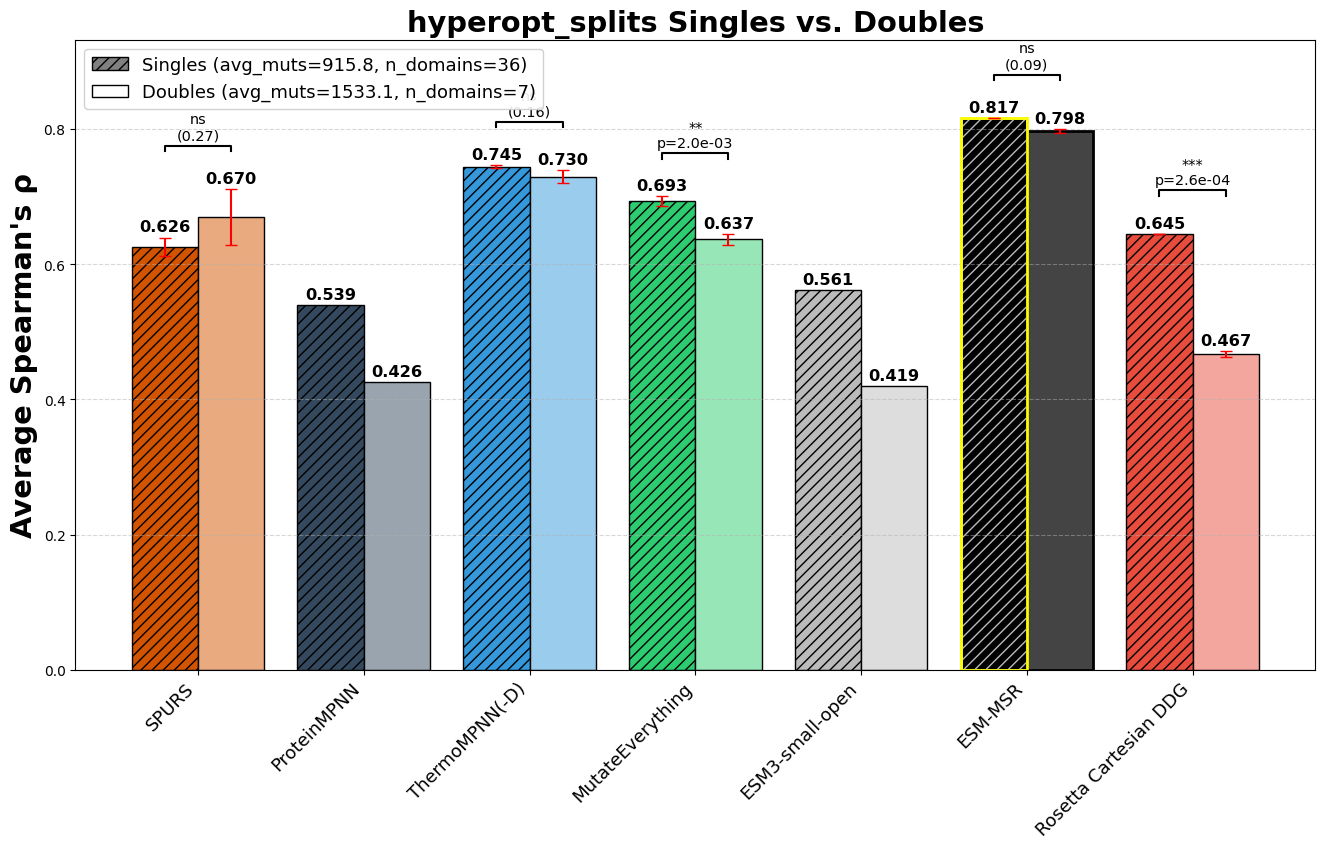

In [66]:
analysis_utils_msr.create_metric_comparison_chart_epistatic(df_scores_singles.loc[('hyperopt_splits-test', 'grouped')], ['SPURS', 'ProteinMPNN', 'ThermoMPNN(-D)', 'MutateEverything', 'ESM3-small-open', 'ESM-MSR', 'ESM3-small', 'ESM3-medium', 'ESM3-large', 'Rosetta Cartesian DDG'], highlighted_model='ESM-MSR', title='hyperopt_splits Singles vs. Doubles', y_label='Average Spearman\'s ρ',
                                             series2=df_scores_doubles.loc[('hyperopt_splits-test', 'grouped')], series_names=('Singles', 'Doubles'), fontsize_multiplier=1.3, figsize=(16,10), legend_loc='upper left')

(<Figure size 1600x1000 with 1 Axes>,
 <Axes: title={'center': 'hyperopt_splits Native vs. Destabilized'}, ylabel="Average Spearman's ρ">)

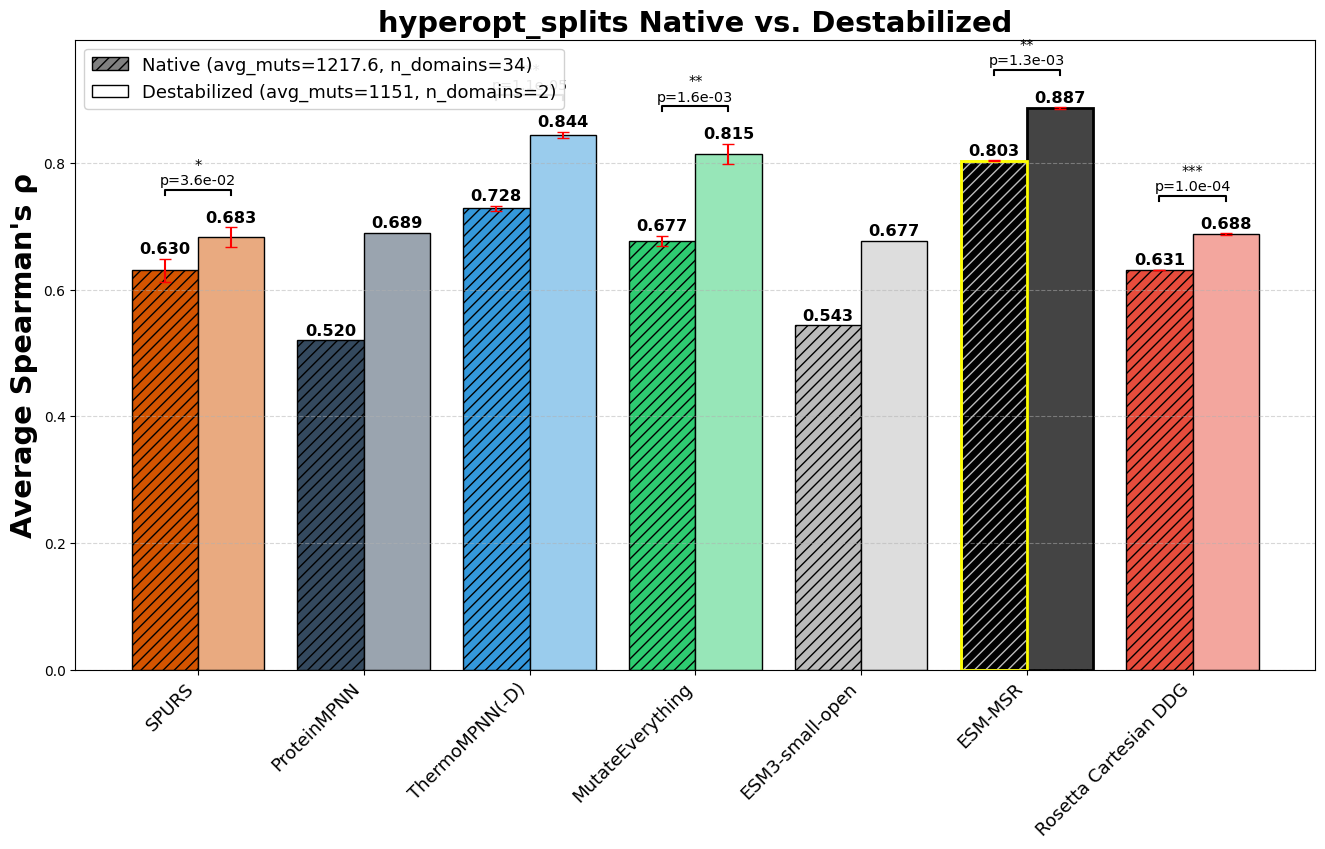

In [67]:
analysis_utils_msr.create_metric_comparison_chart_epistatic(df_scores_no_destab.loc[('hyperopt_splits-test', 'grouped')], ['SPURS', 'ProteinMPNN', 'ThermoMPNN(-D)', 'MutateEverything', 'ESM3-small-open', 'ESM-MSR', 'ESM3-small', 'ESM3-medium', 'ESM3-large', 'Rosetta Cartesian DDG'], highlighted_model='ESM-MSR', title='hyperopt_splits Native vs. Destabilized', y_label='Average Spearman\'s ρ',
                                             series2=df_scores_destab.loc[('hyperopt_splits-test', 'grouped')], series_names=('Native', 'Destabilized'), fontsize_multiplier=1.3, figsize=(16,10), legend_loc='upper left')

(<Figure size 1600x1000 with 1 Axes>,
 <Axes: title={'center': 'hyperopt_splits Natural vs. Synthetic'}, ylabel="Average Spearman's ρ">)

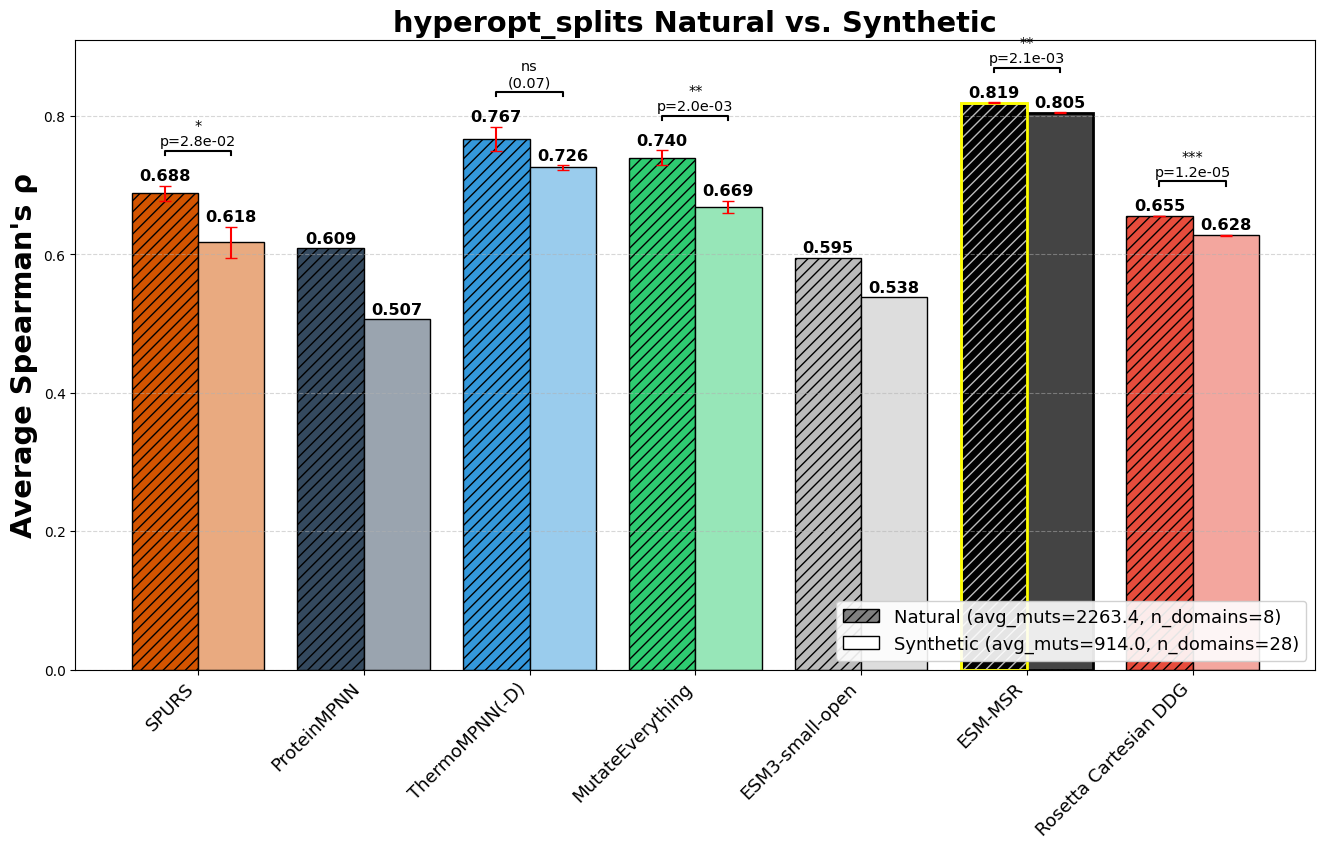

In [68]:
analysis_utils_msr.create_metric_comparison_chart_epistatic(df_scores_natural.loc[('hyperopt_splits-test', 'grouped')], ['SPURS', 'ProteinMPNN', 'ThermoMPNN(-D)', 'MutateEverything', 'ESM3-small-open', 'ESM-MSR', 'ESM3-small', 'ESM3-medium', 'ESM3-large', 'Rosetta Cartesian DDG'], highlighted_model='ESM-MSR', title='hyperopt_splits Natural vs. Synthetic', y_label='Average Spearman\'s ρ',
                                             series2=df_scores_synthetic.loc[('hyperopt_splits-test', 'grouped')], series_names=('Natural', 'Synthetic'), fontsize_multiplier=1.3, figsize=(16,10), legend_loc='lower right')